Loaded: 17,150 rows × 57 columns

England cross-section: 2,072 rows | 296 LADs | Year: 2022

SPEC: SHORT_13 (13 predictors)

── Advanced Manufacturing ──
  ✓ Advanced Manufacturi | lq_emp     | N=290 | LASSO R²=-0.068 | ENet R²=0.011 | Best=ElasticNet
  ✓ Advanced Manufacturi | lq_bus     | N=290 | LASSO R²=0.351 | ENet R²=0.350 | Best=LASSO
  ✓ Advanced Manufacturi | growth_emp | N=290 | LASSO R²=-0.048 | ENet R²=-0.044 | Best=ElasticNet
  ✓ Advanced Manufacturi | growth_bus | N=290 | LASSO R²=-0.135 | ENet R²=-0.130 | Best=ElasticNet
  ✓ Advanced Manufacturi | cagr_emp   | N=290 | LASSO R²=-0.029 | ENet R²=-0.028 | Best=ElasticNet
  ✓ Advanced Manufacturi | cagr_bus   | N=290 | LASSO R²=-0.053 | ENet R²=-0.053 | Best=LASSO

── Creative Industries ──
  ✓ Creative Industries | lq_emp     | N=290 | LASSO R²=0.269 | ENet R²=0.282 | Best=ElasticNet
  ✓ Creative Industries | lq_bus     | N=290 | LASSO R²=0.598 | ENet R²=0.611 | Best=ElasticNet
  ✓ Creative Industries | growth_emp | N=290 |

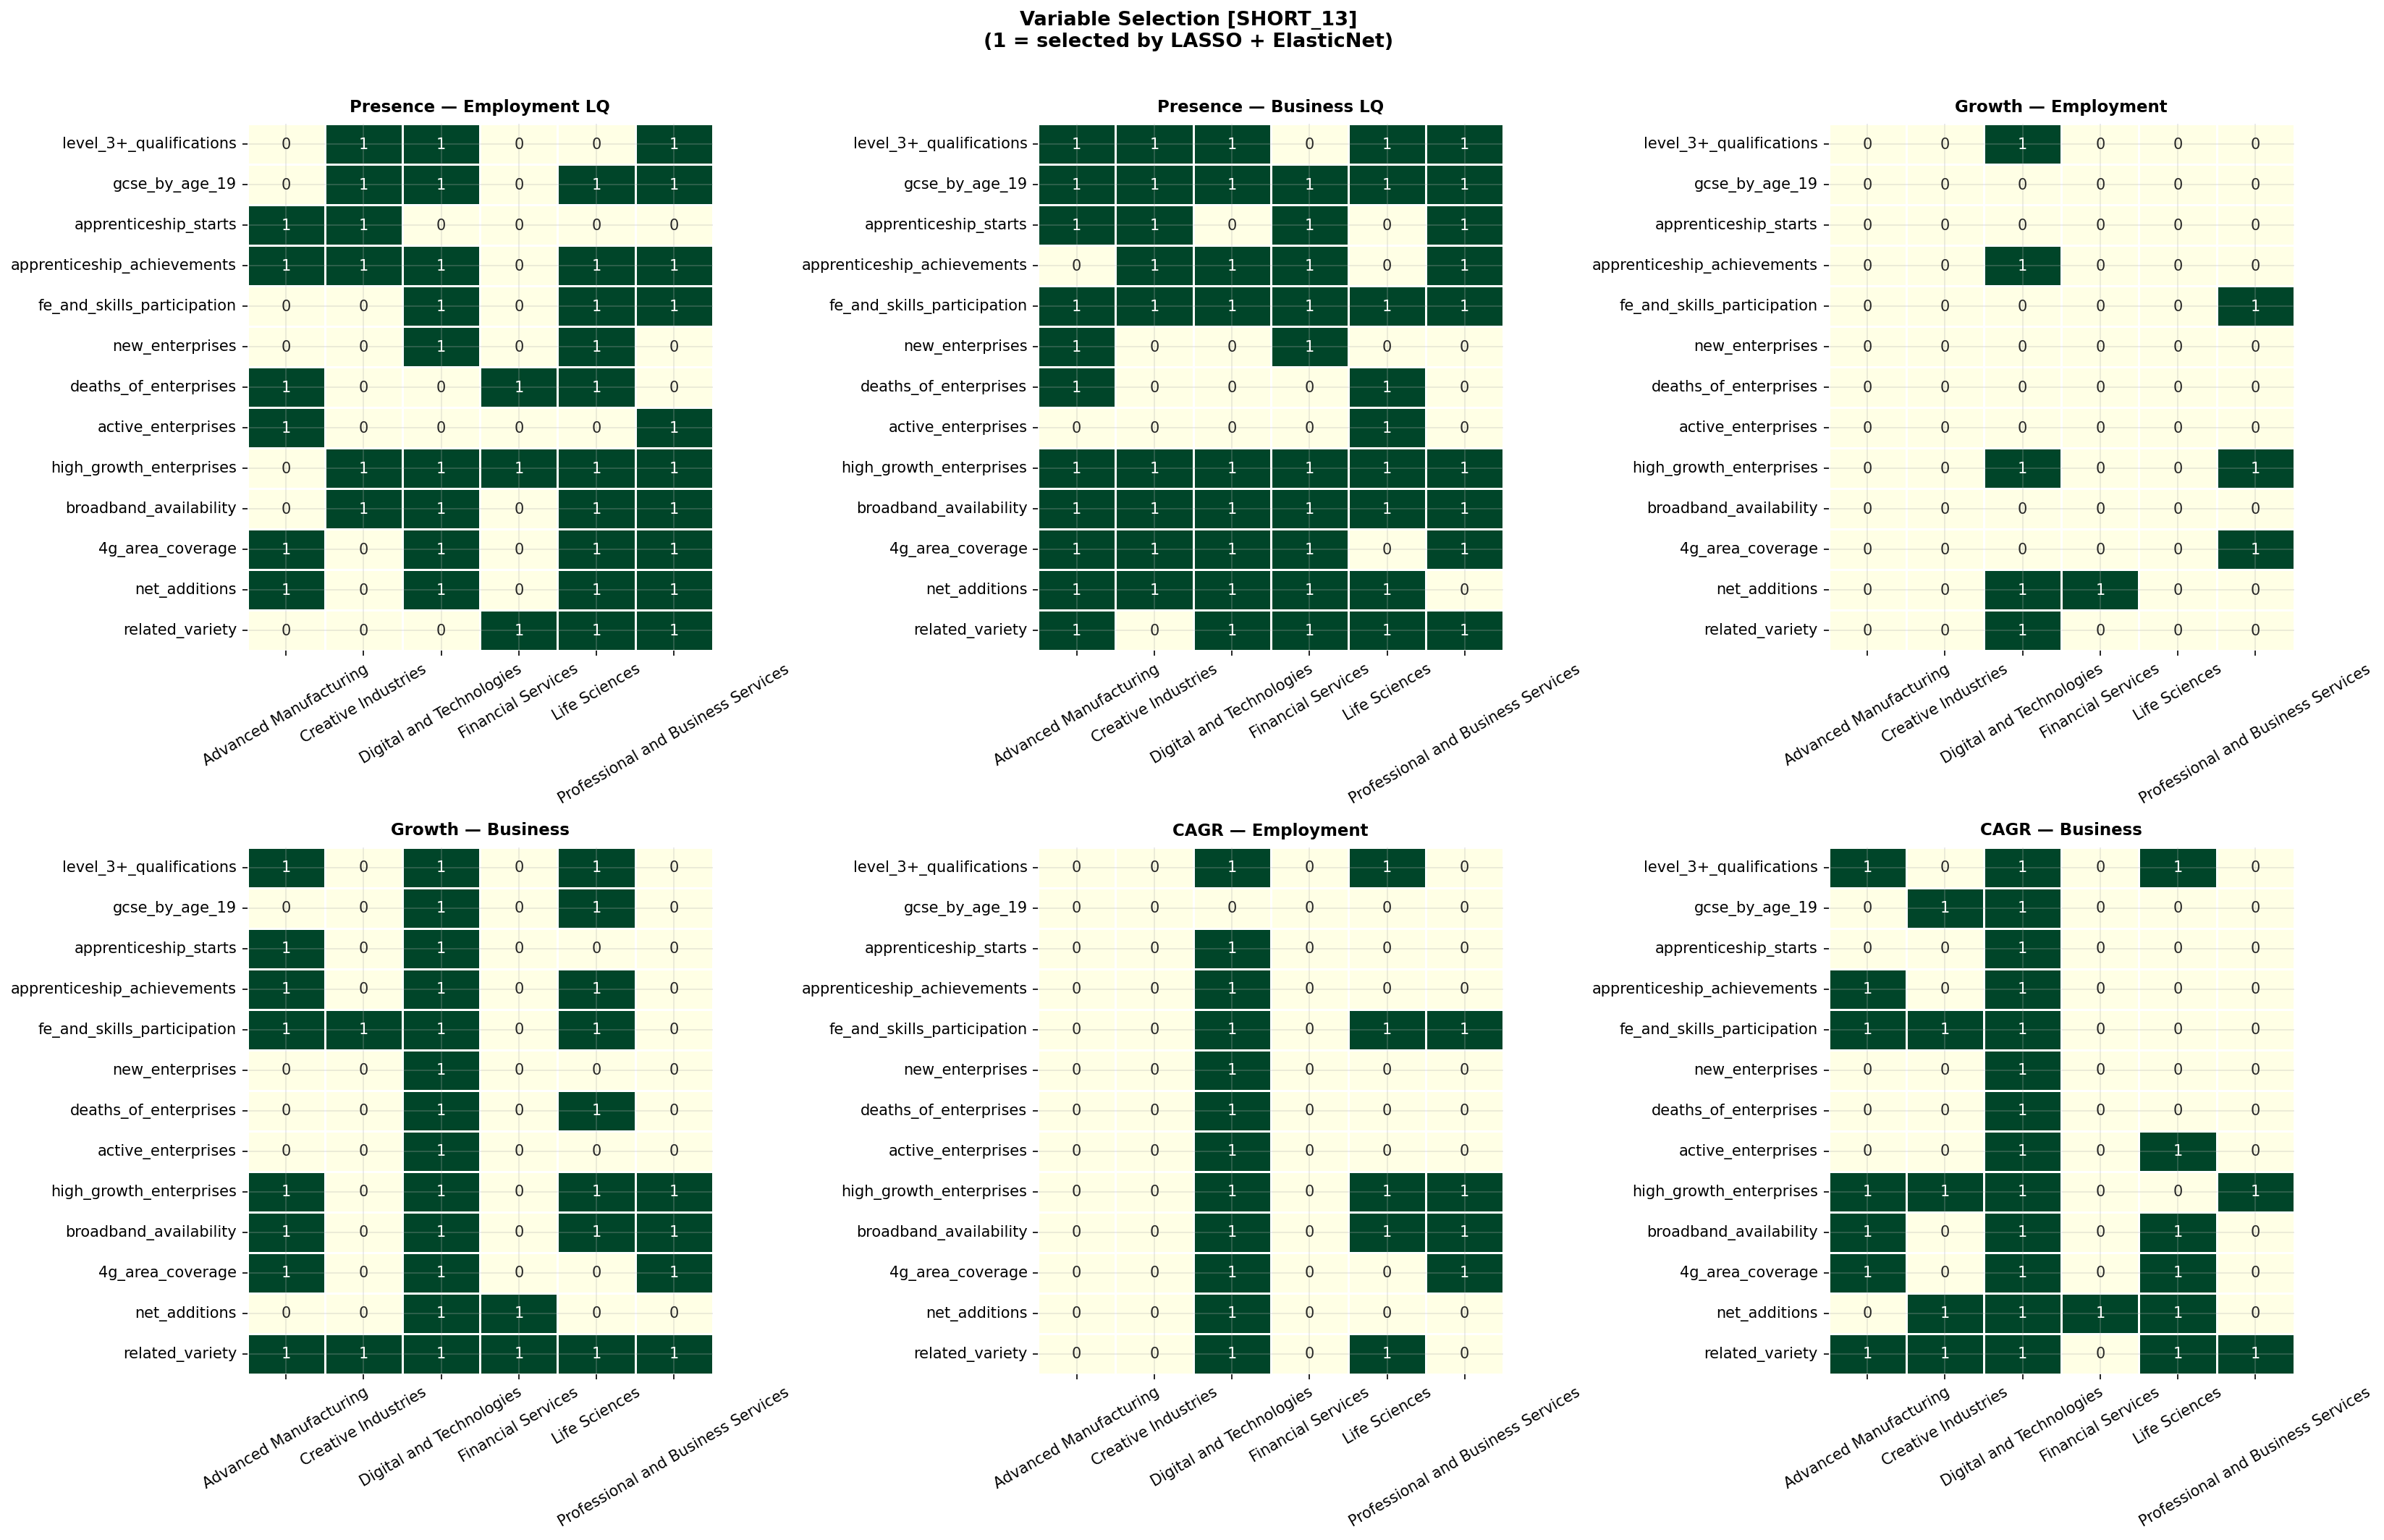

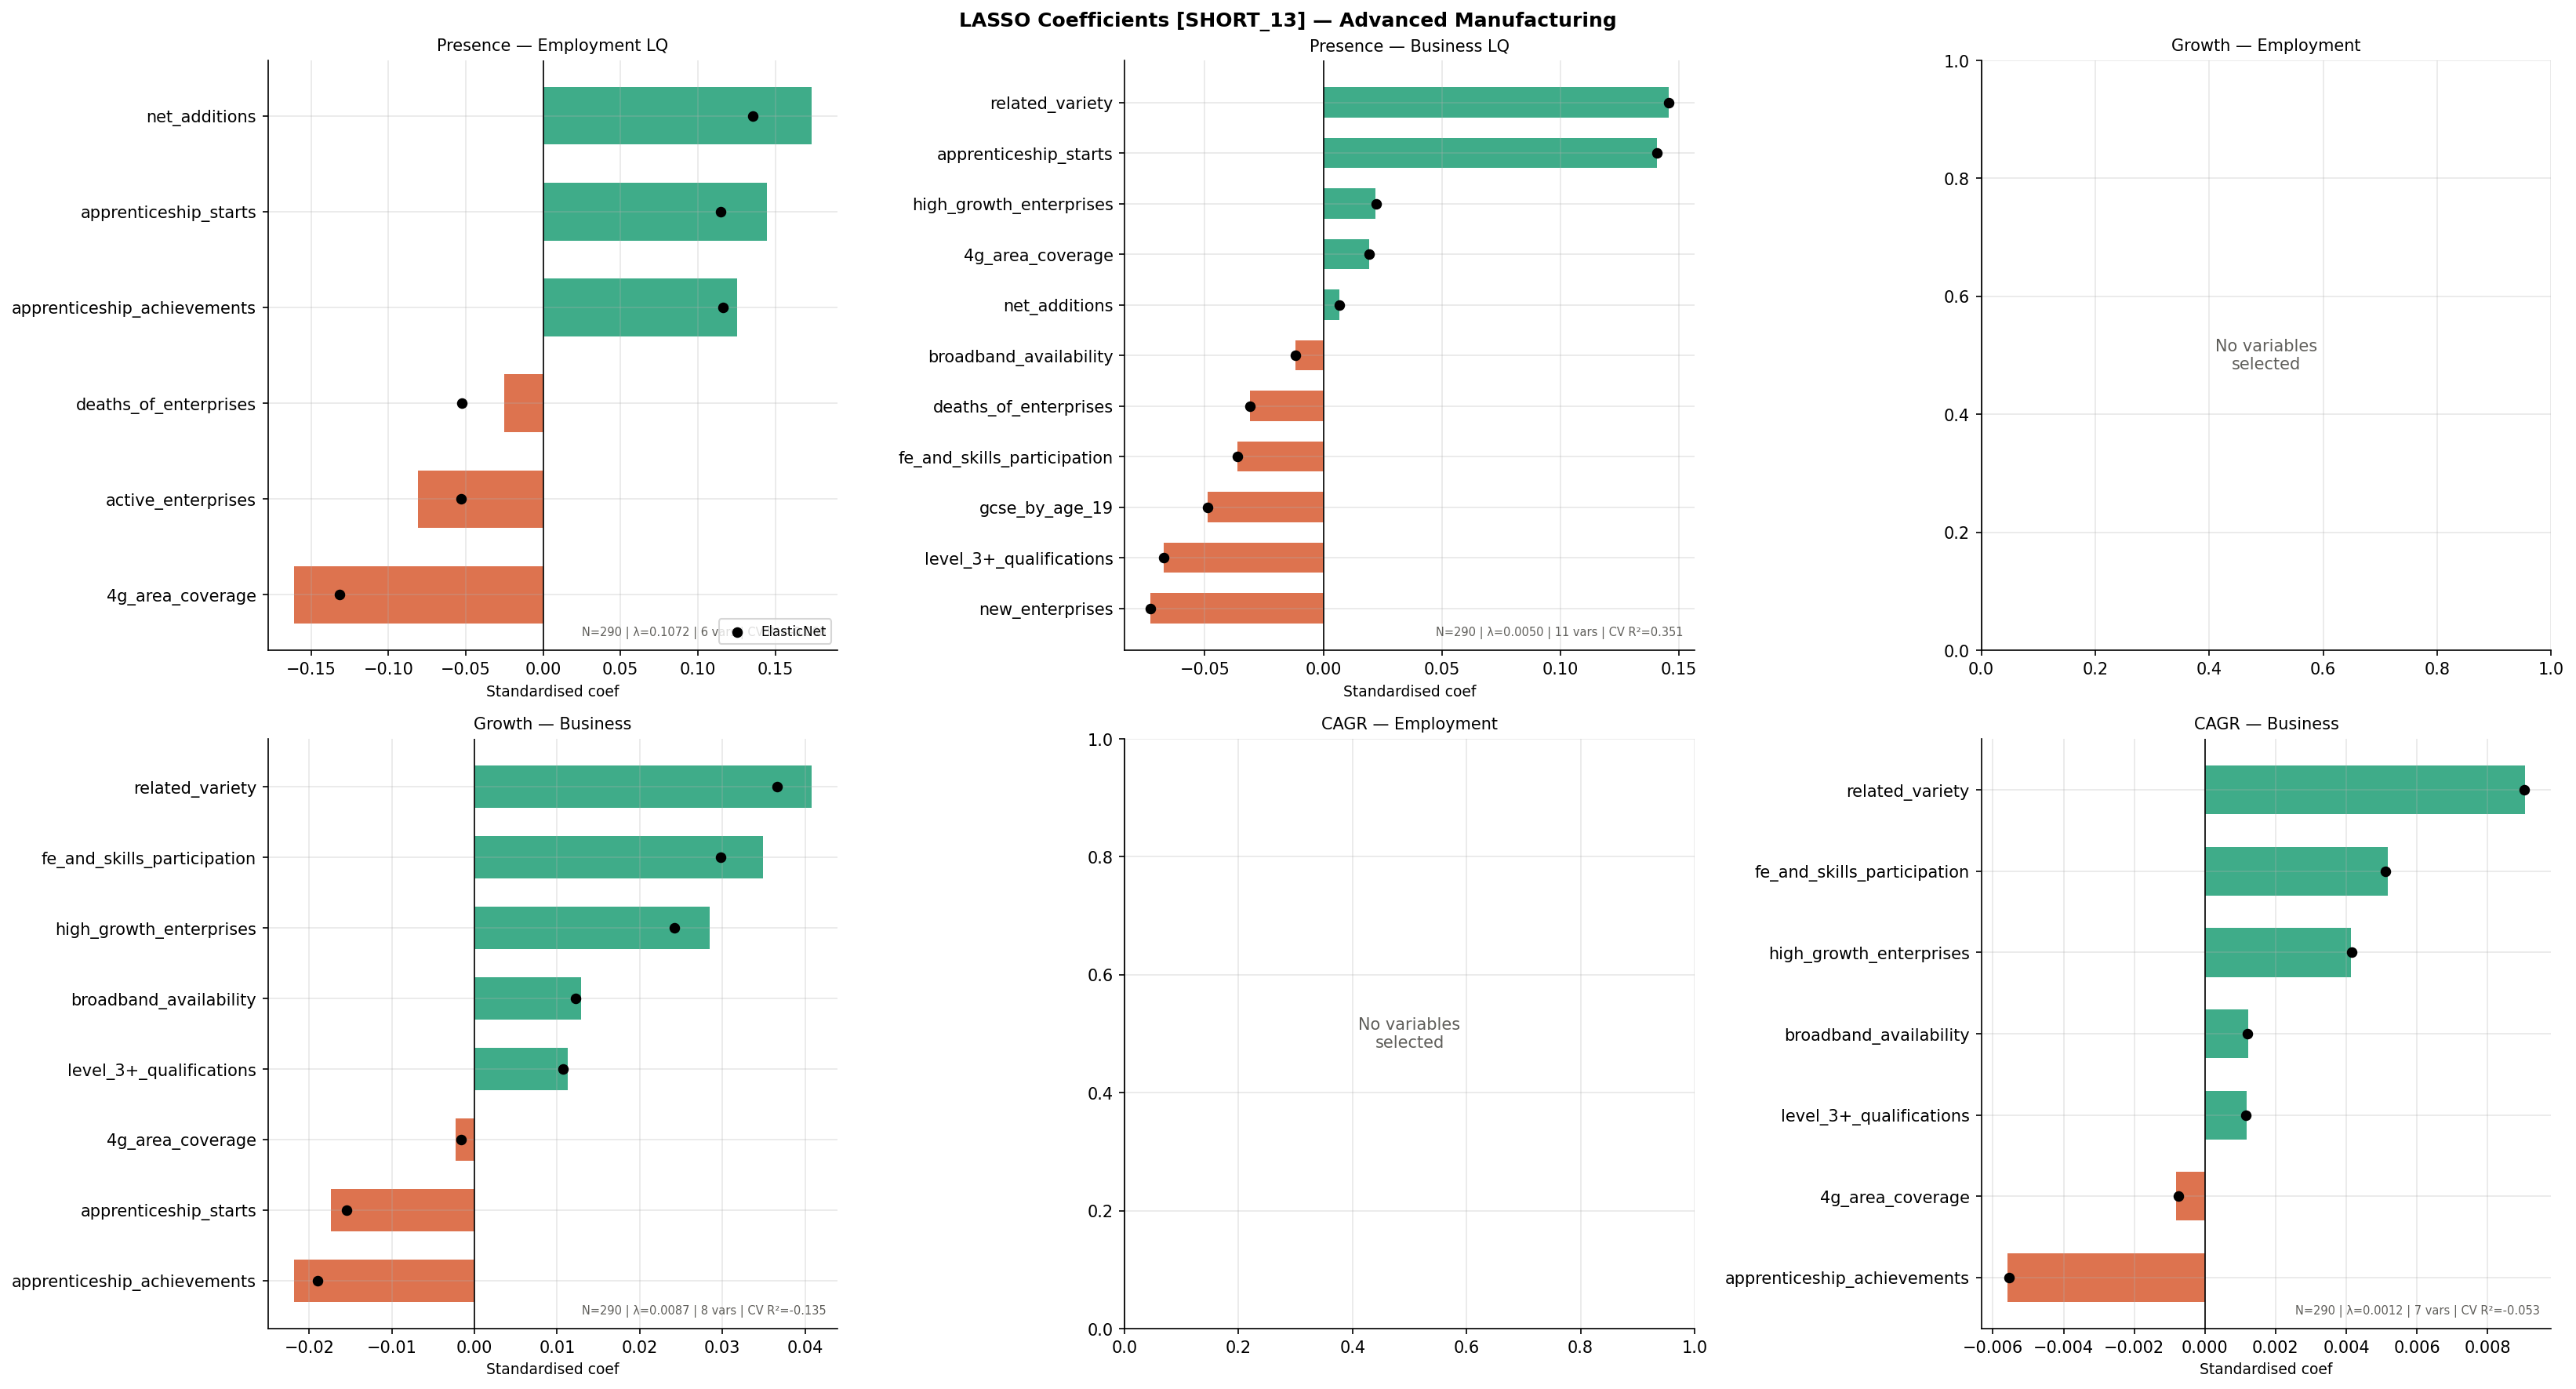

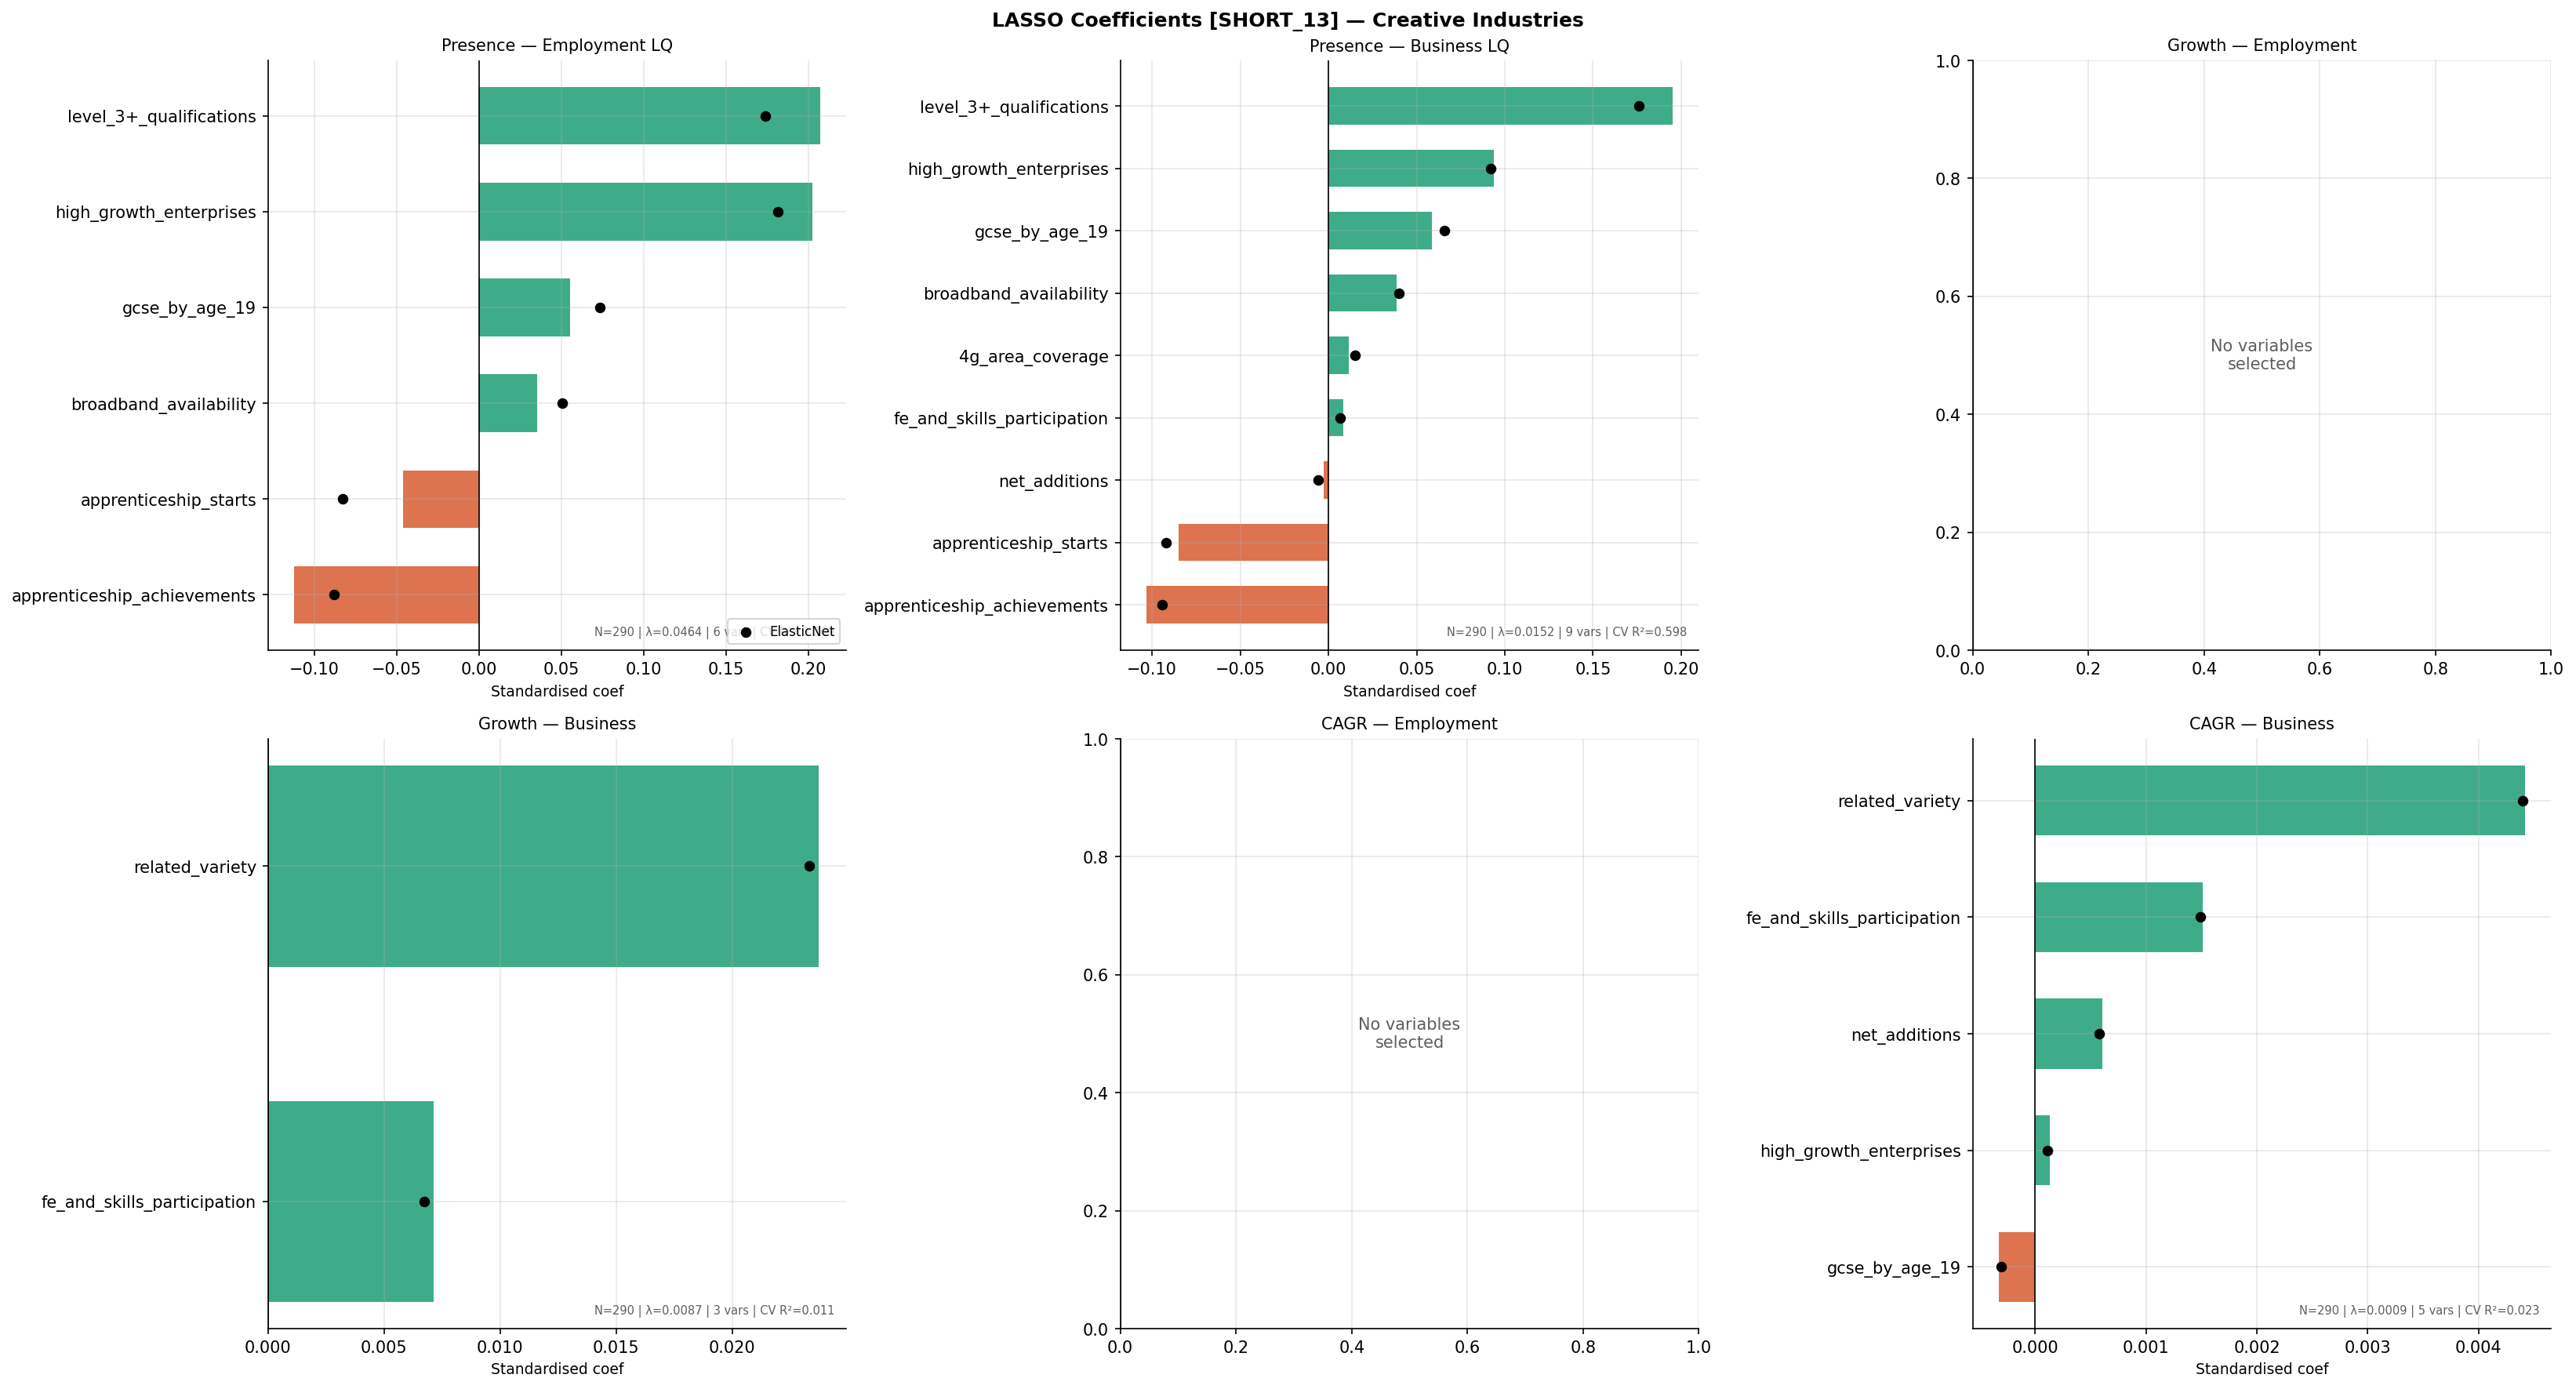

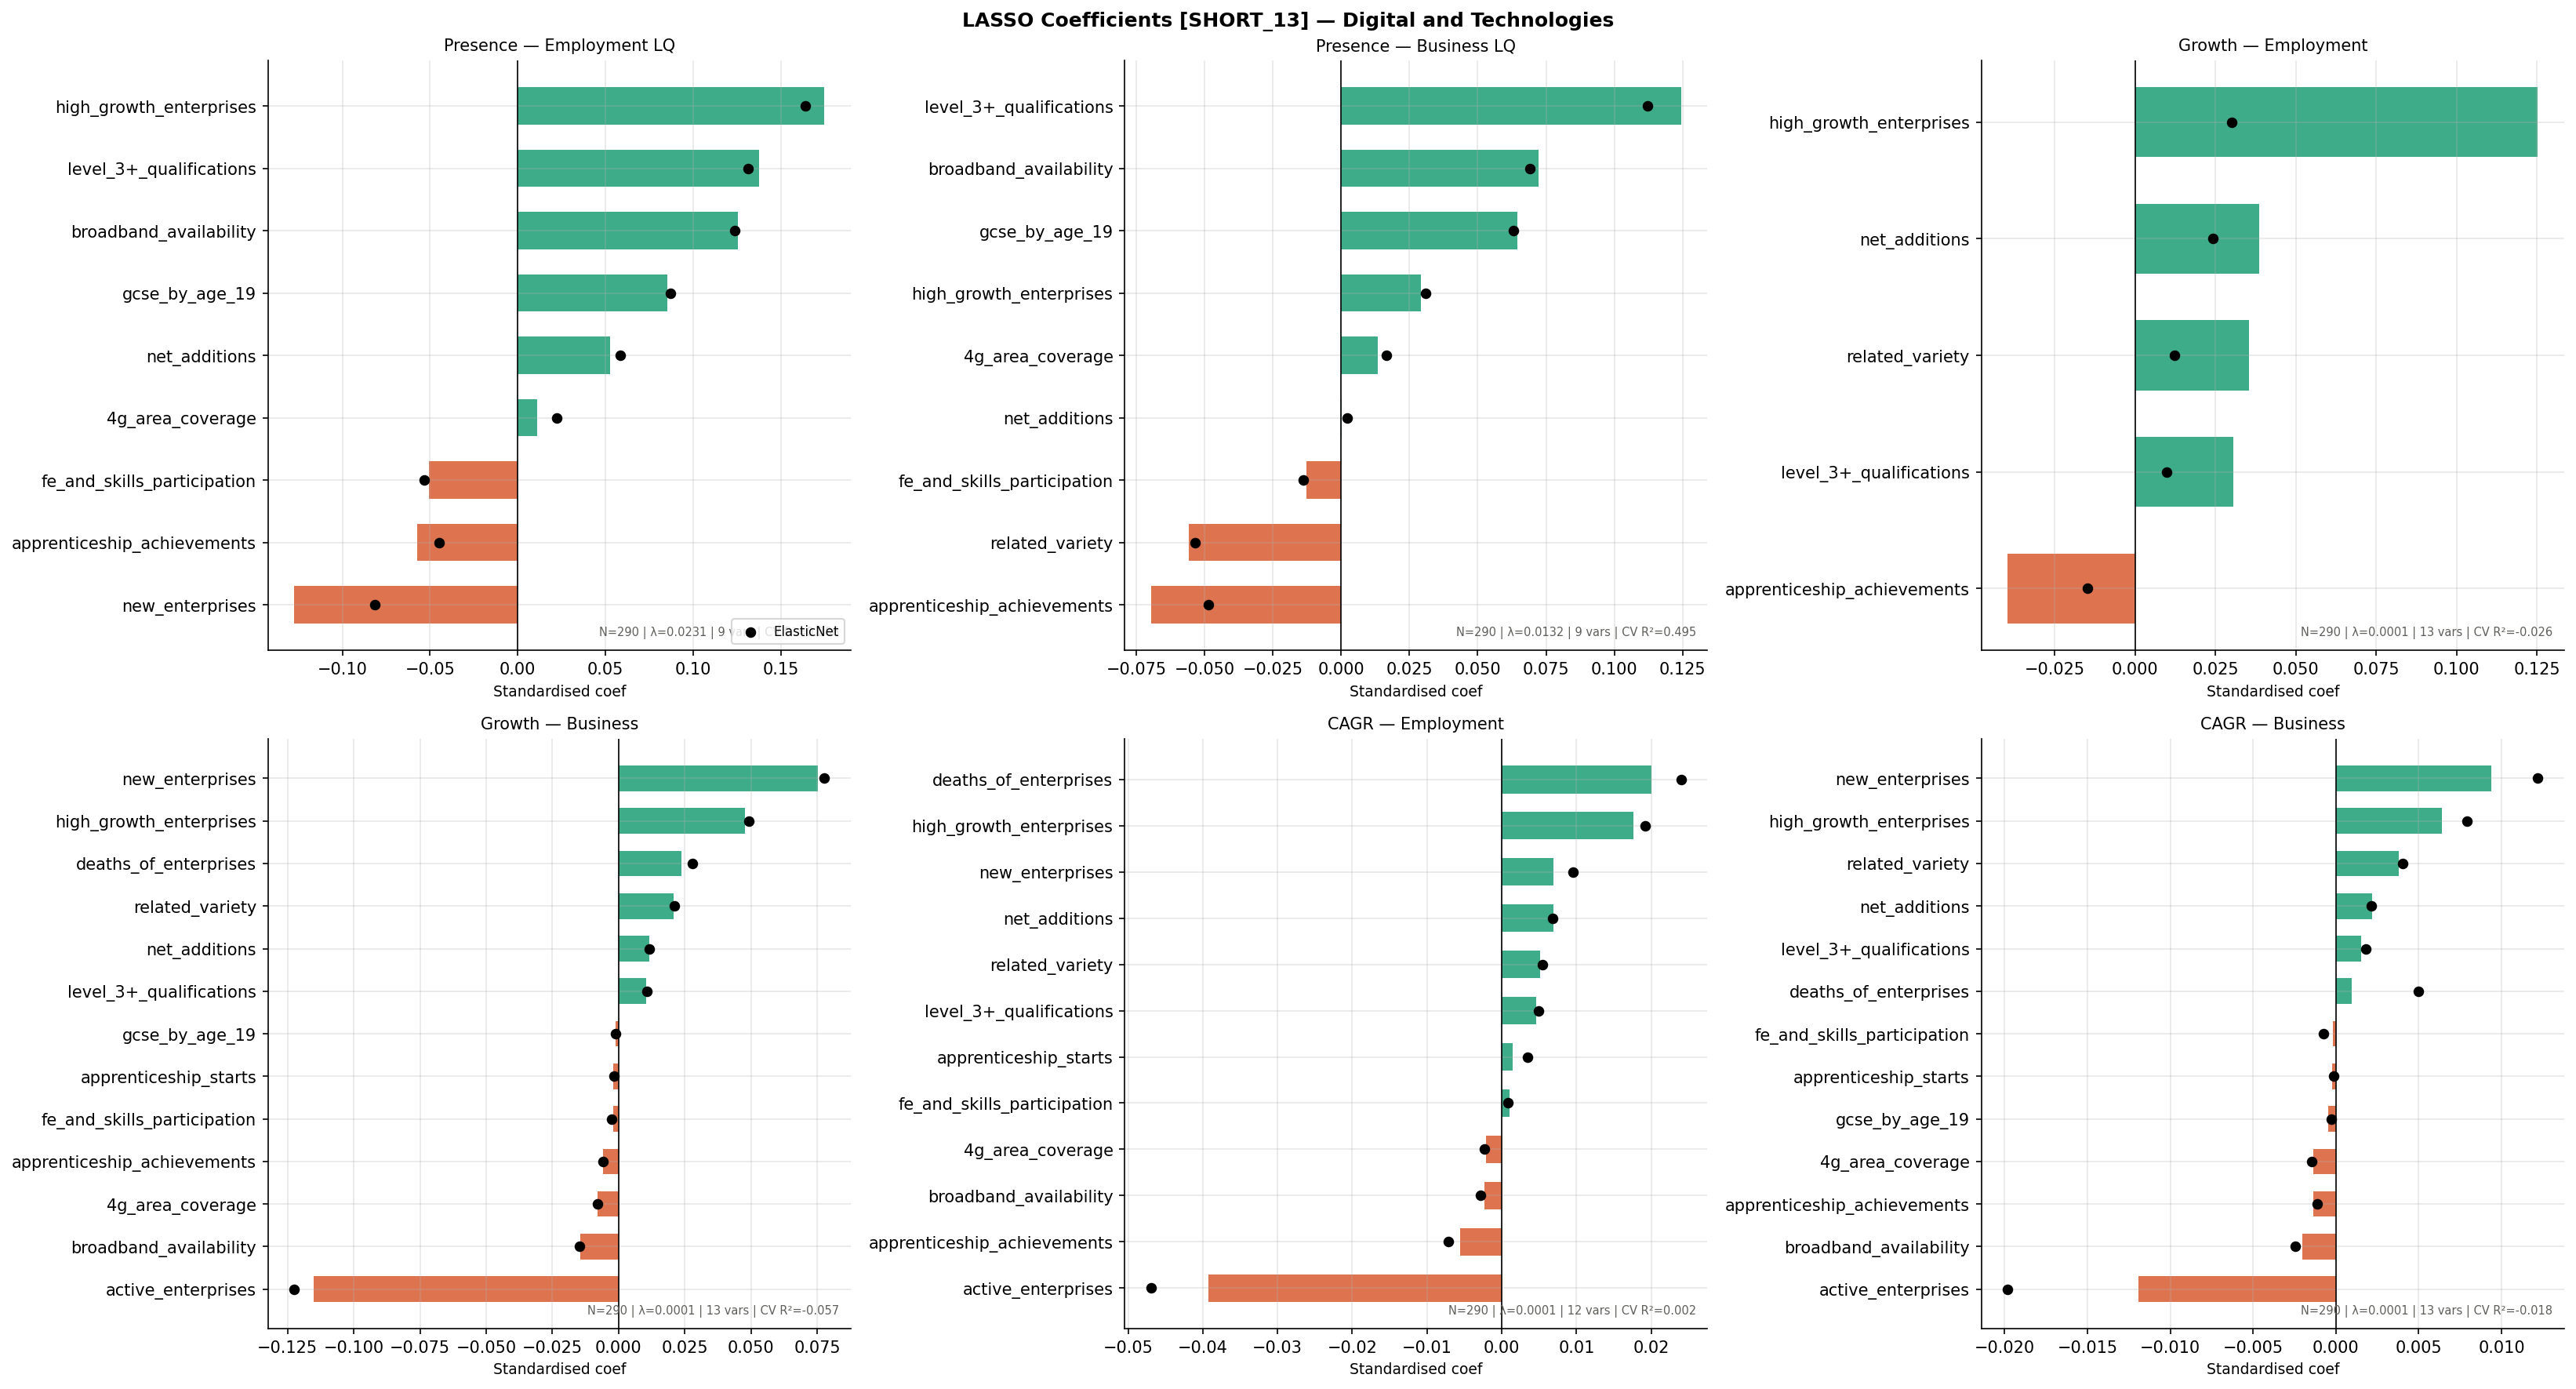

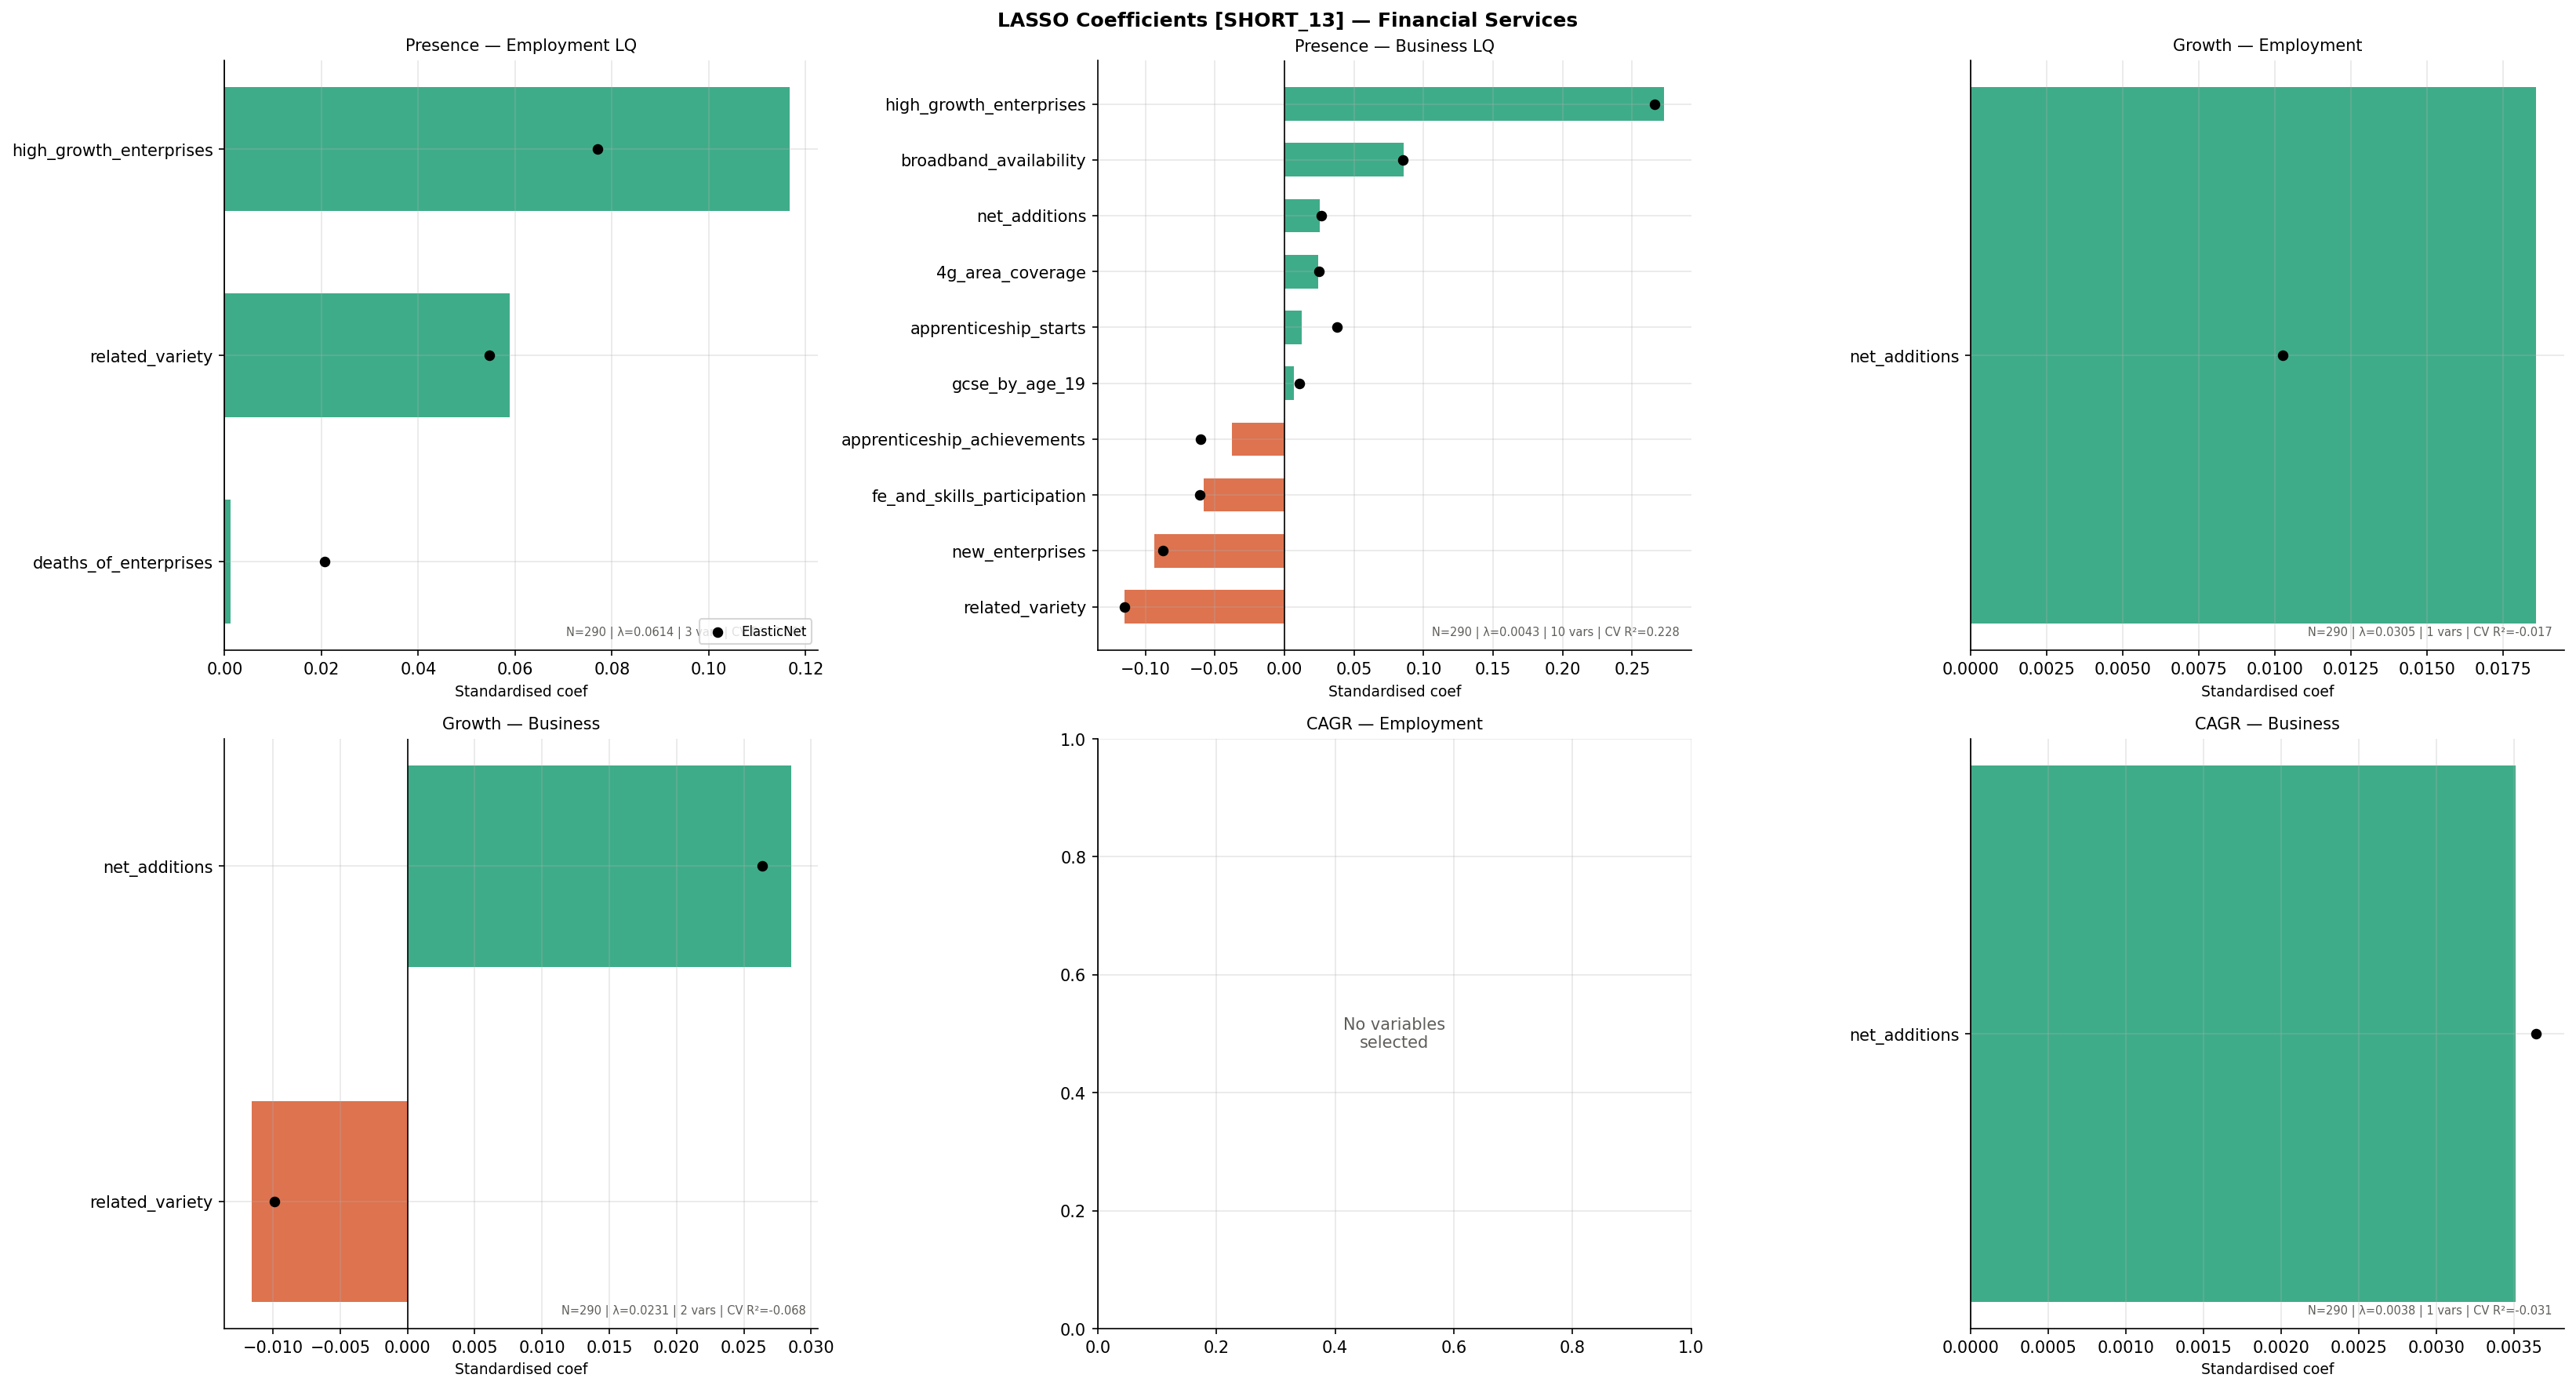

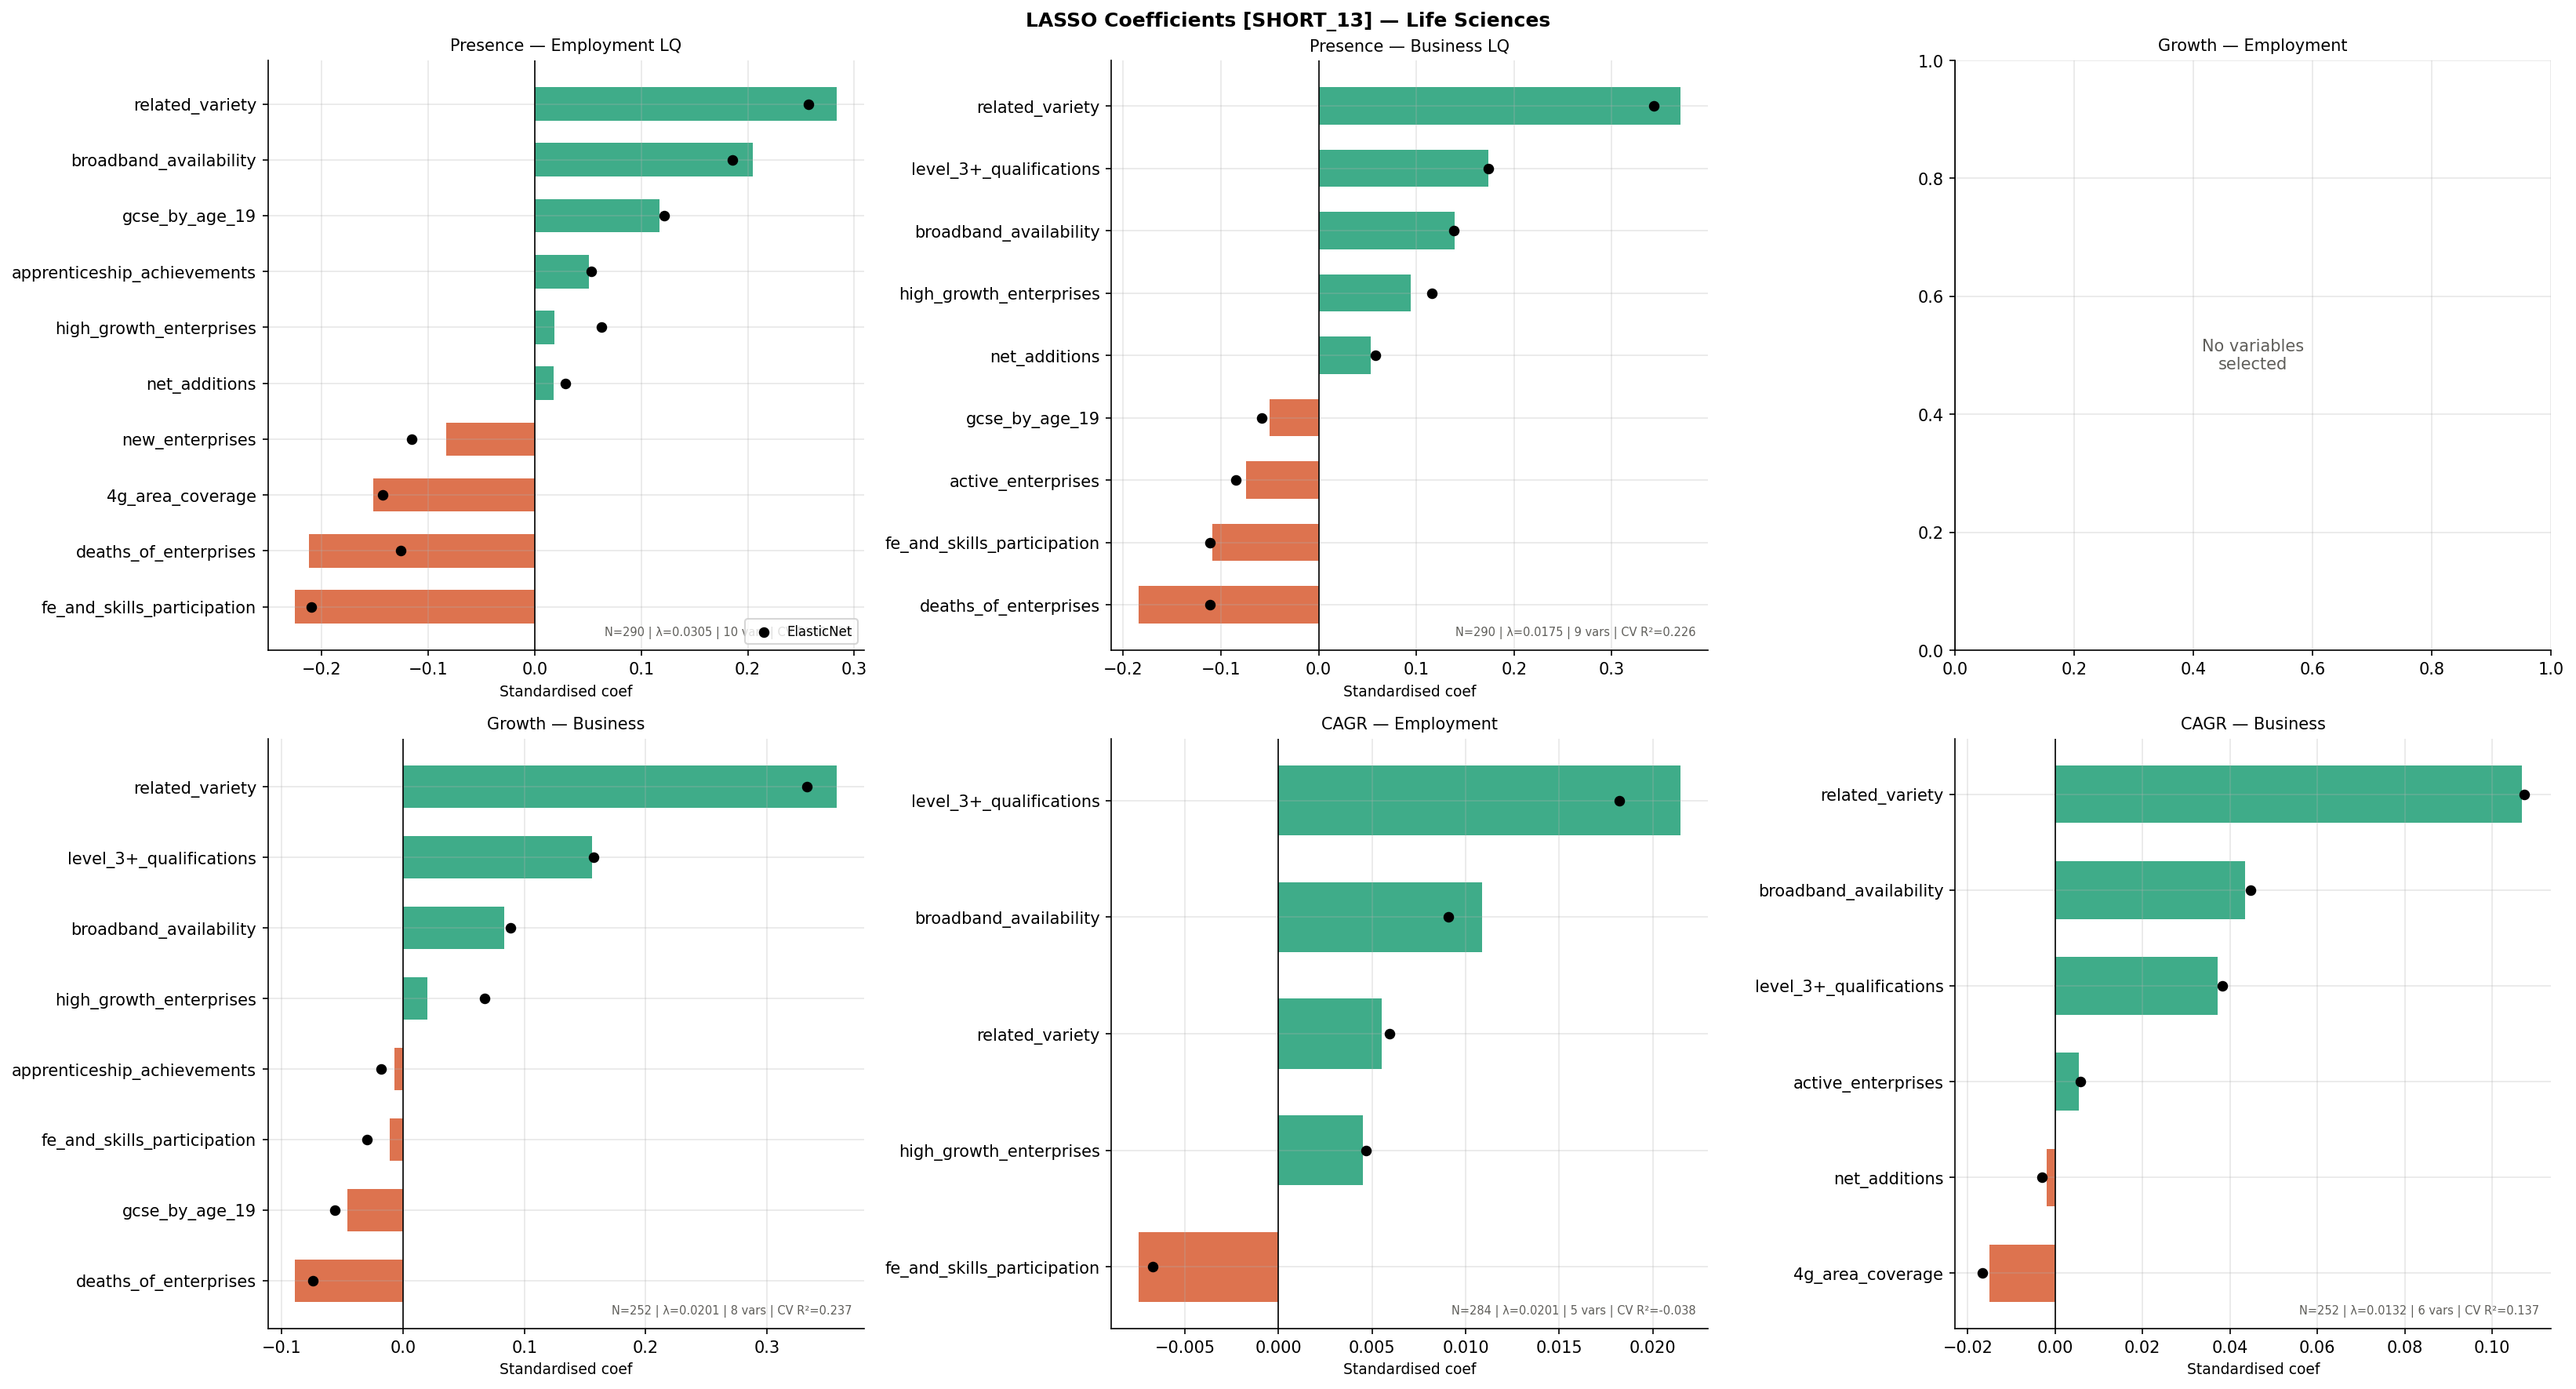

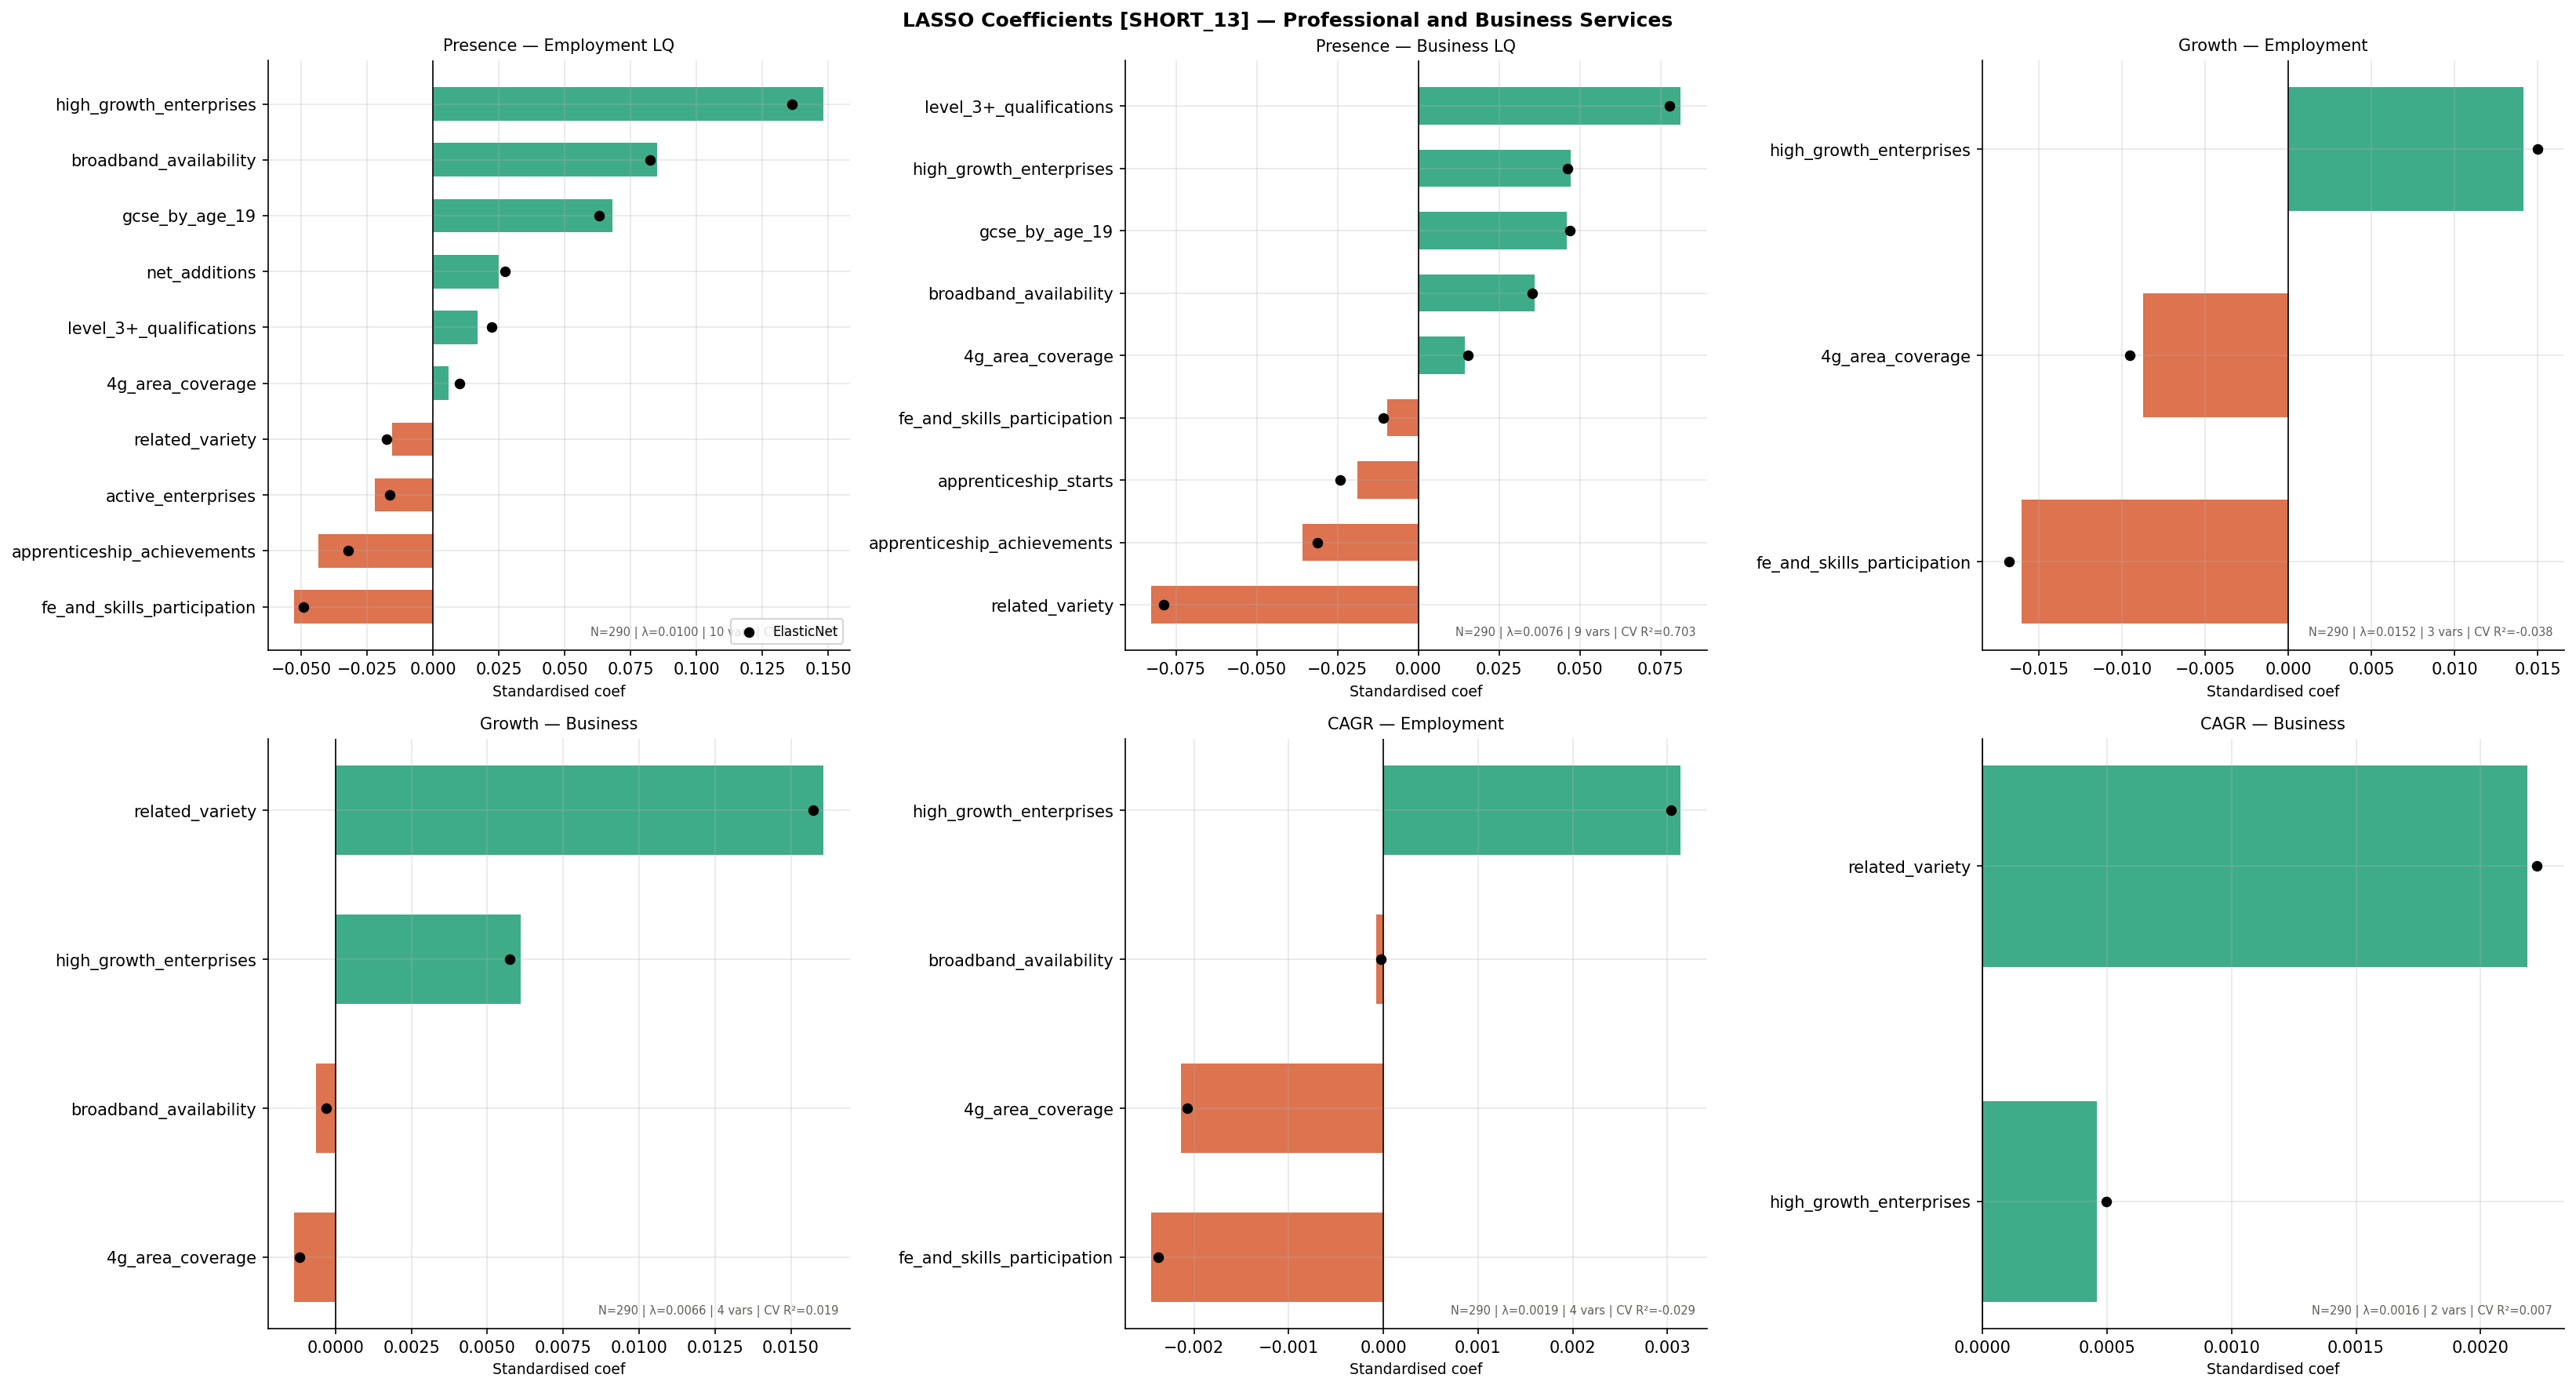

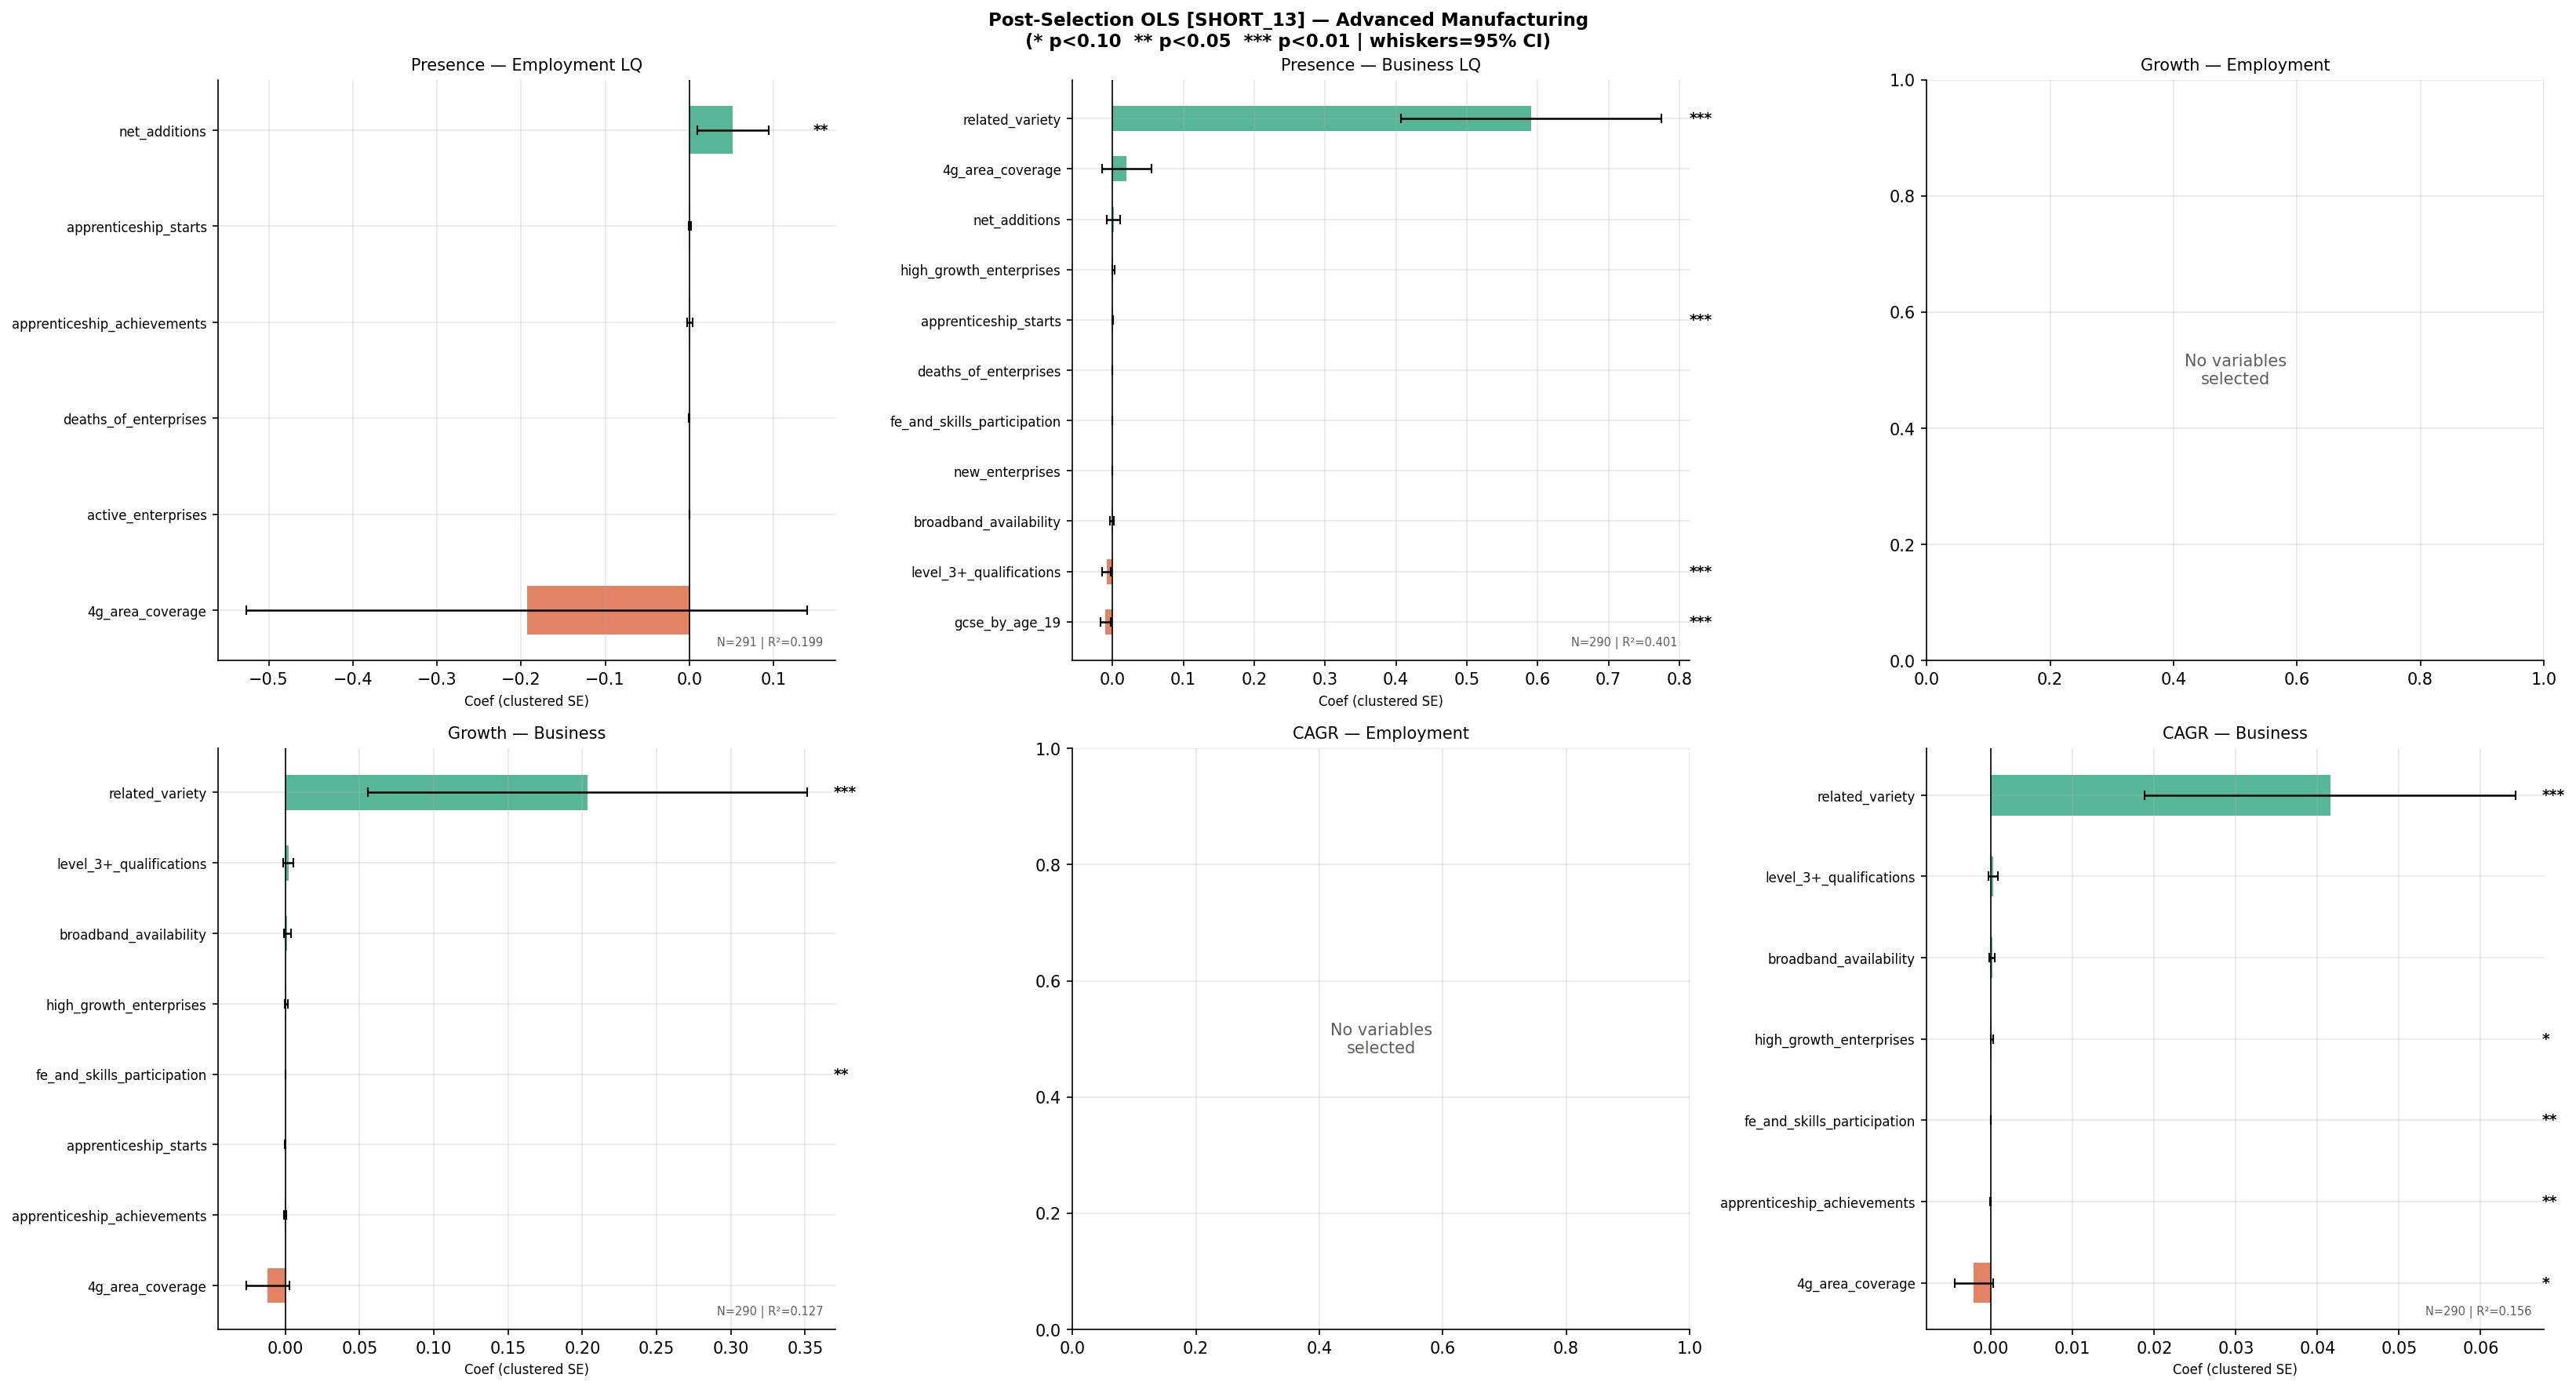

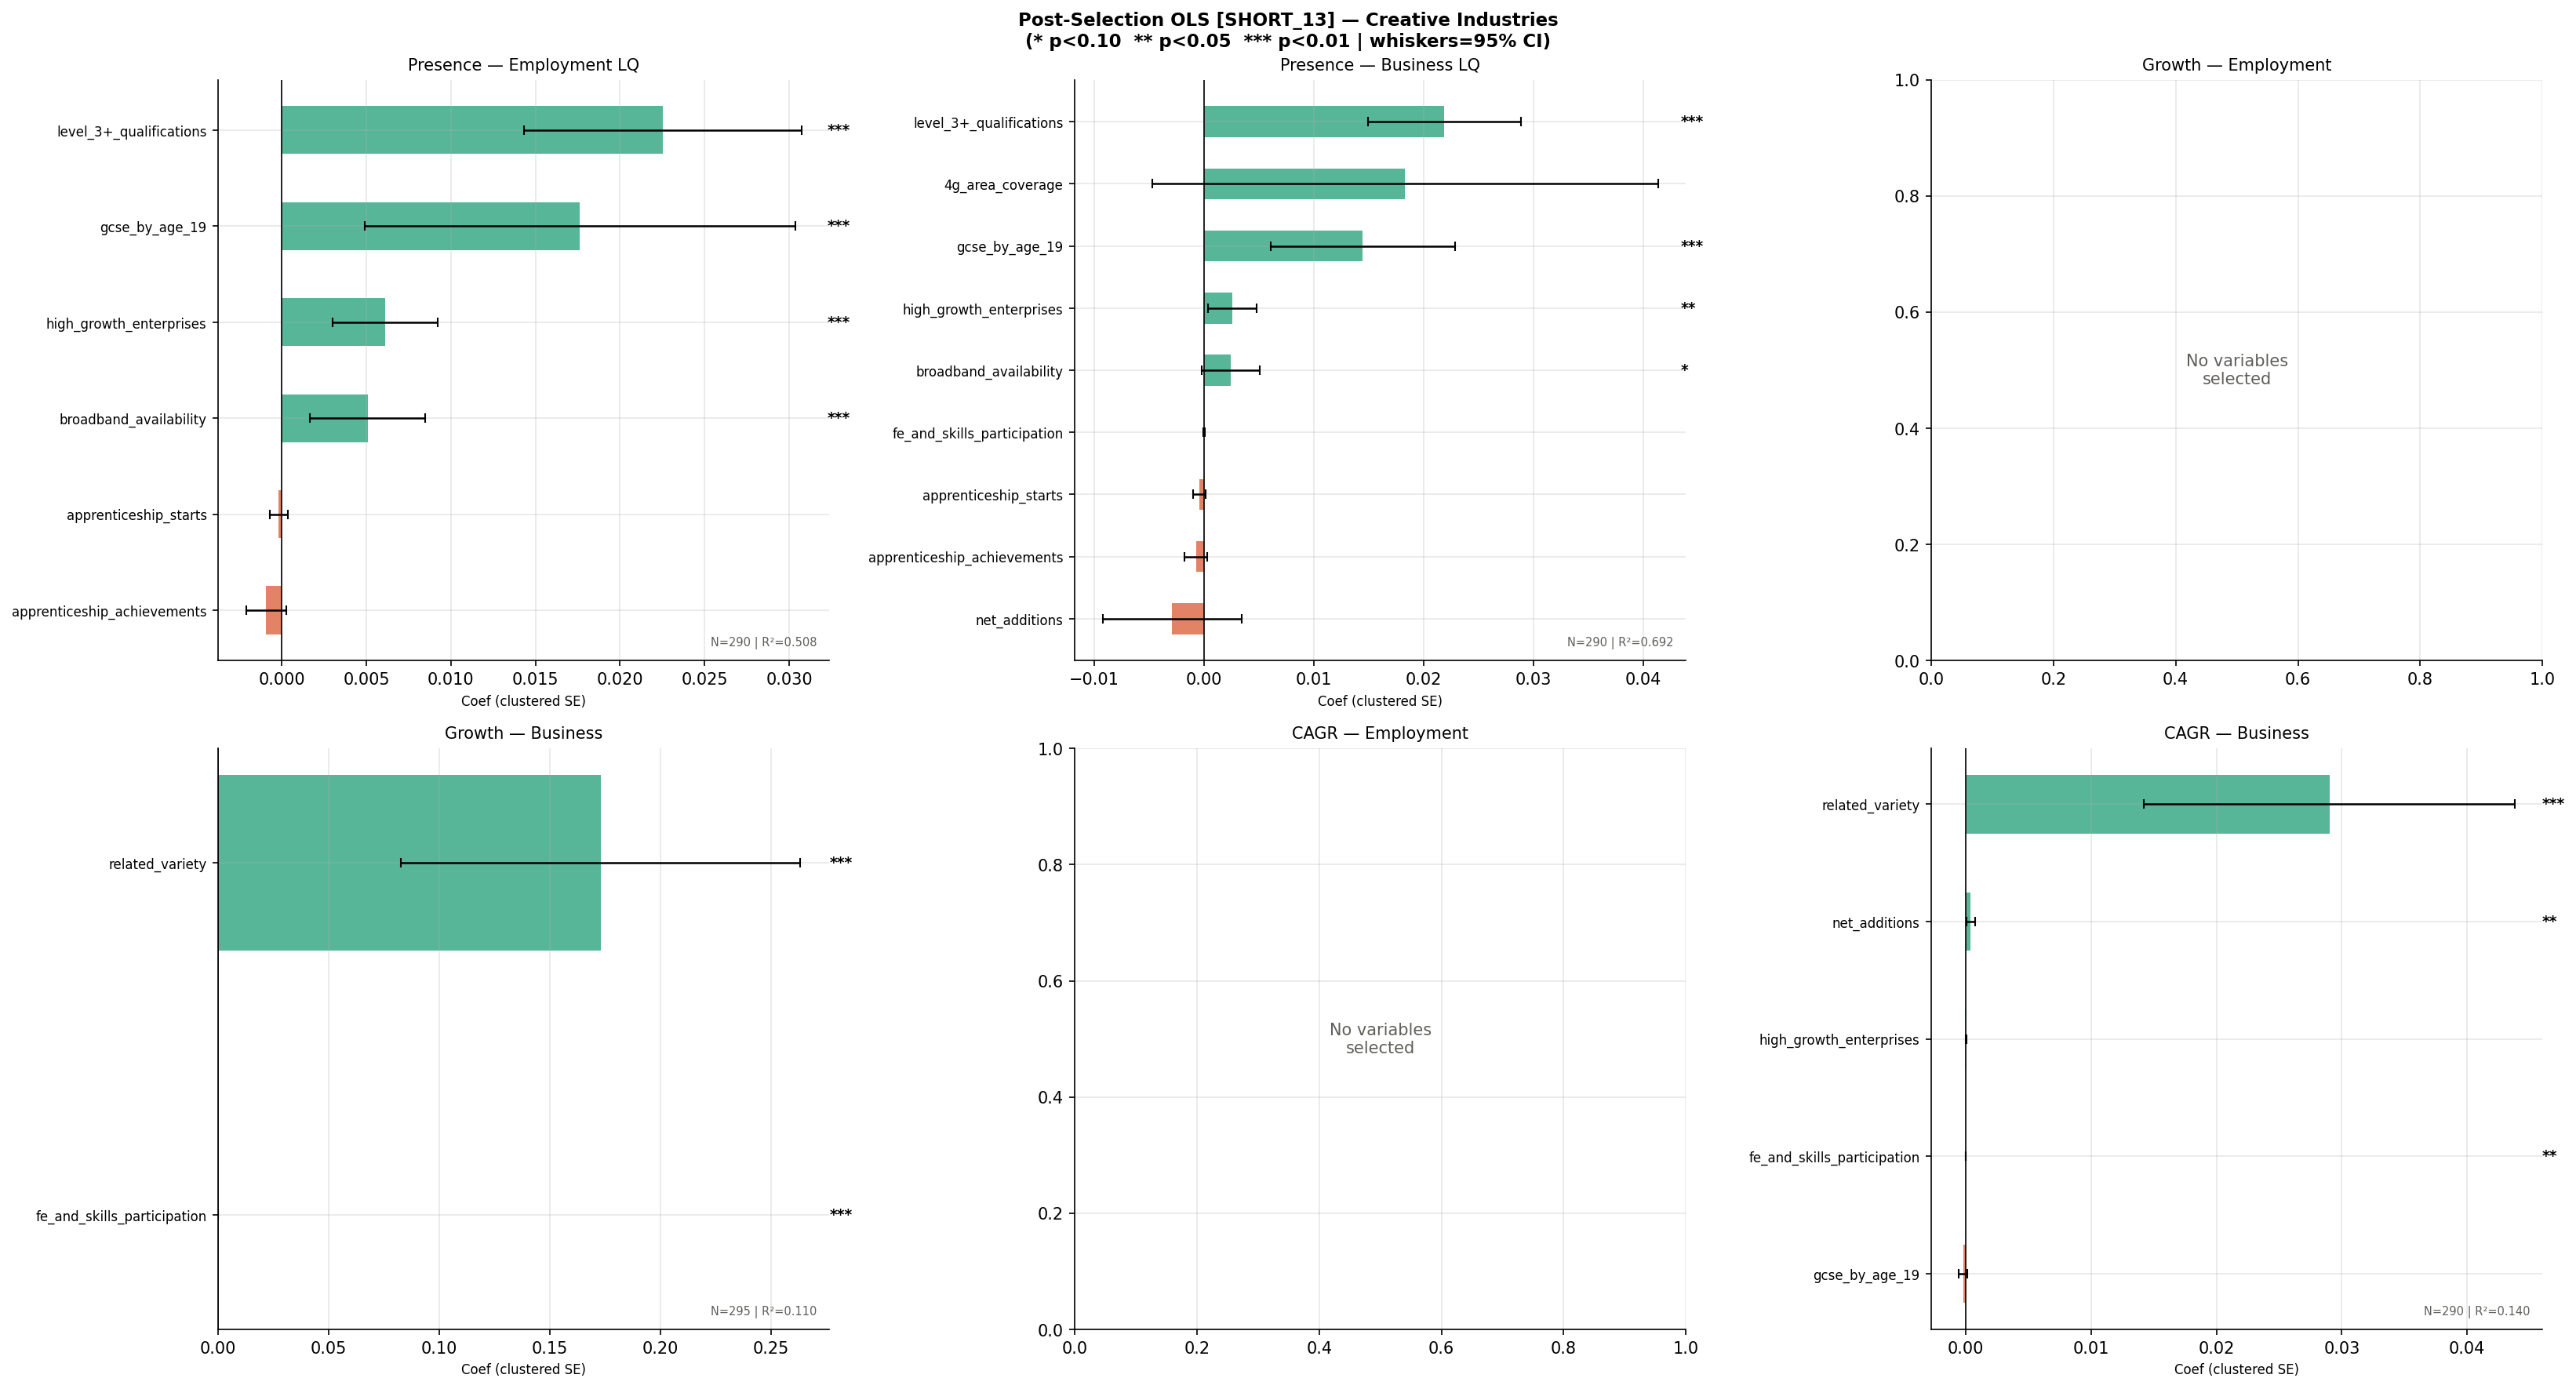

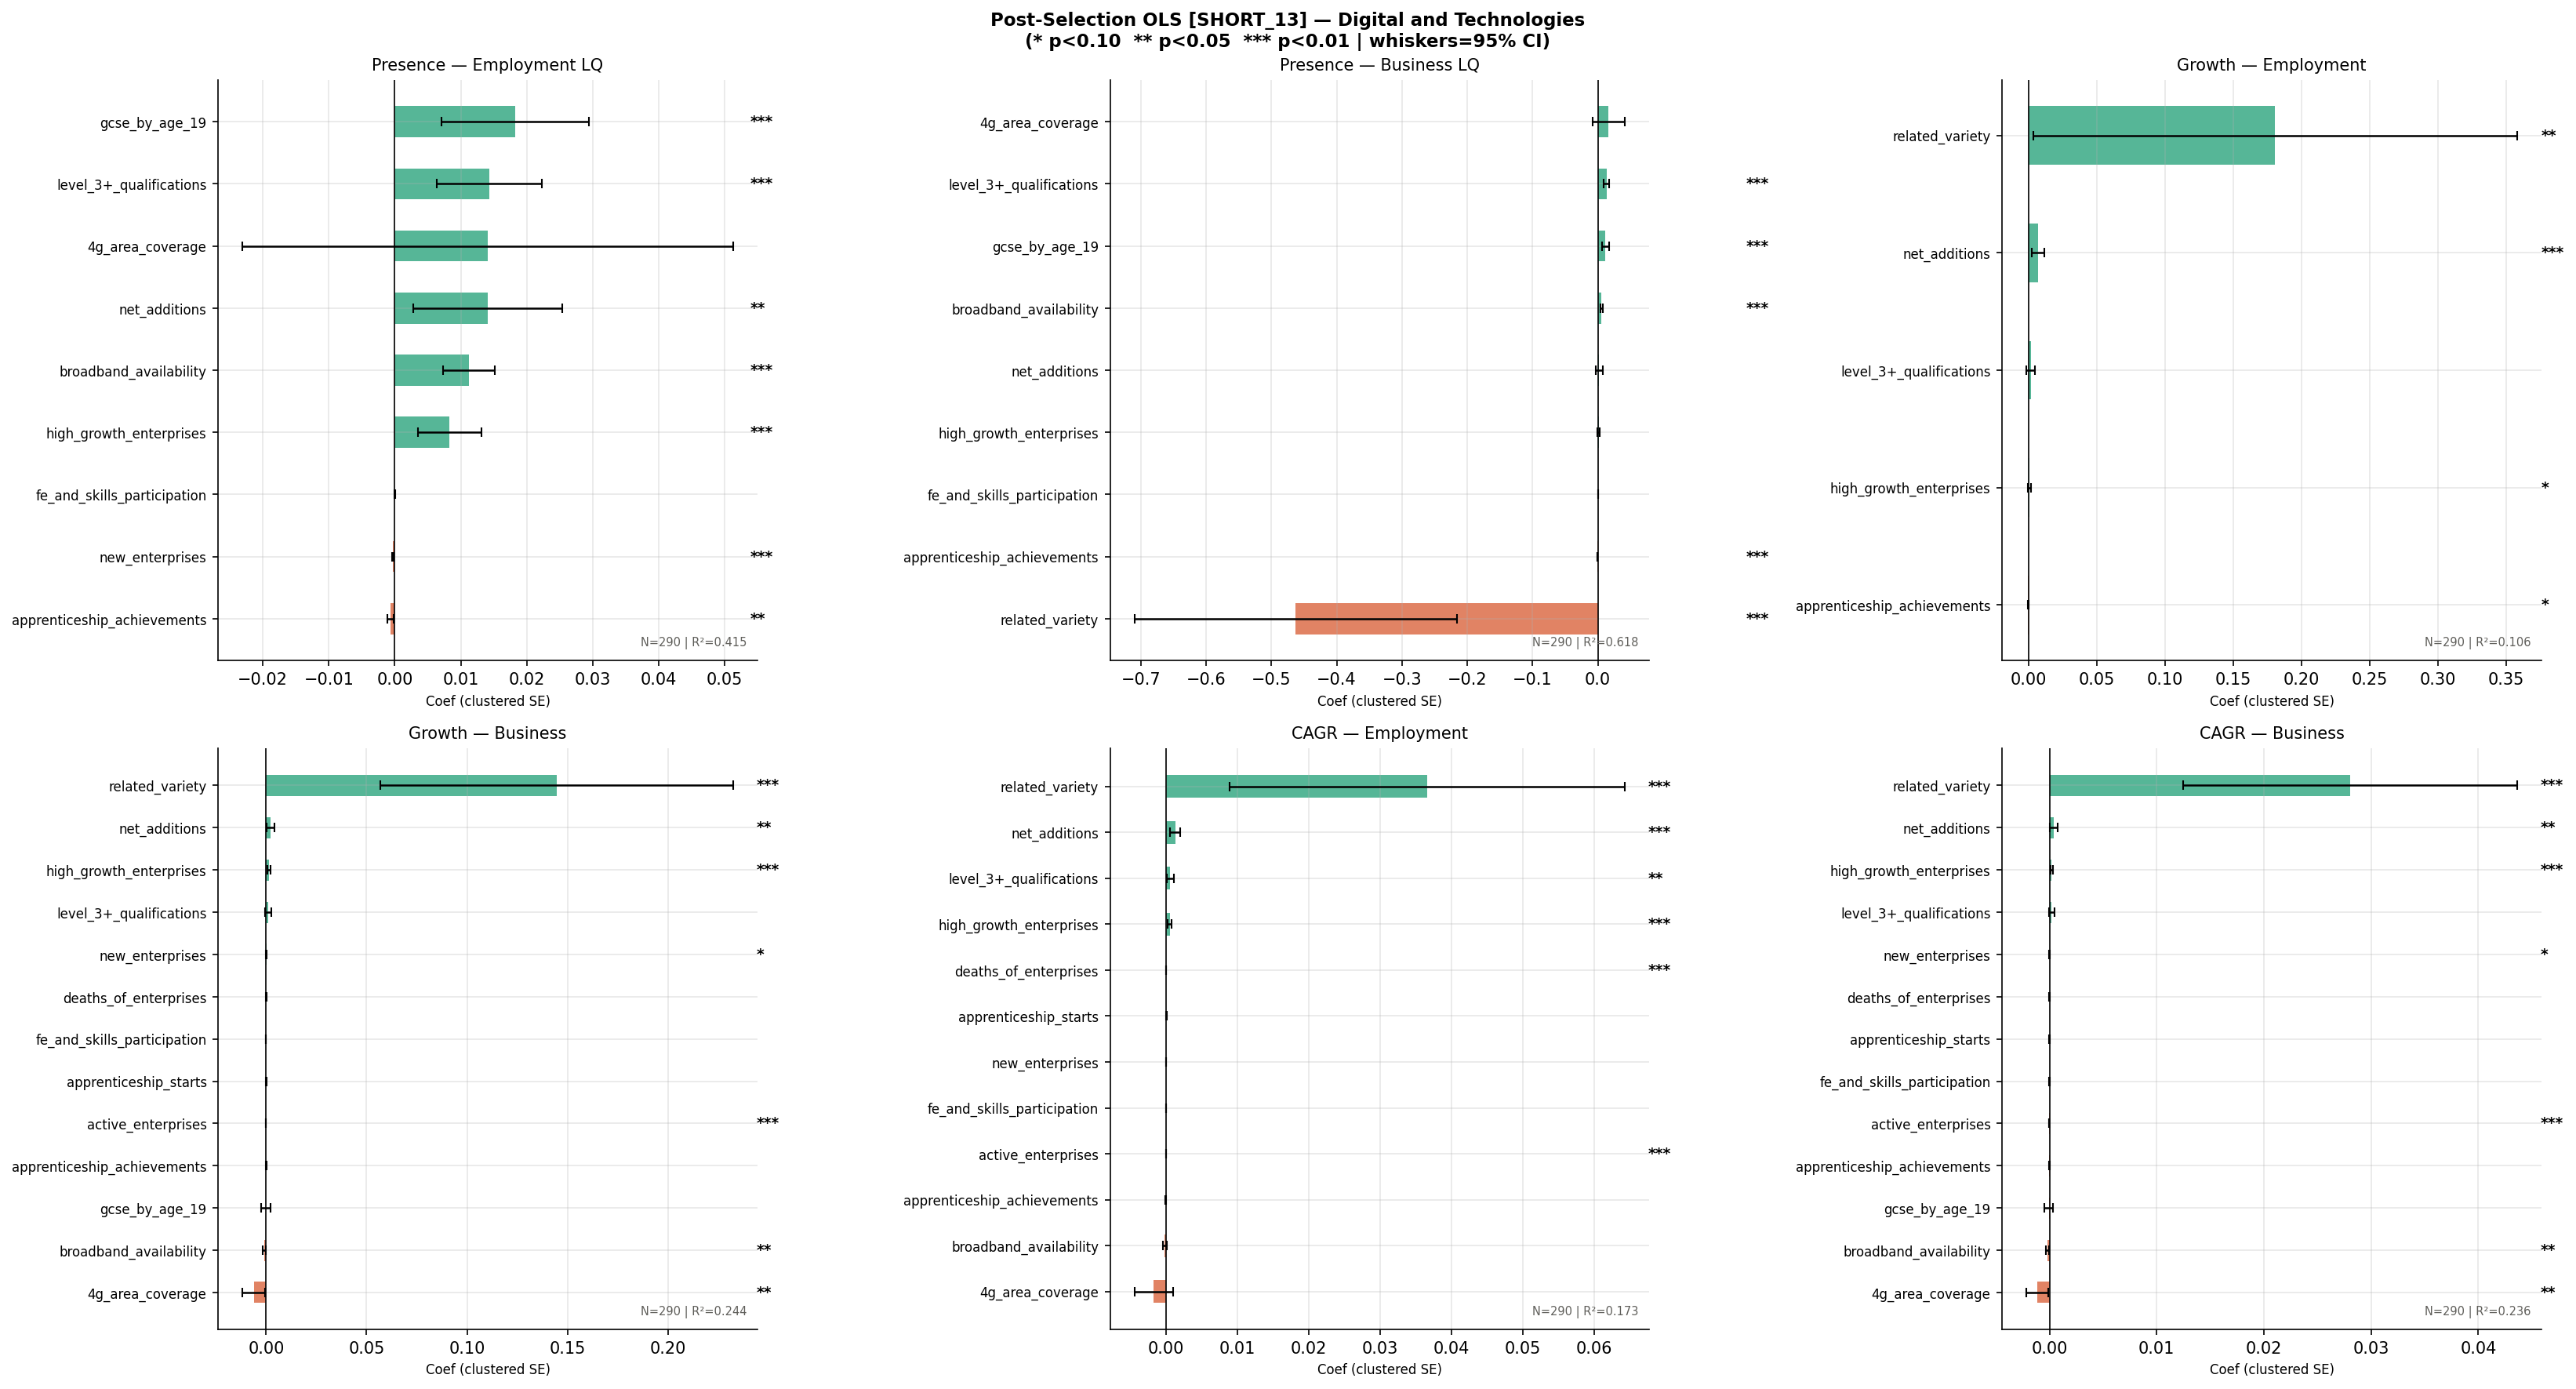

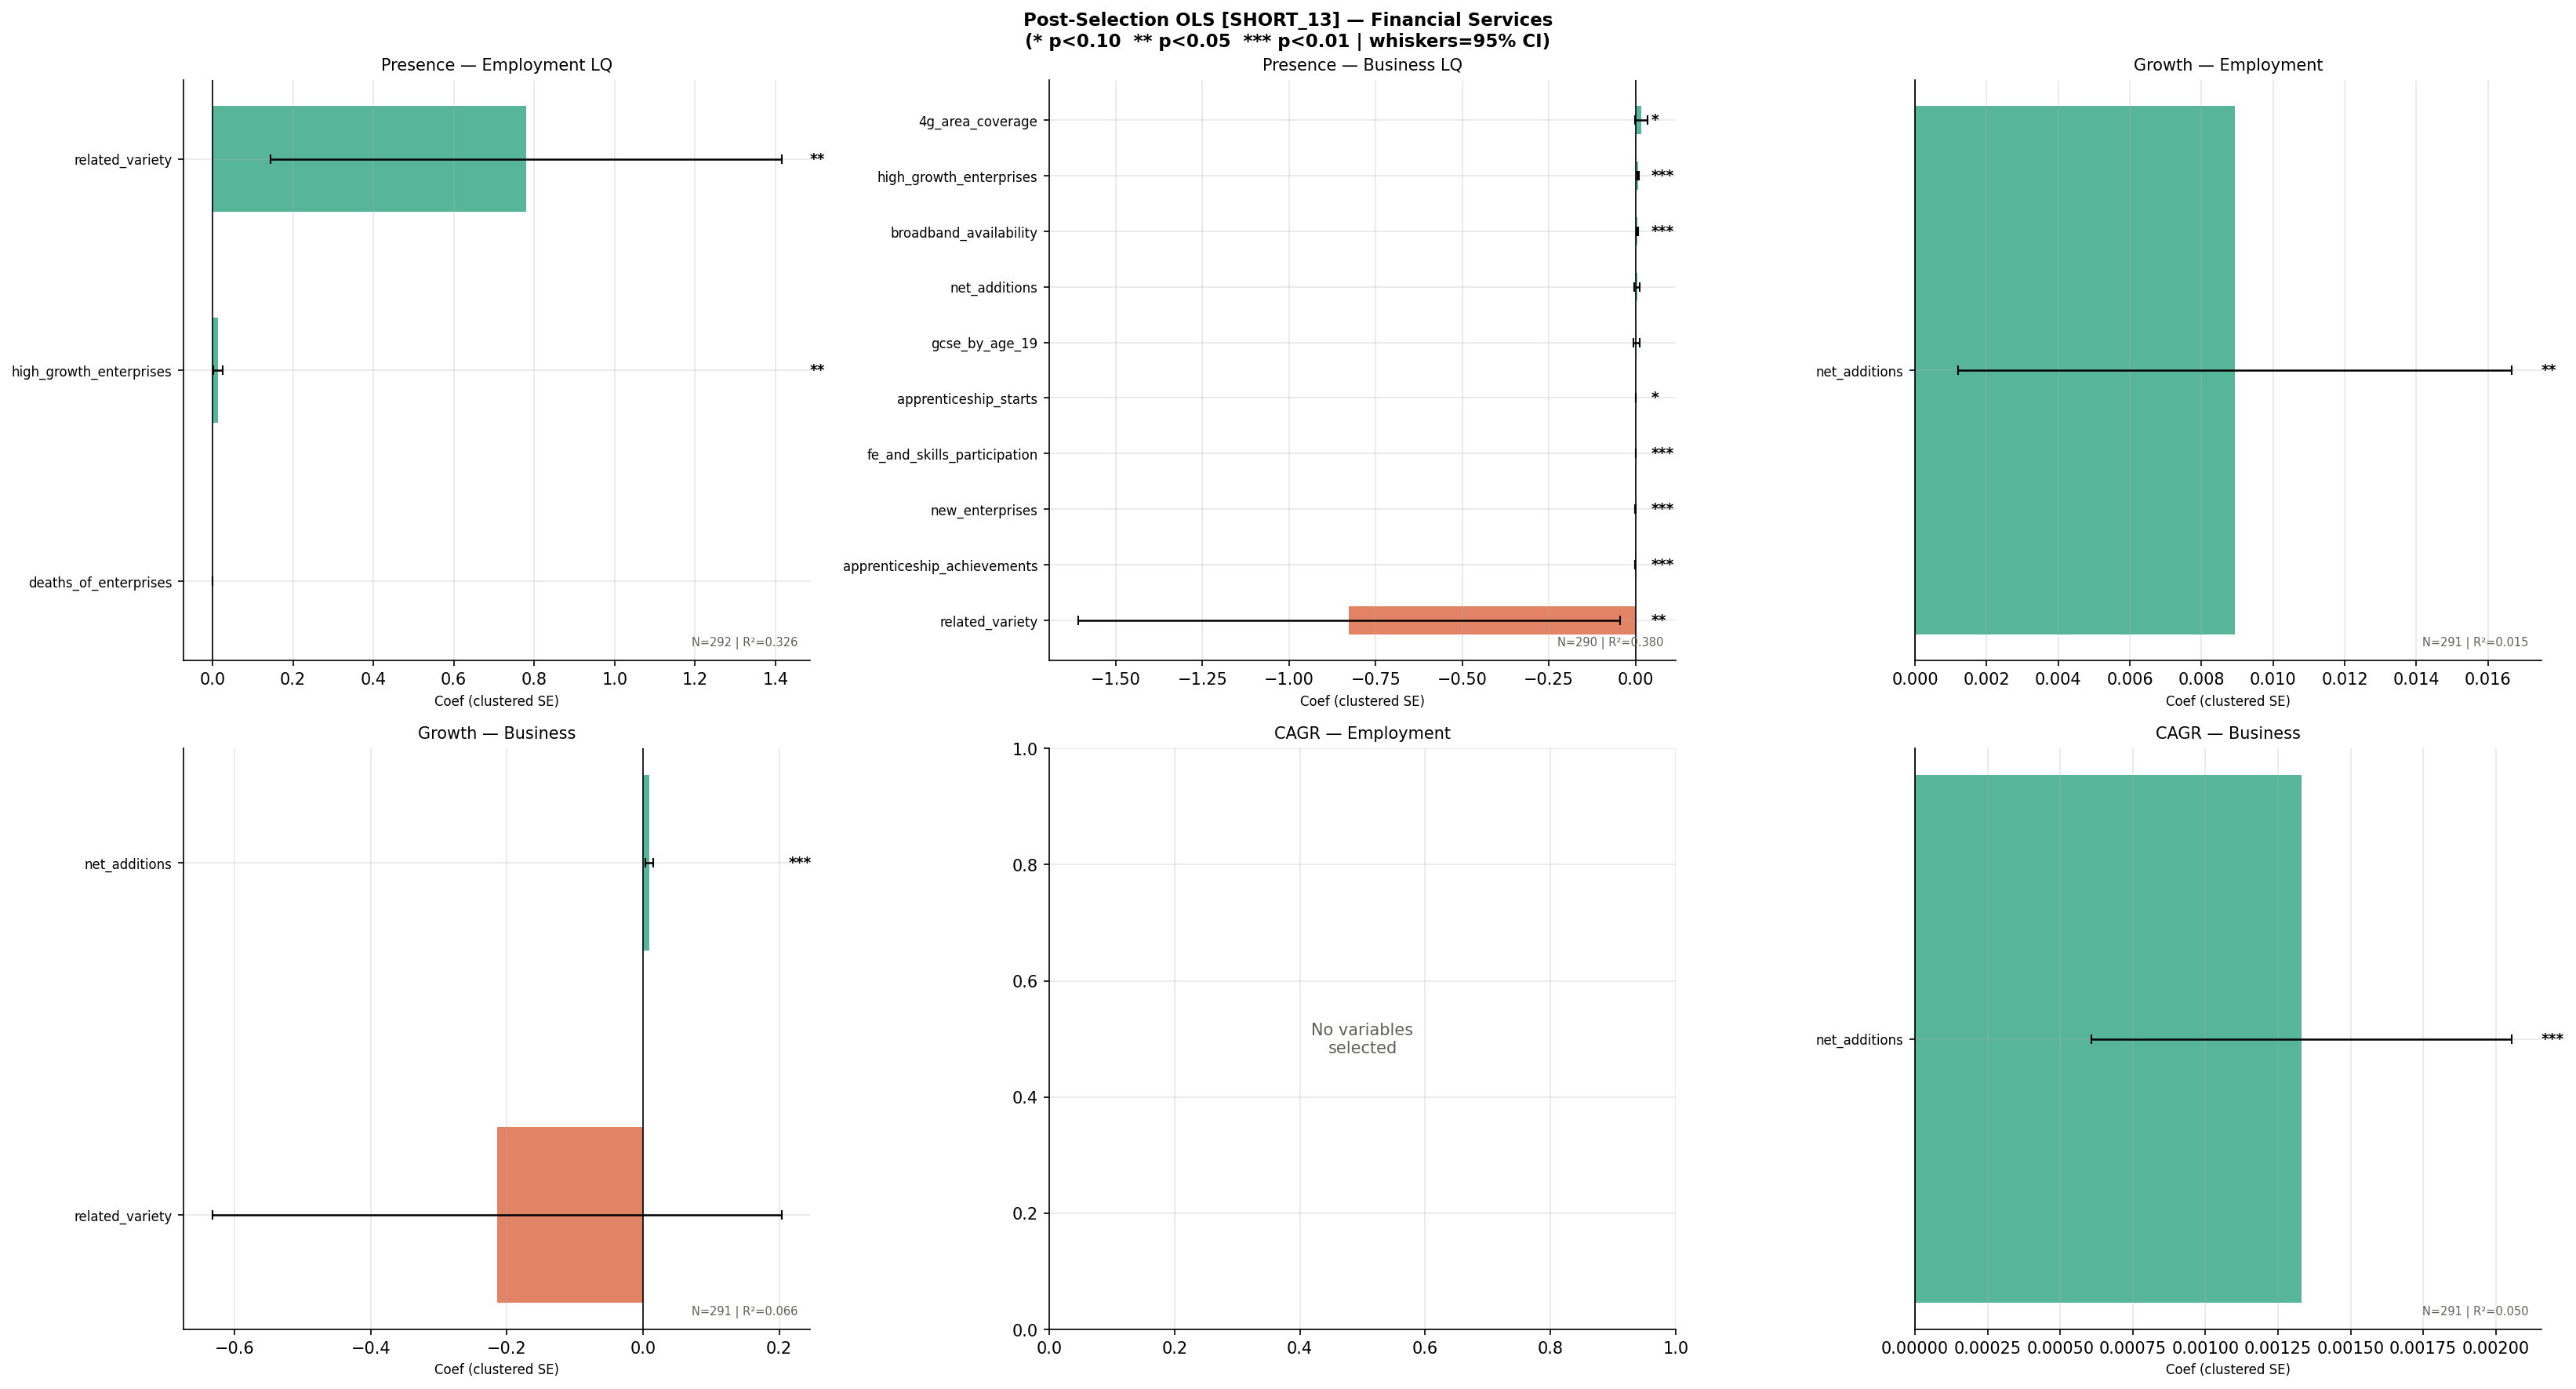

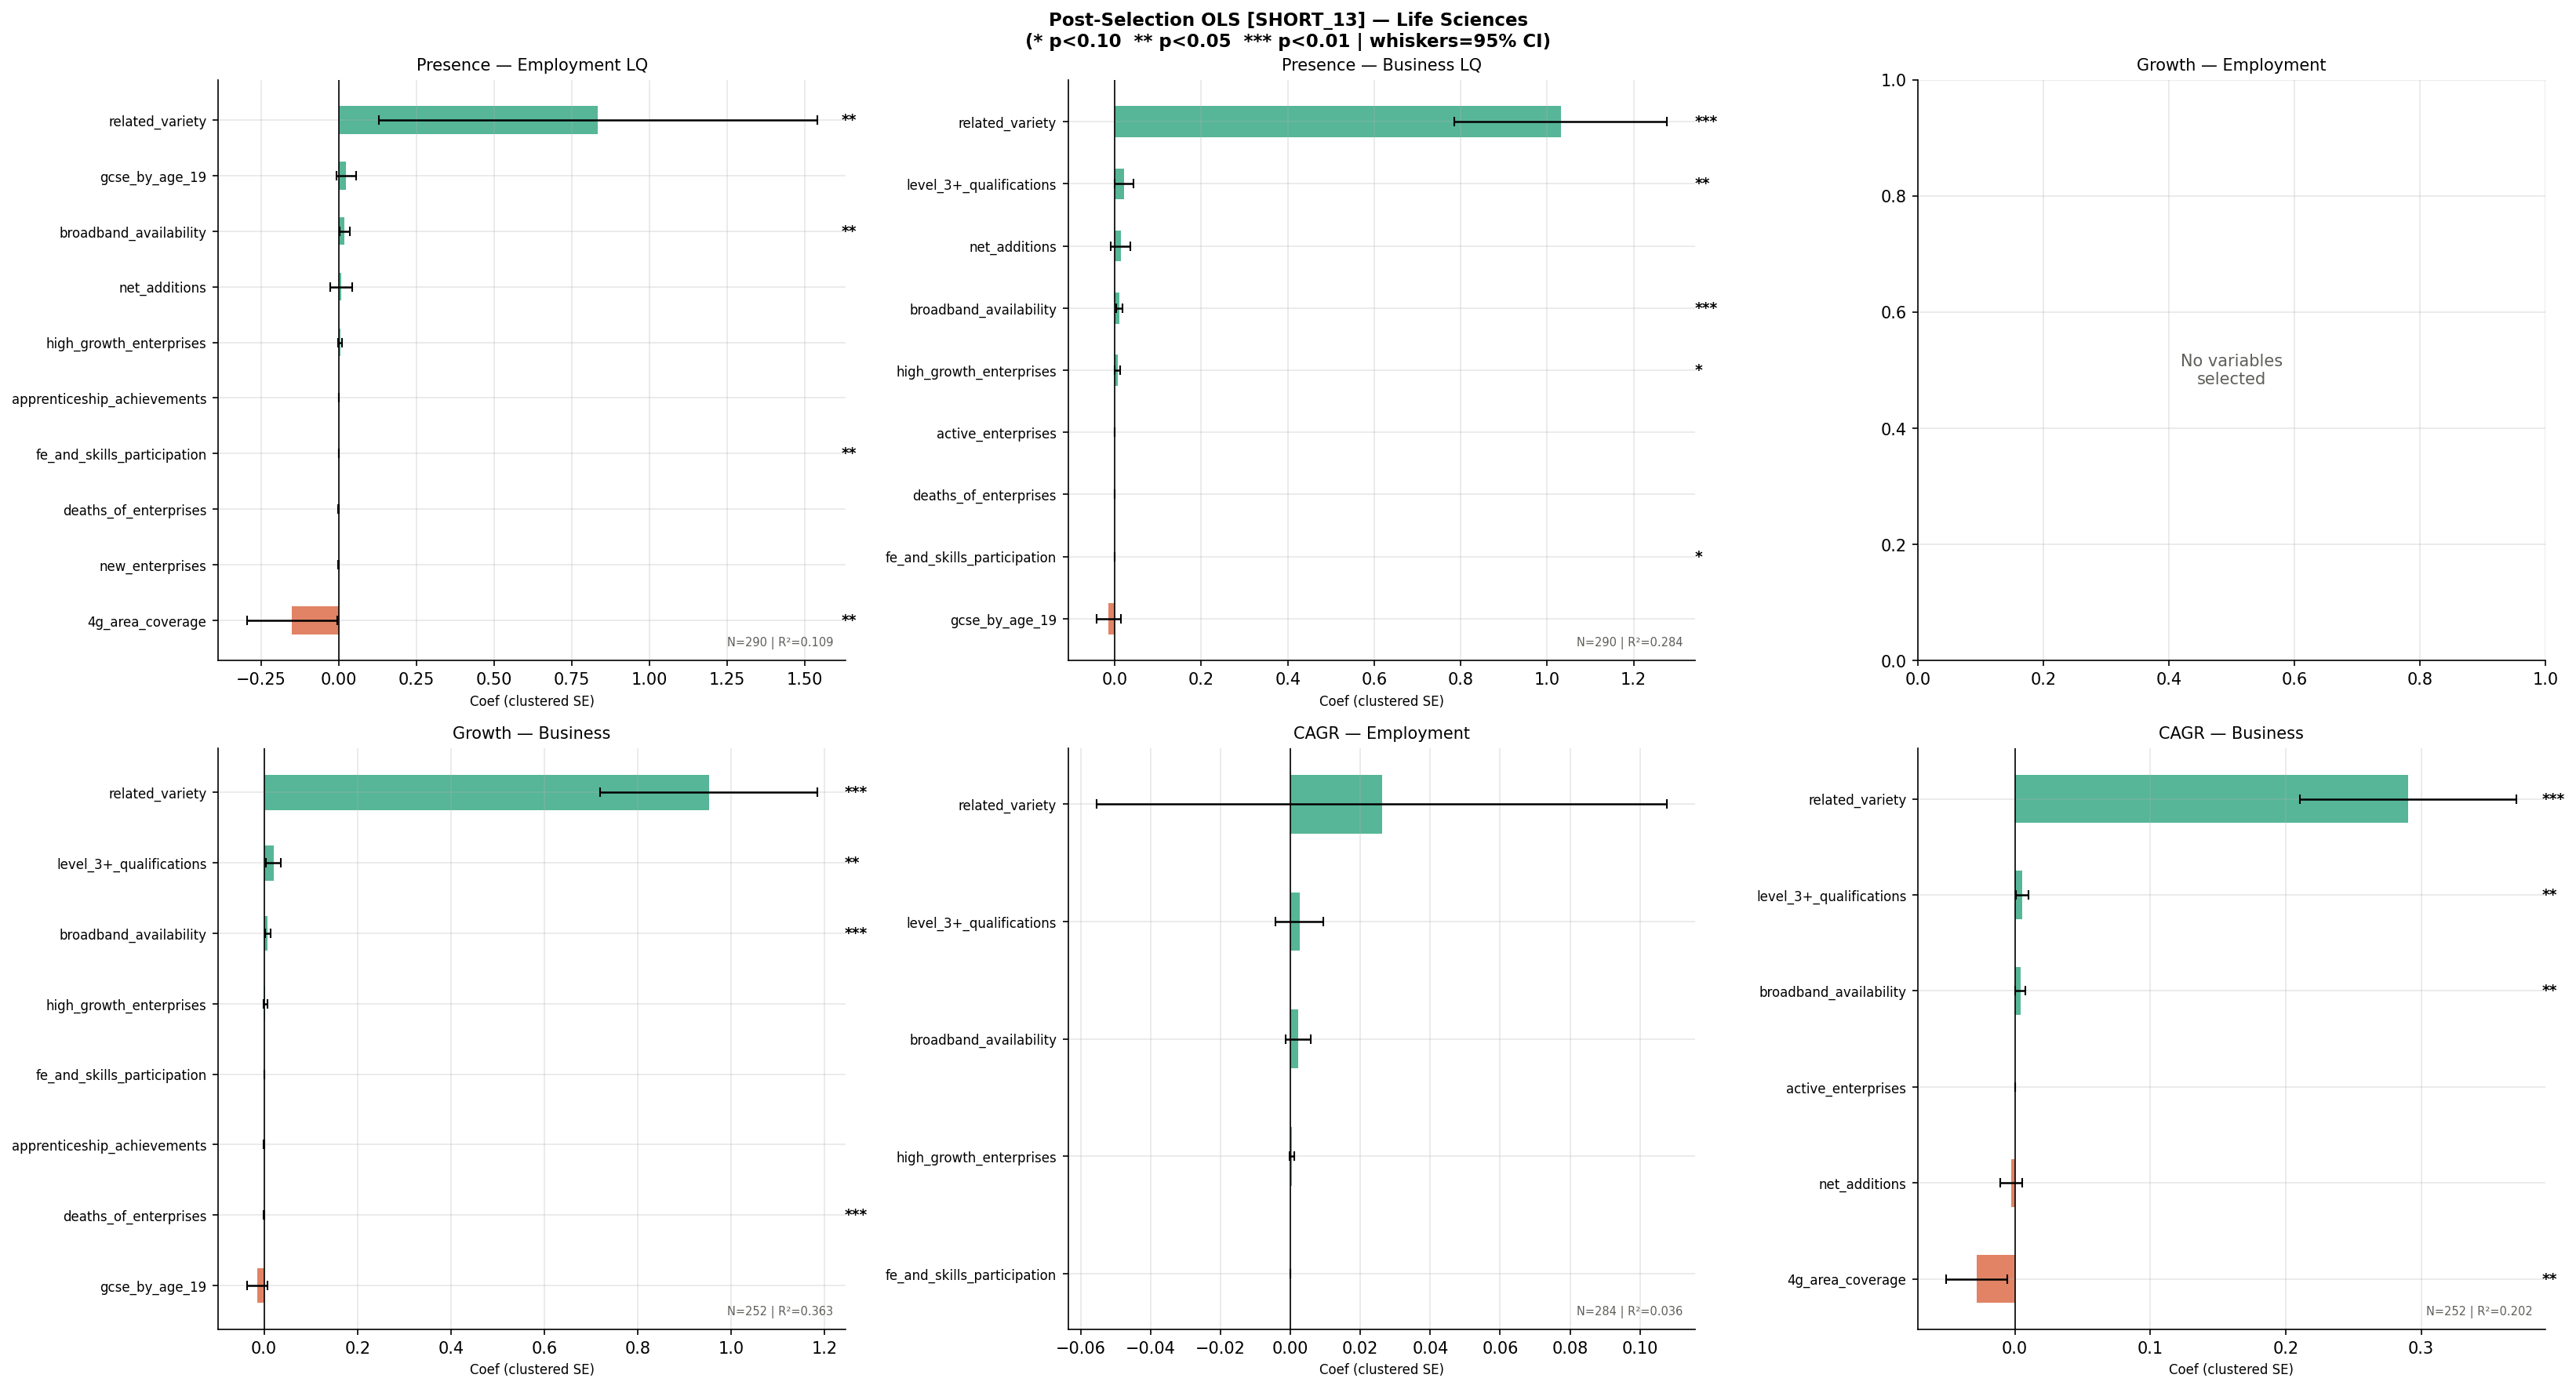

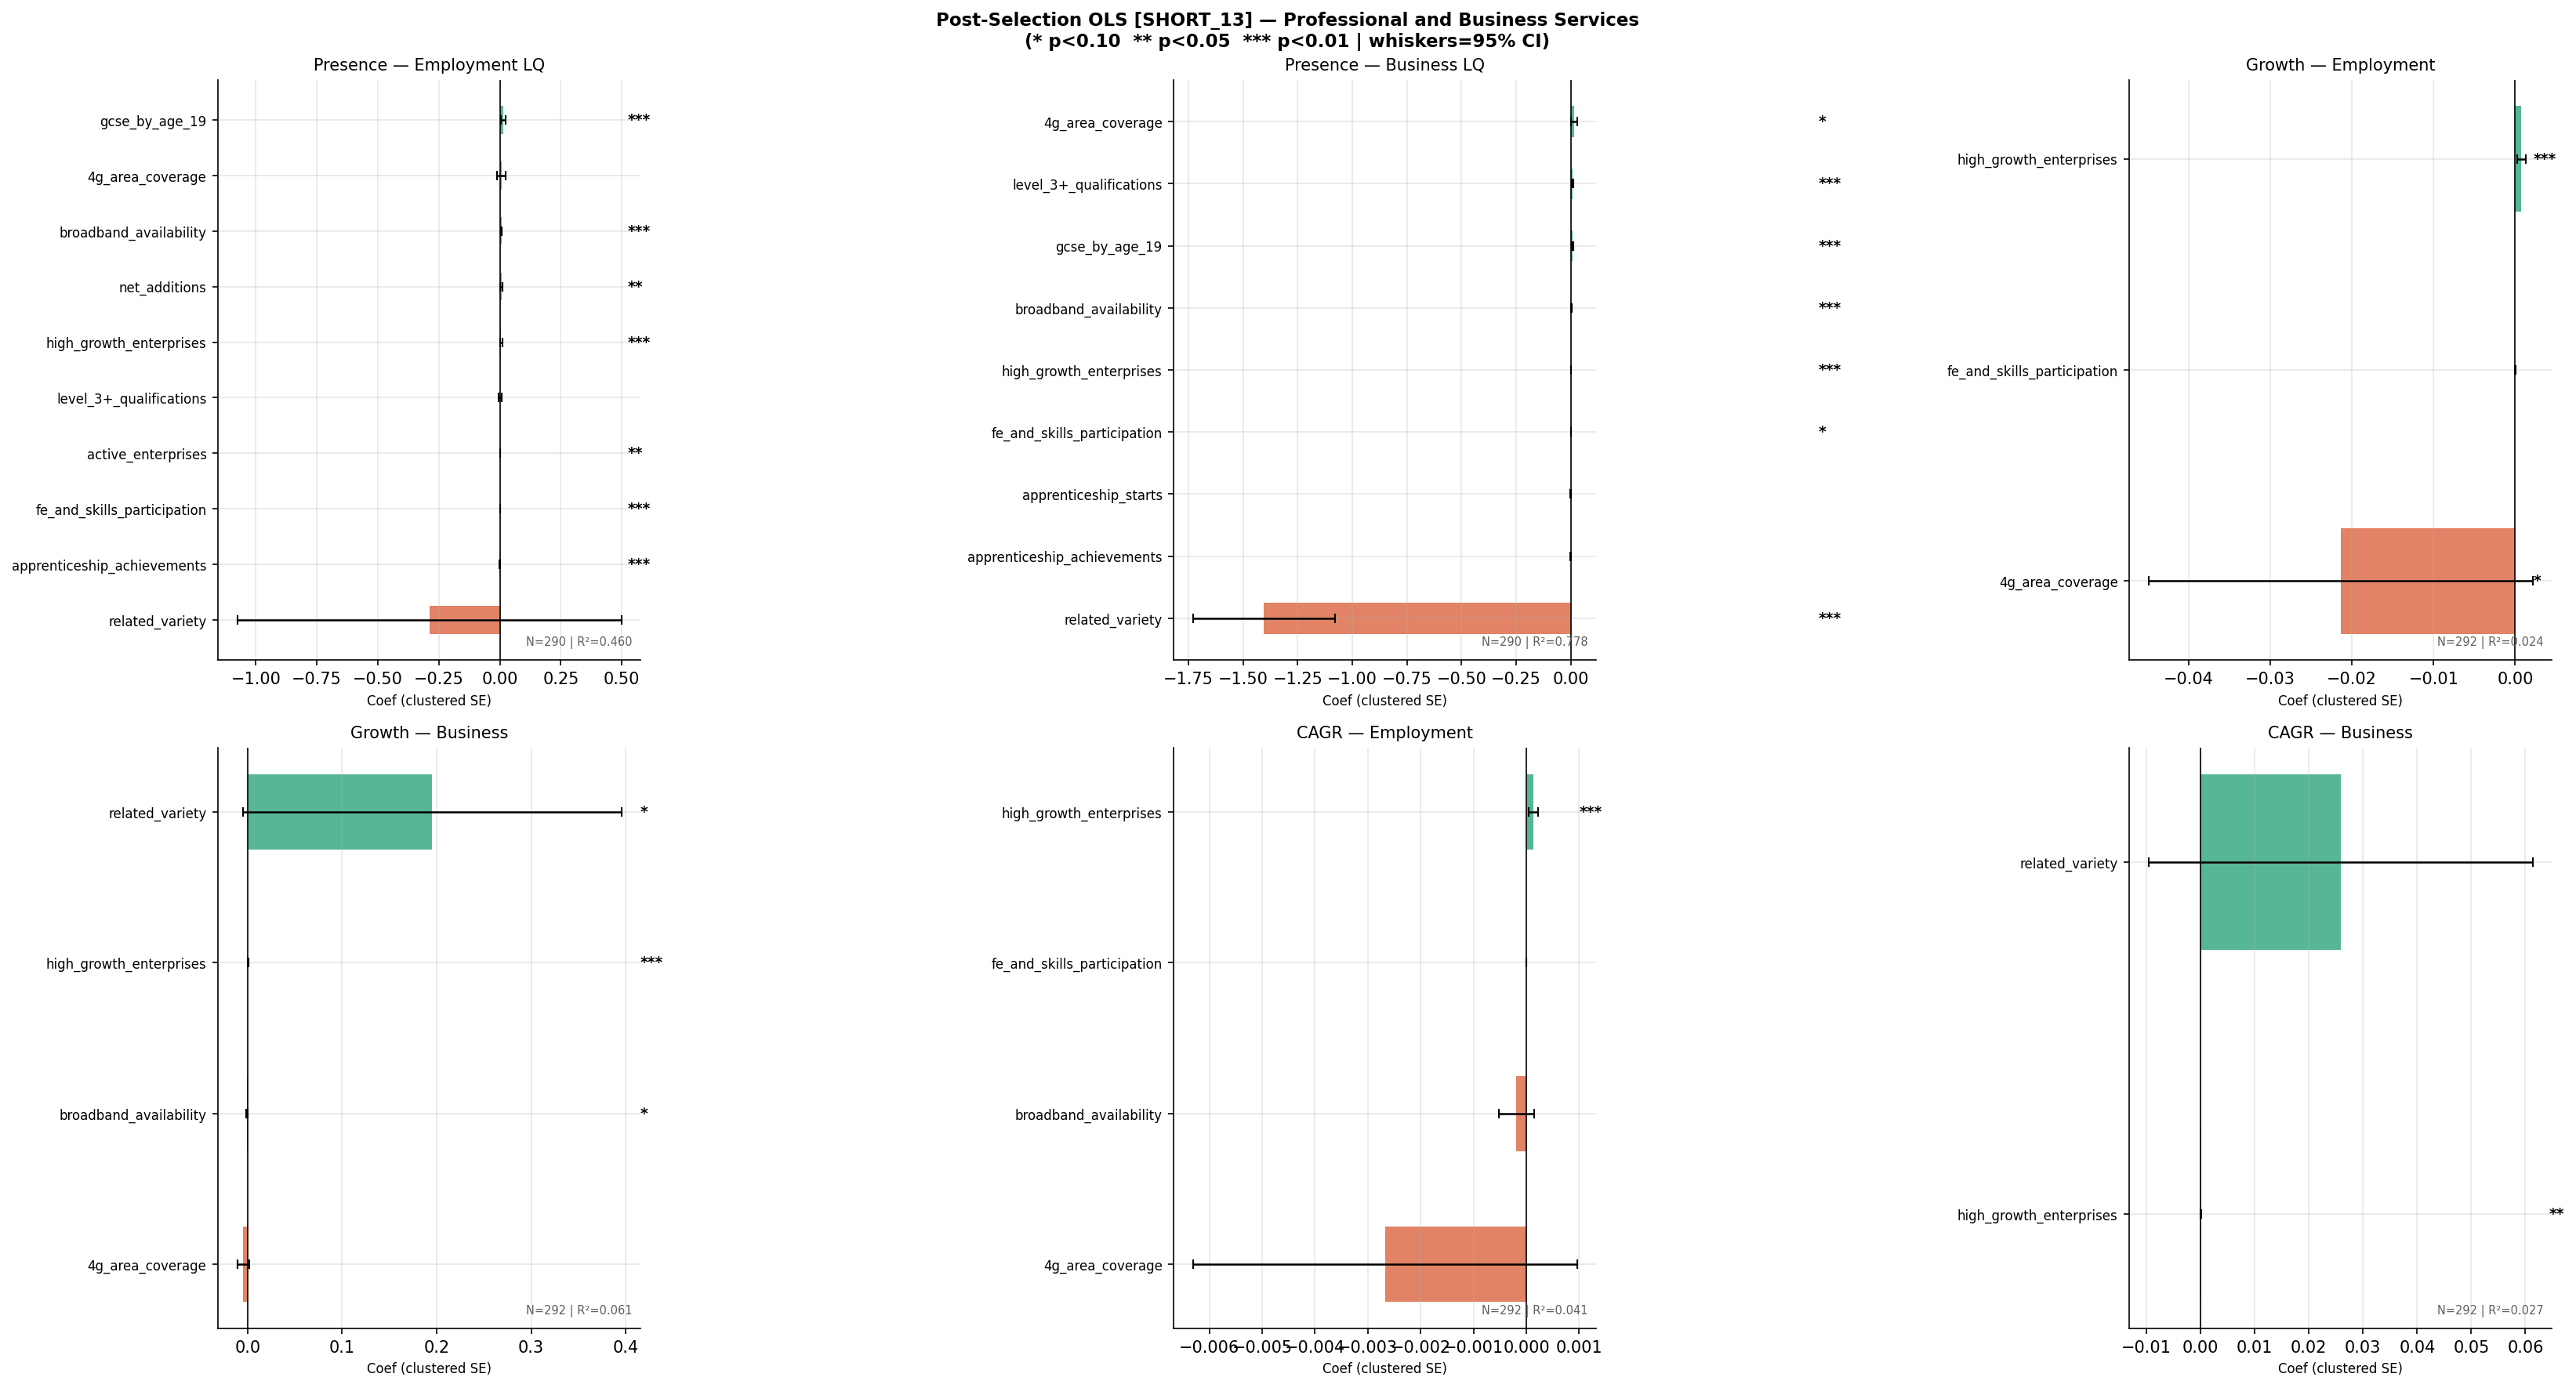

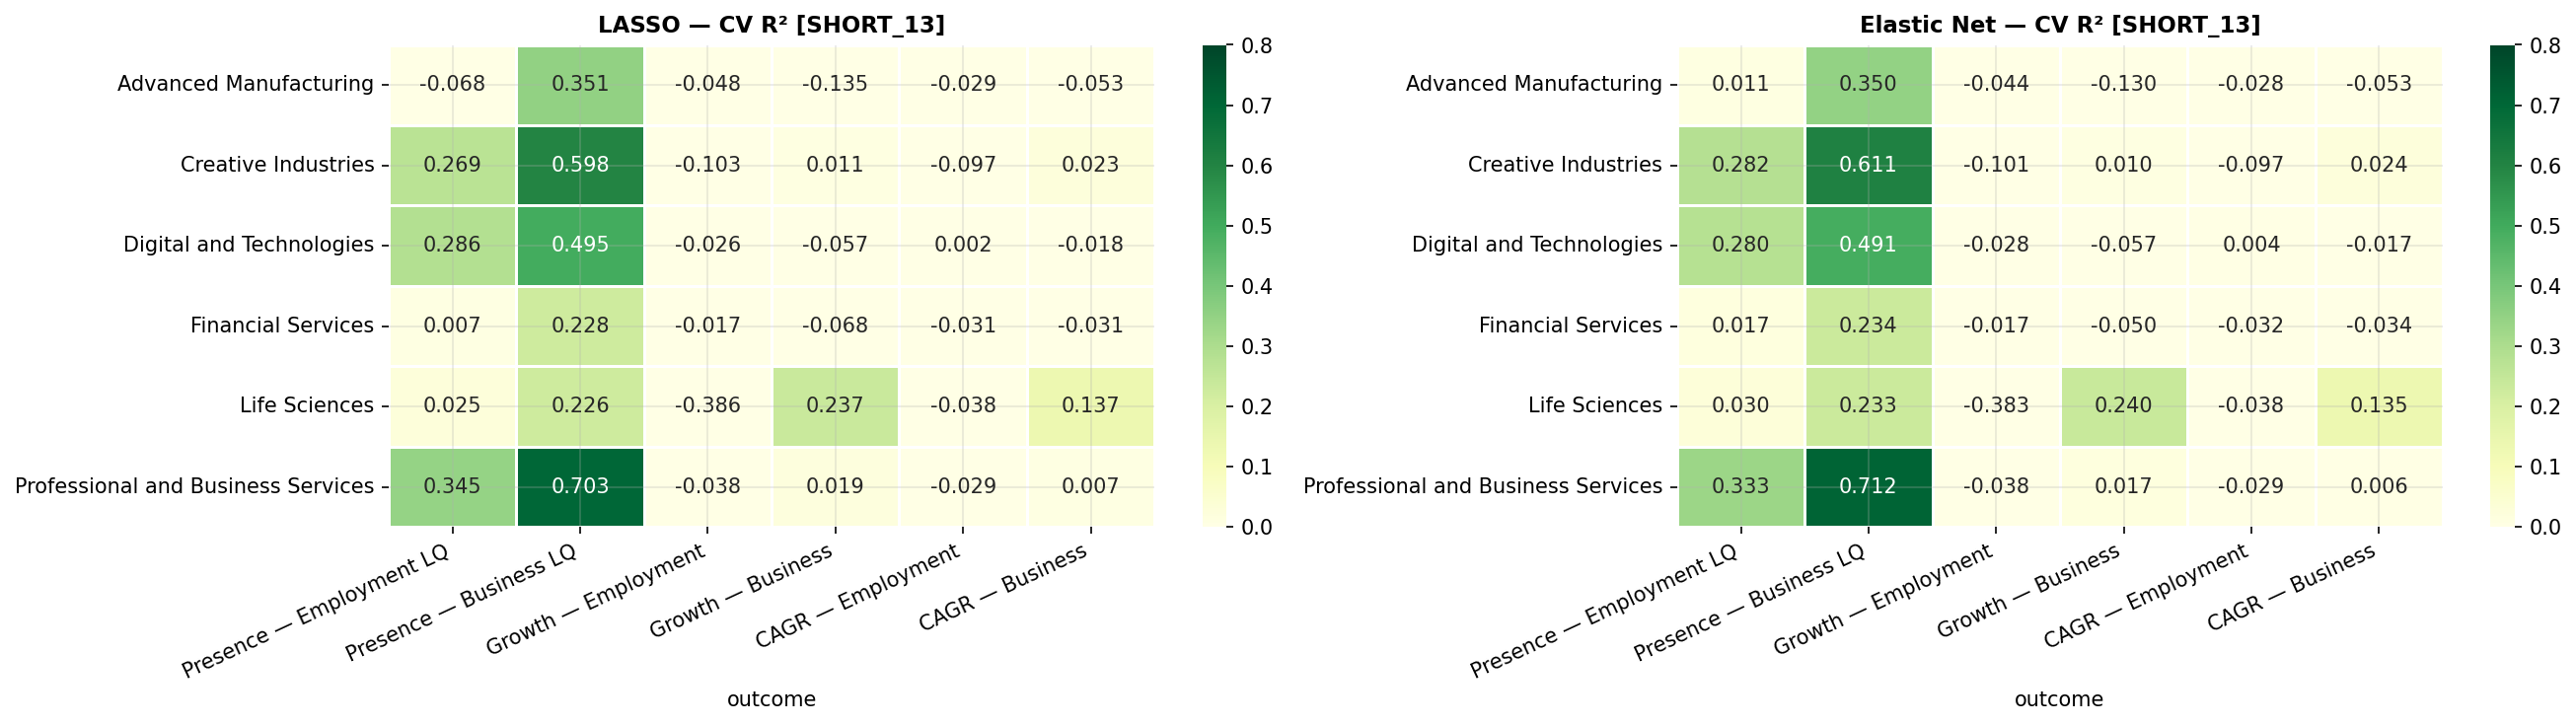

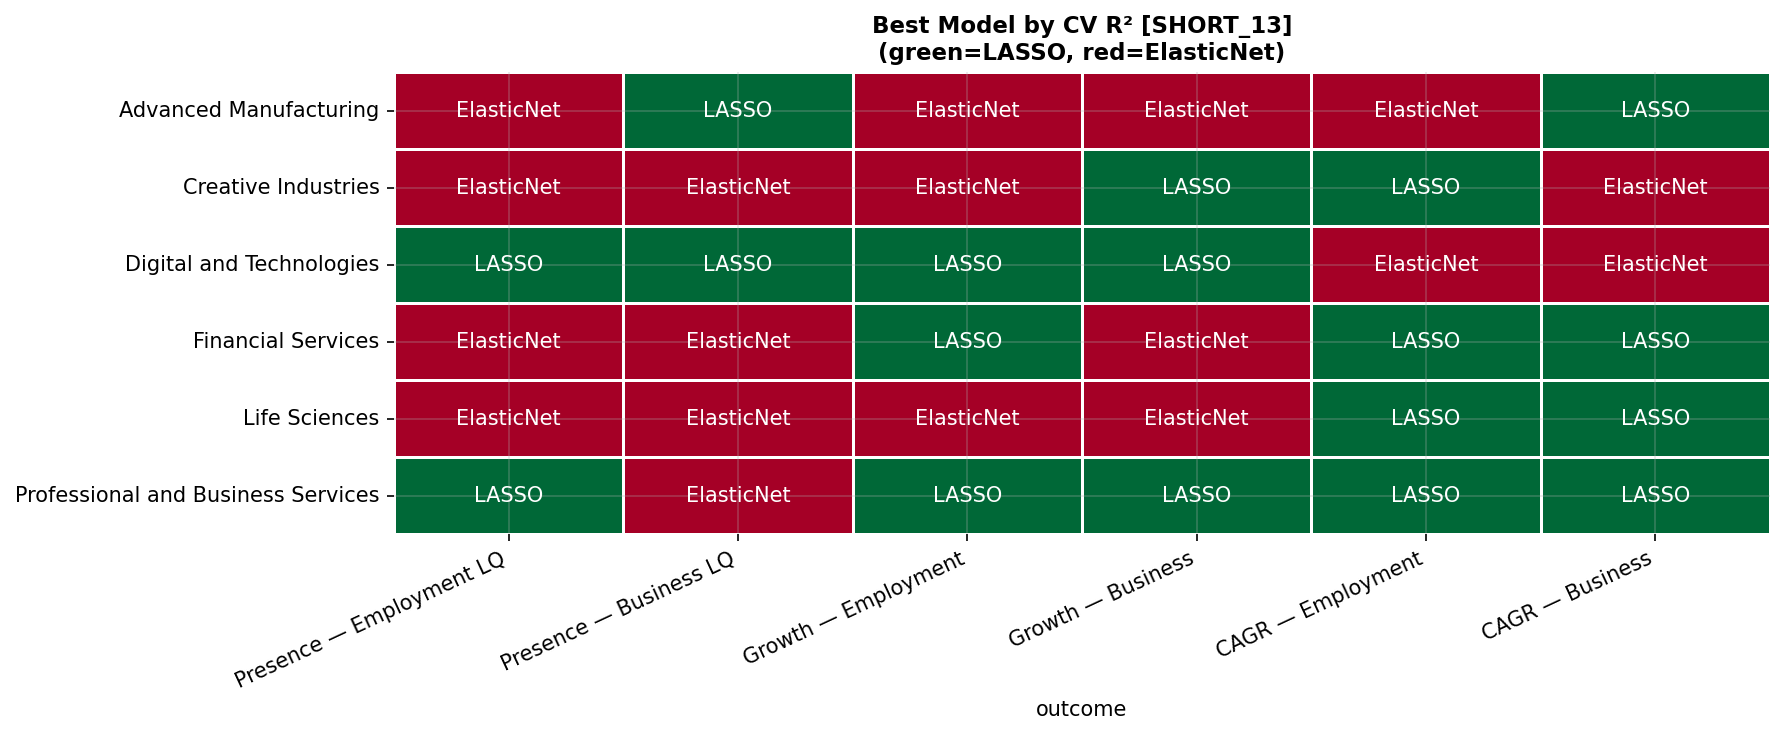


✅ [SHORT_13] saved to: output\lasso_short

SPEC: FULL_31 (31 predictors)

── Advanced Manufacturing ──
  ✓ Advanced Manufacturi | lq_emp     | N=239 | LASSO R²=0.154 | ENet R²=0.147 | Best=LASSO
  ✓ Advanced Manufacturi | lq_bus     | N=239 | LASSO R²=0.388 | ENet R²=0.386 | Best=LASSO
  ✓ Advanced Manufacturi | growth_emp | N=239 | LASSO R²=-0.040 | ENet R²=-0.040 | Best=LASSO
  ✓ Advanced Manufacturi | growth_bus | N=239 | LASSO R²=0.056 | ENet R²=0.046 | Best=LASSO
  ✓ Advanced Manufacturi | cagr_emp   | N=239 | LASSO R²=-0.023 | ENet R²=-0.023 | Best=LASSO
  ✓ Advanced Manufacturi | cagr_bus   | N=239 | LASSO R²=0.081 | ENet R²=0.079 | Best=LASSO

── Creative Industries ──
  ✓ Creative Industries | lq_emp     | N=239 | LASSO R²=0.557 | ENet R²=0.579 | Best=ElasticNet
  ✓ Creative Industries | lq_bus     | N=239 | LASSO R²=0.653 | ENet R²=0.649 | Best=LASSO
  ✓ Creative Industries | growth_emp | N=239 | LASSO R²=-0.059 | ENet R²=-0.057 | Best=ElasticNet
  ✓ Creative Industries | gr

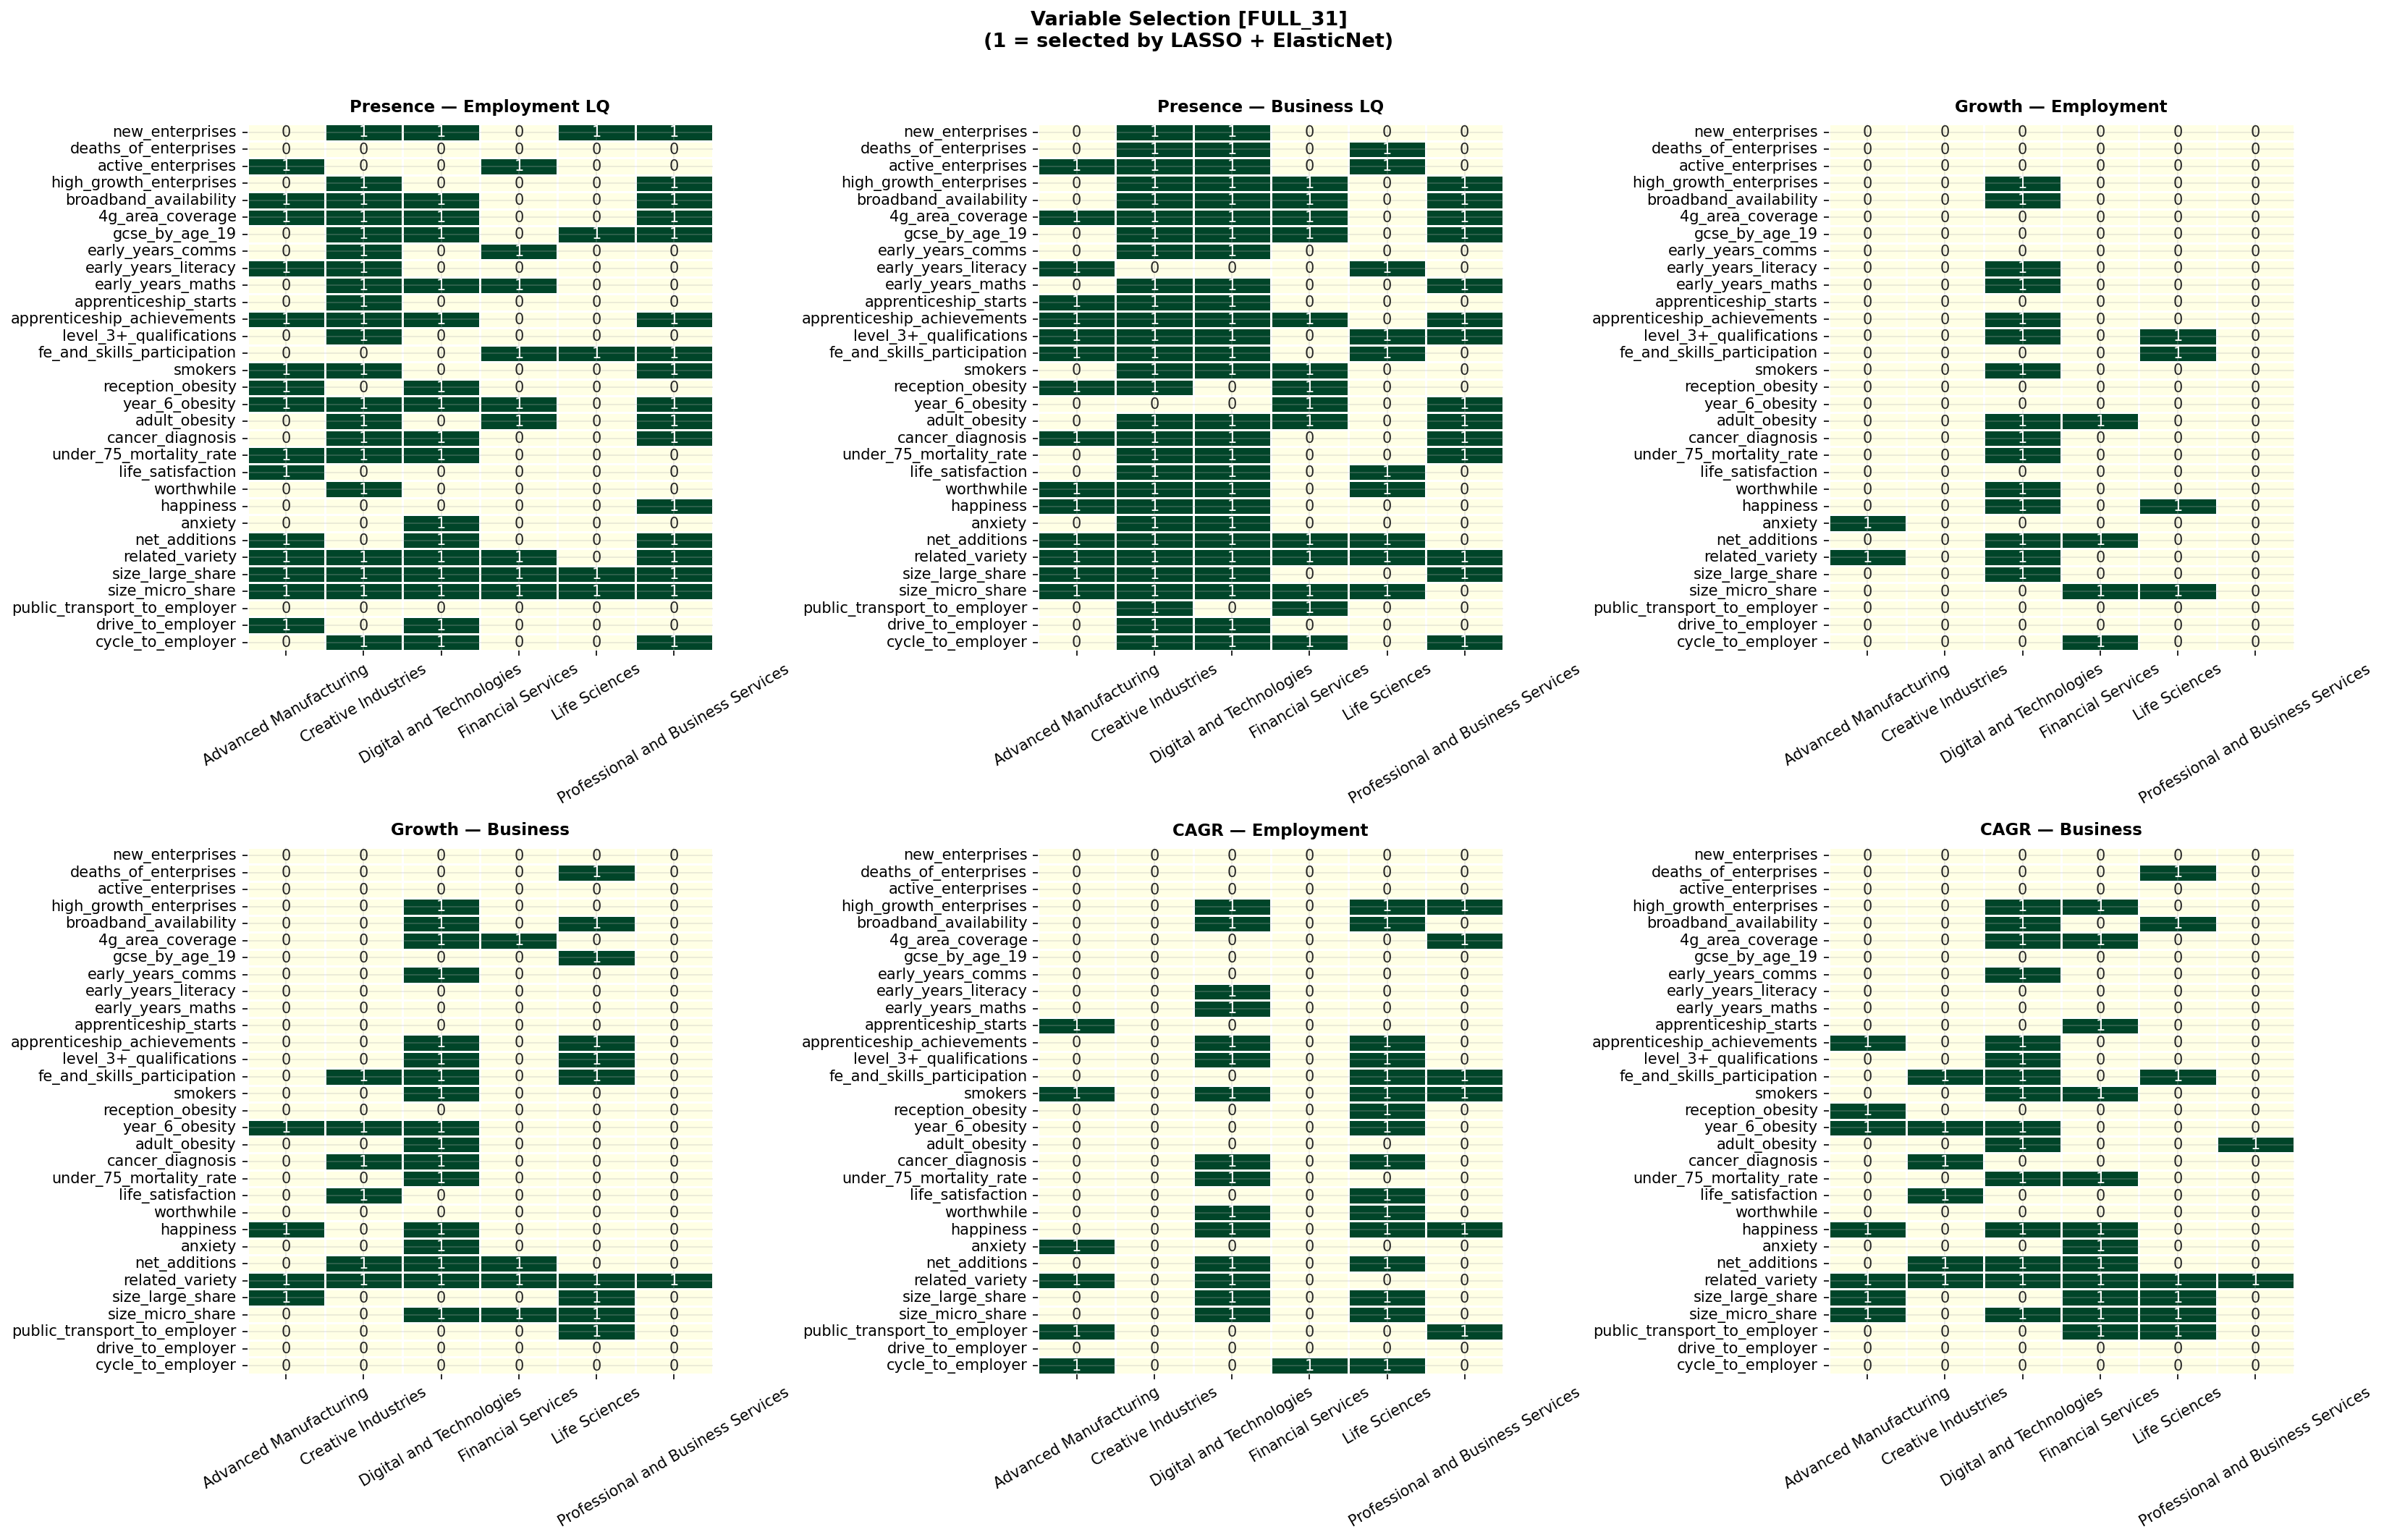

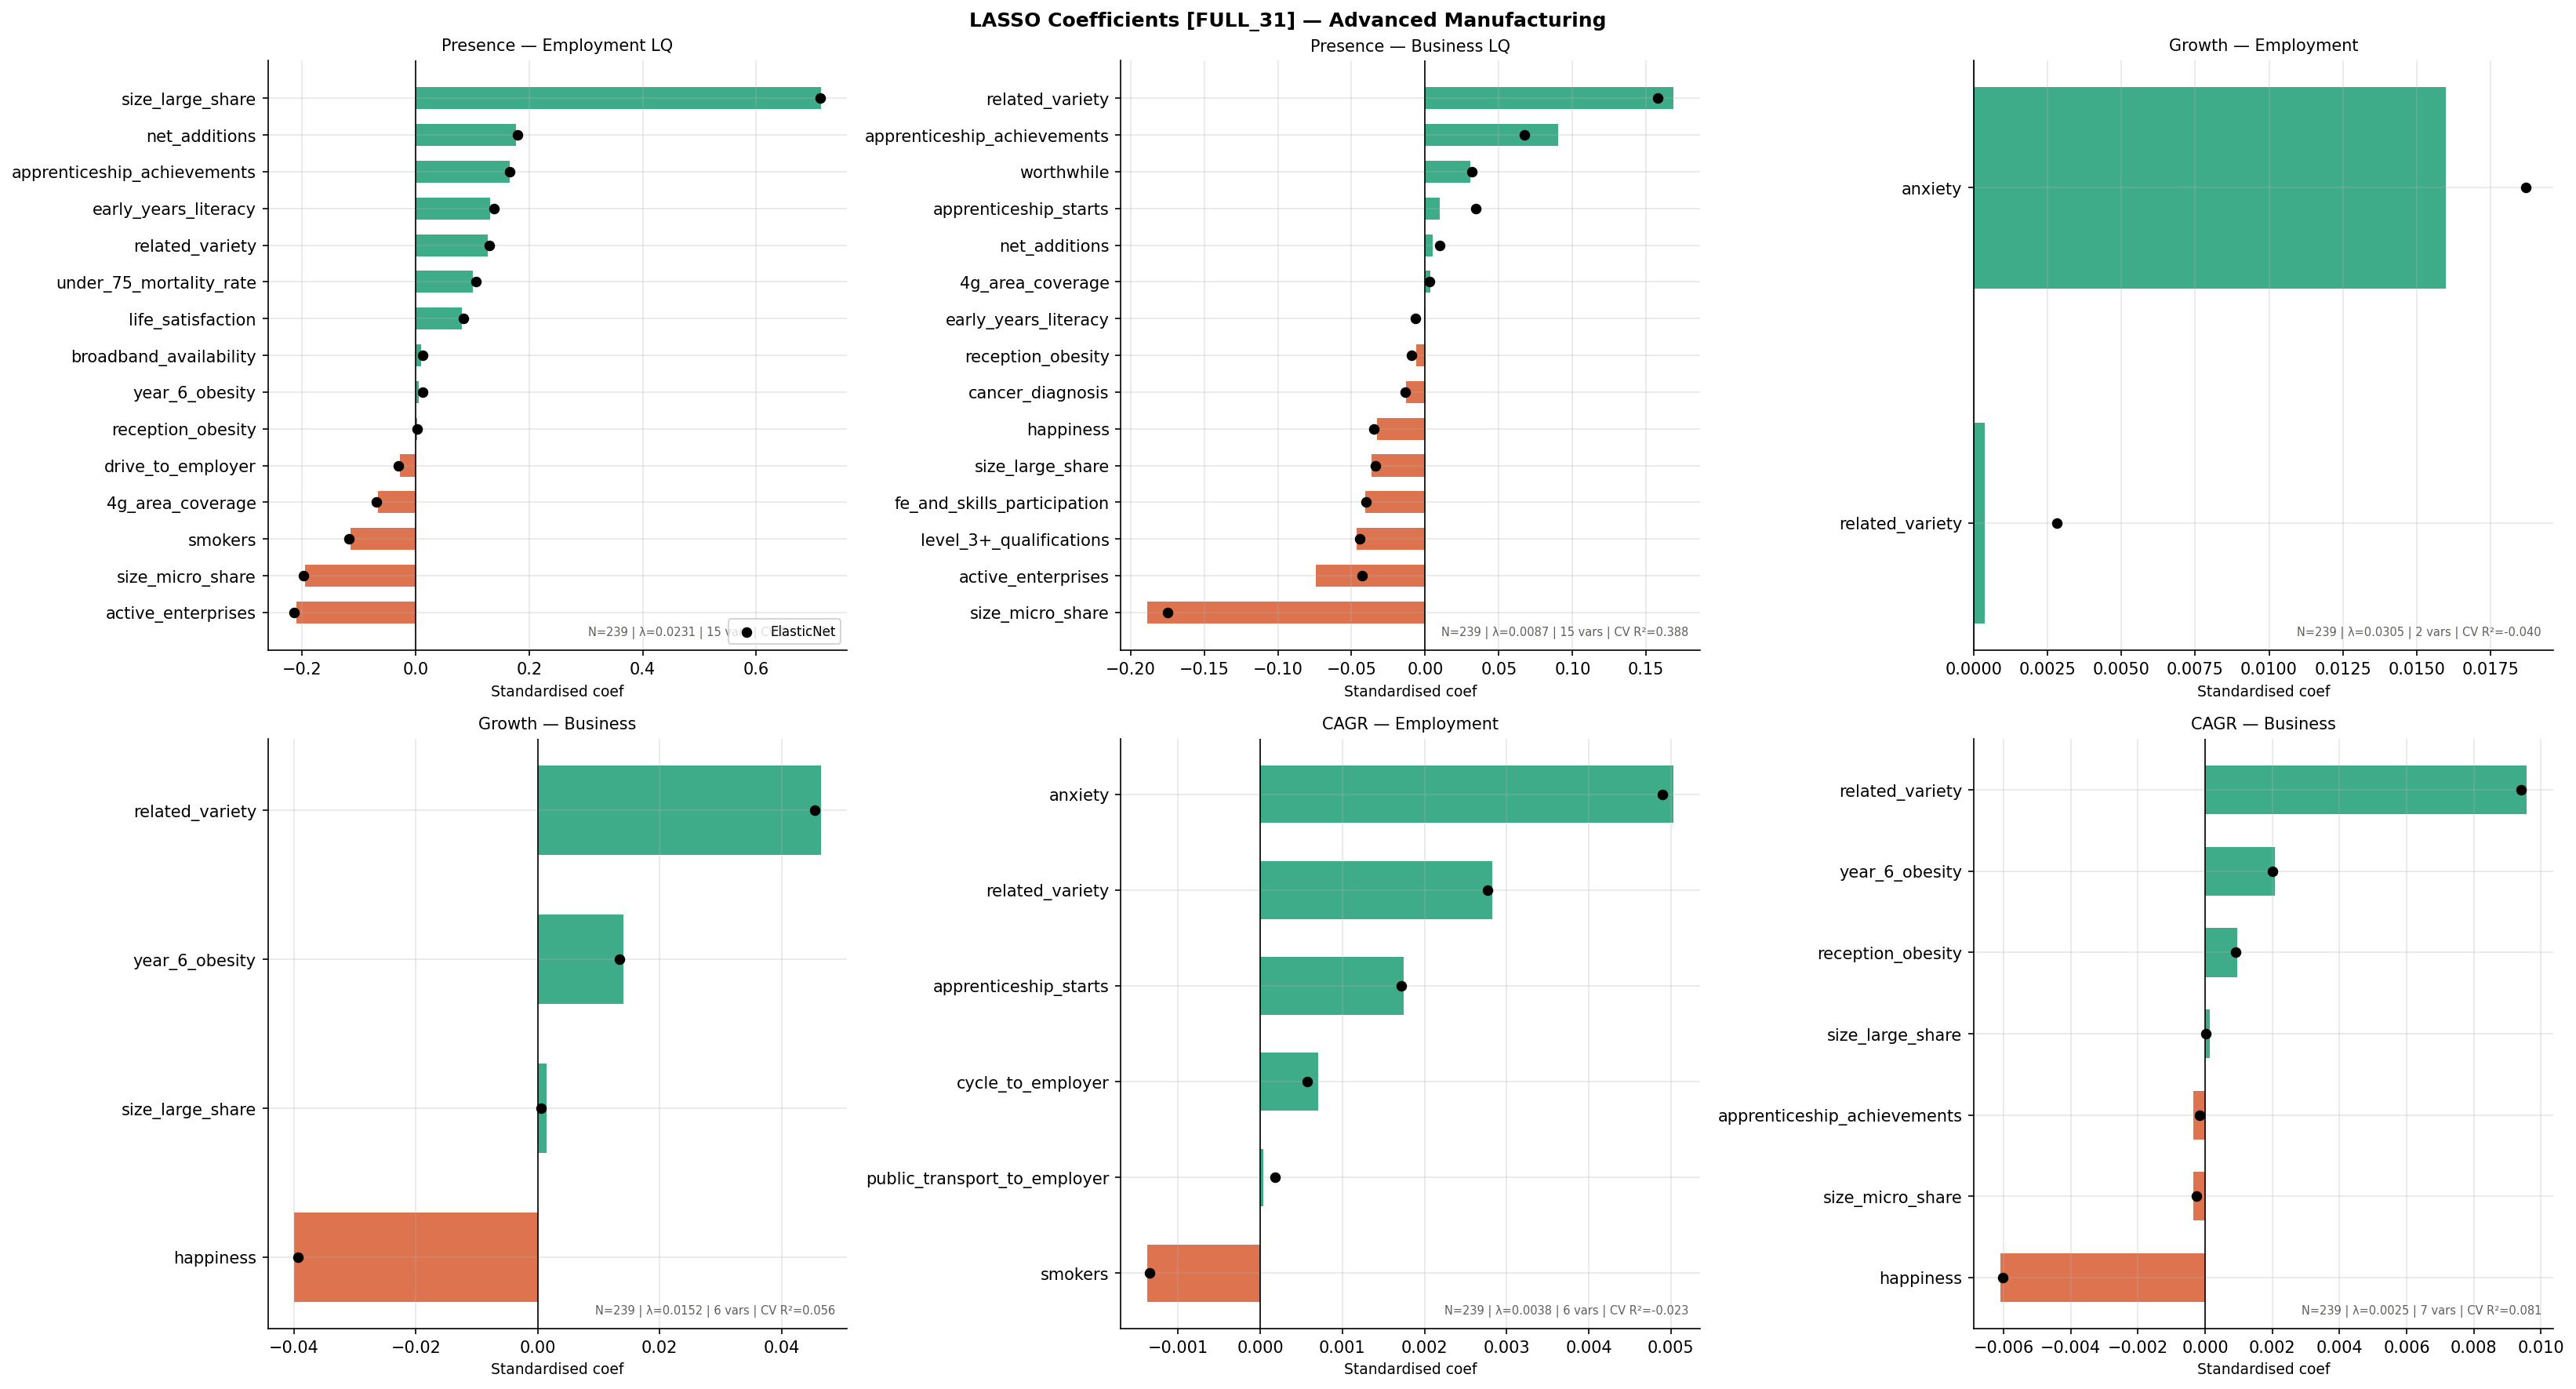

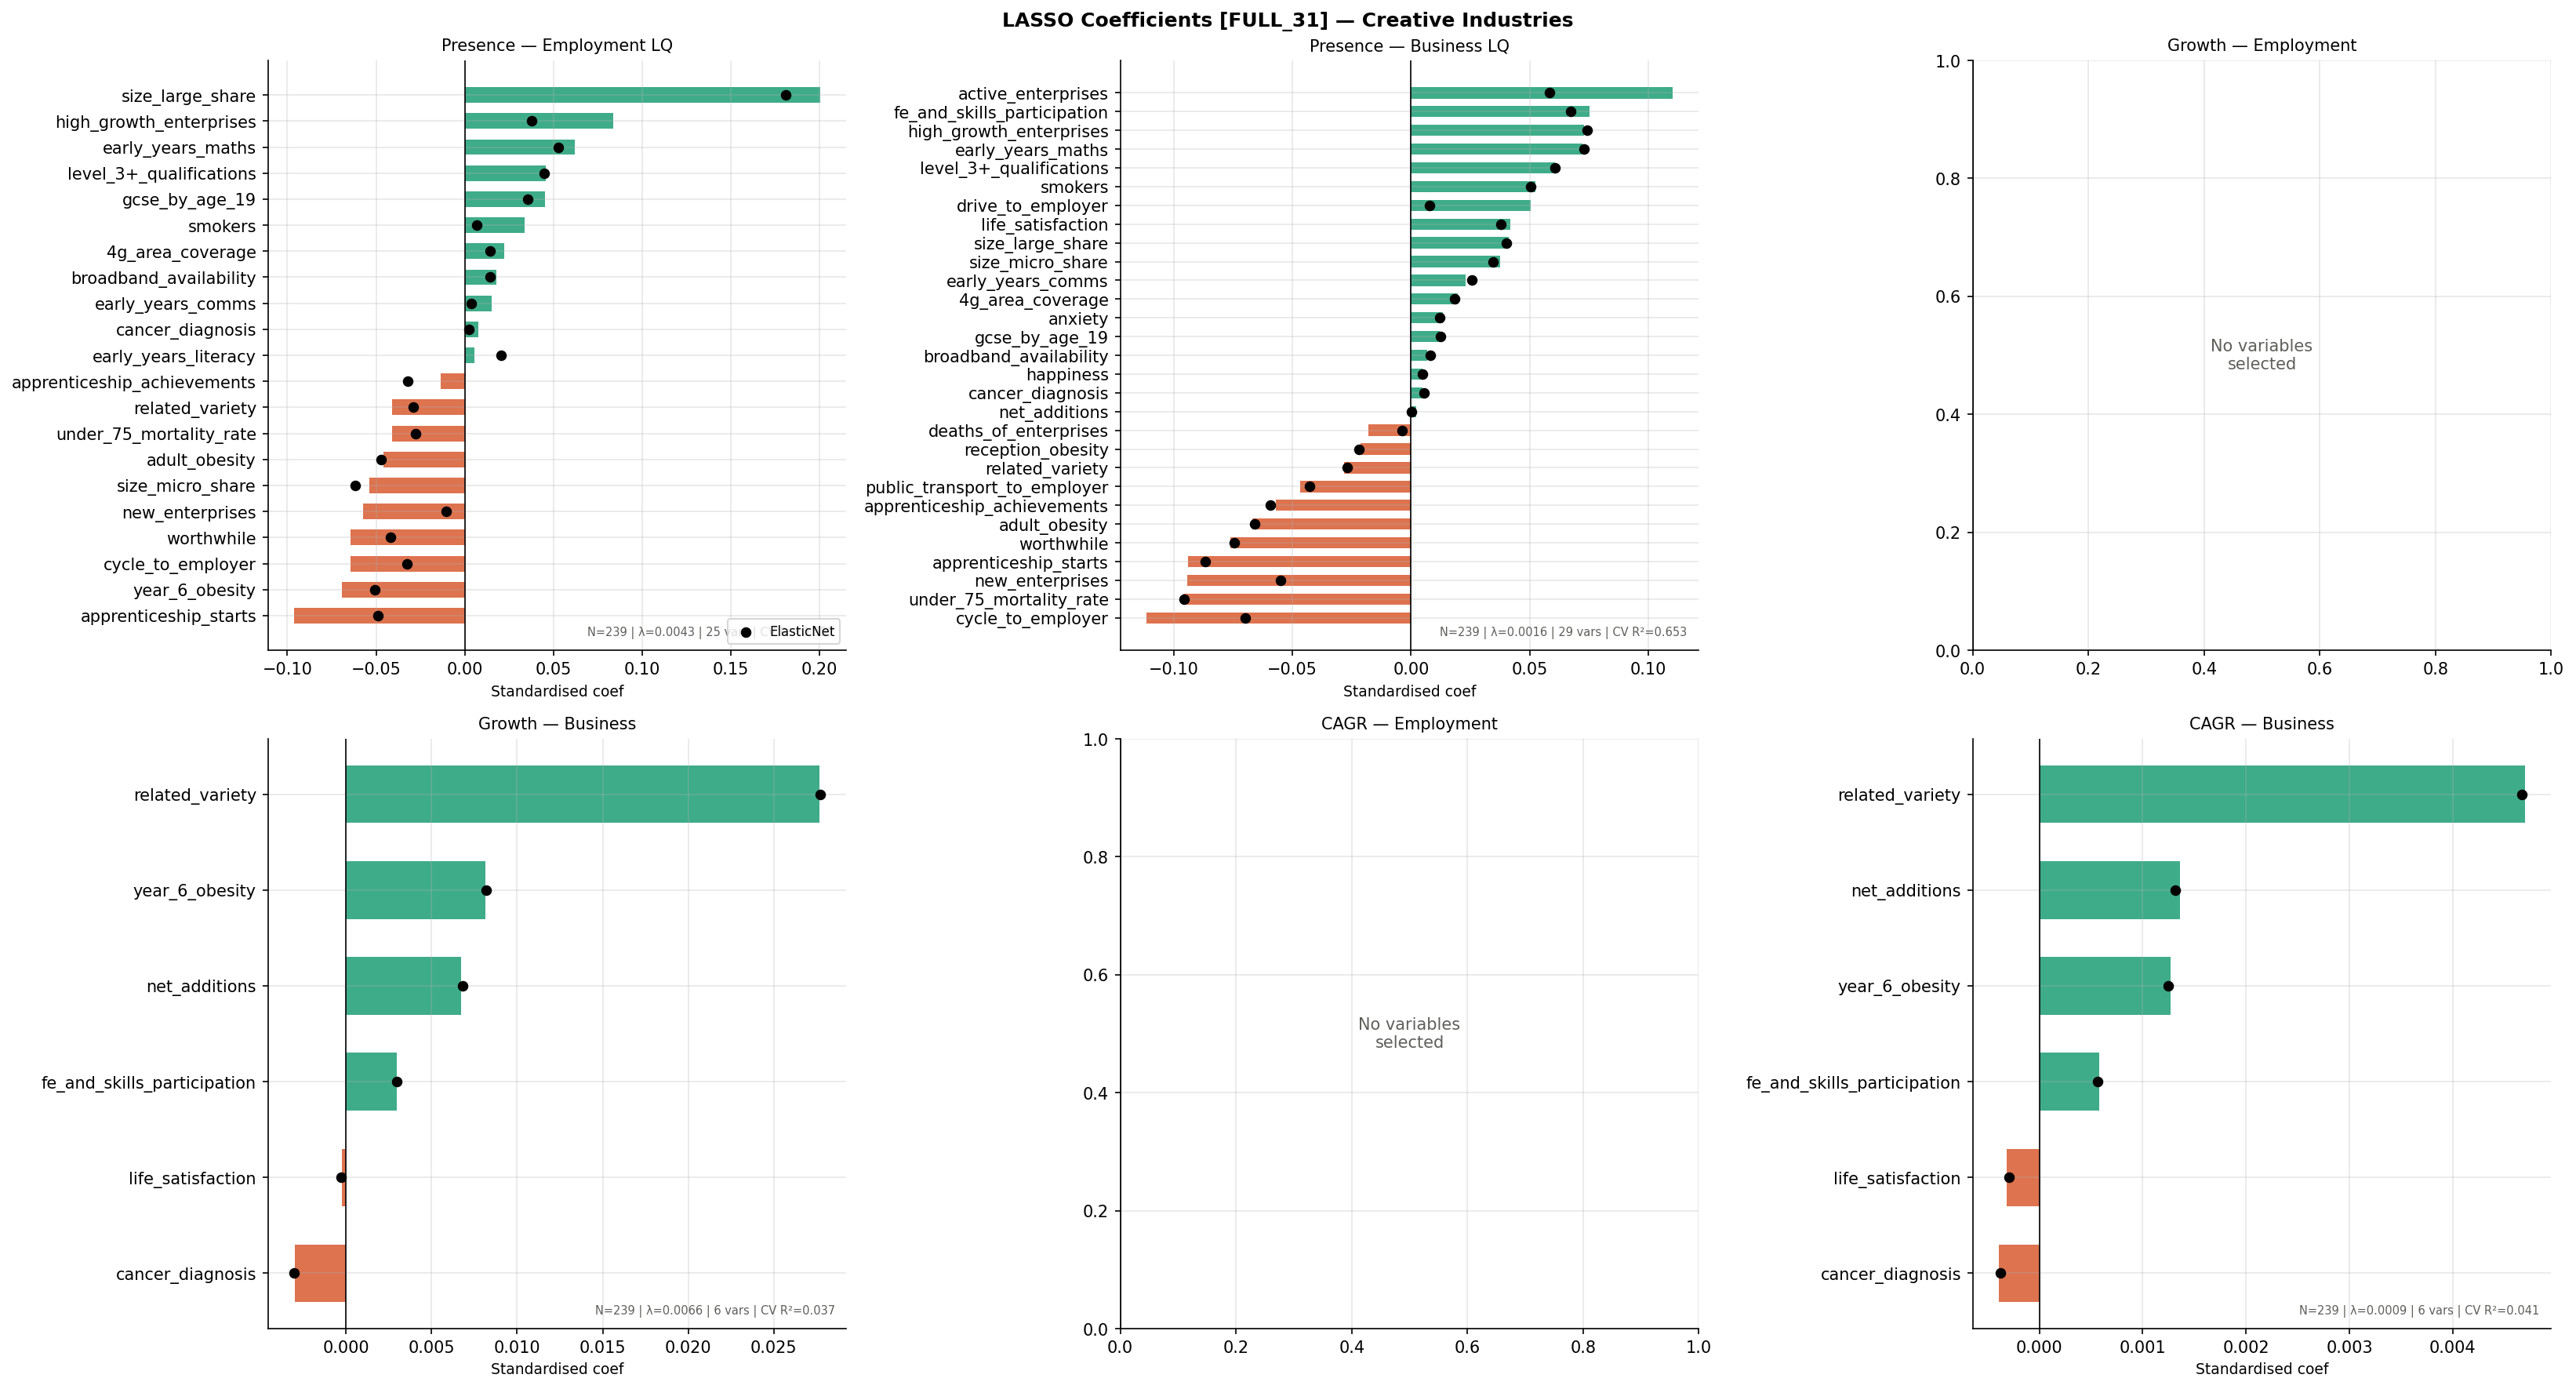

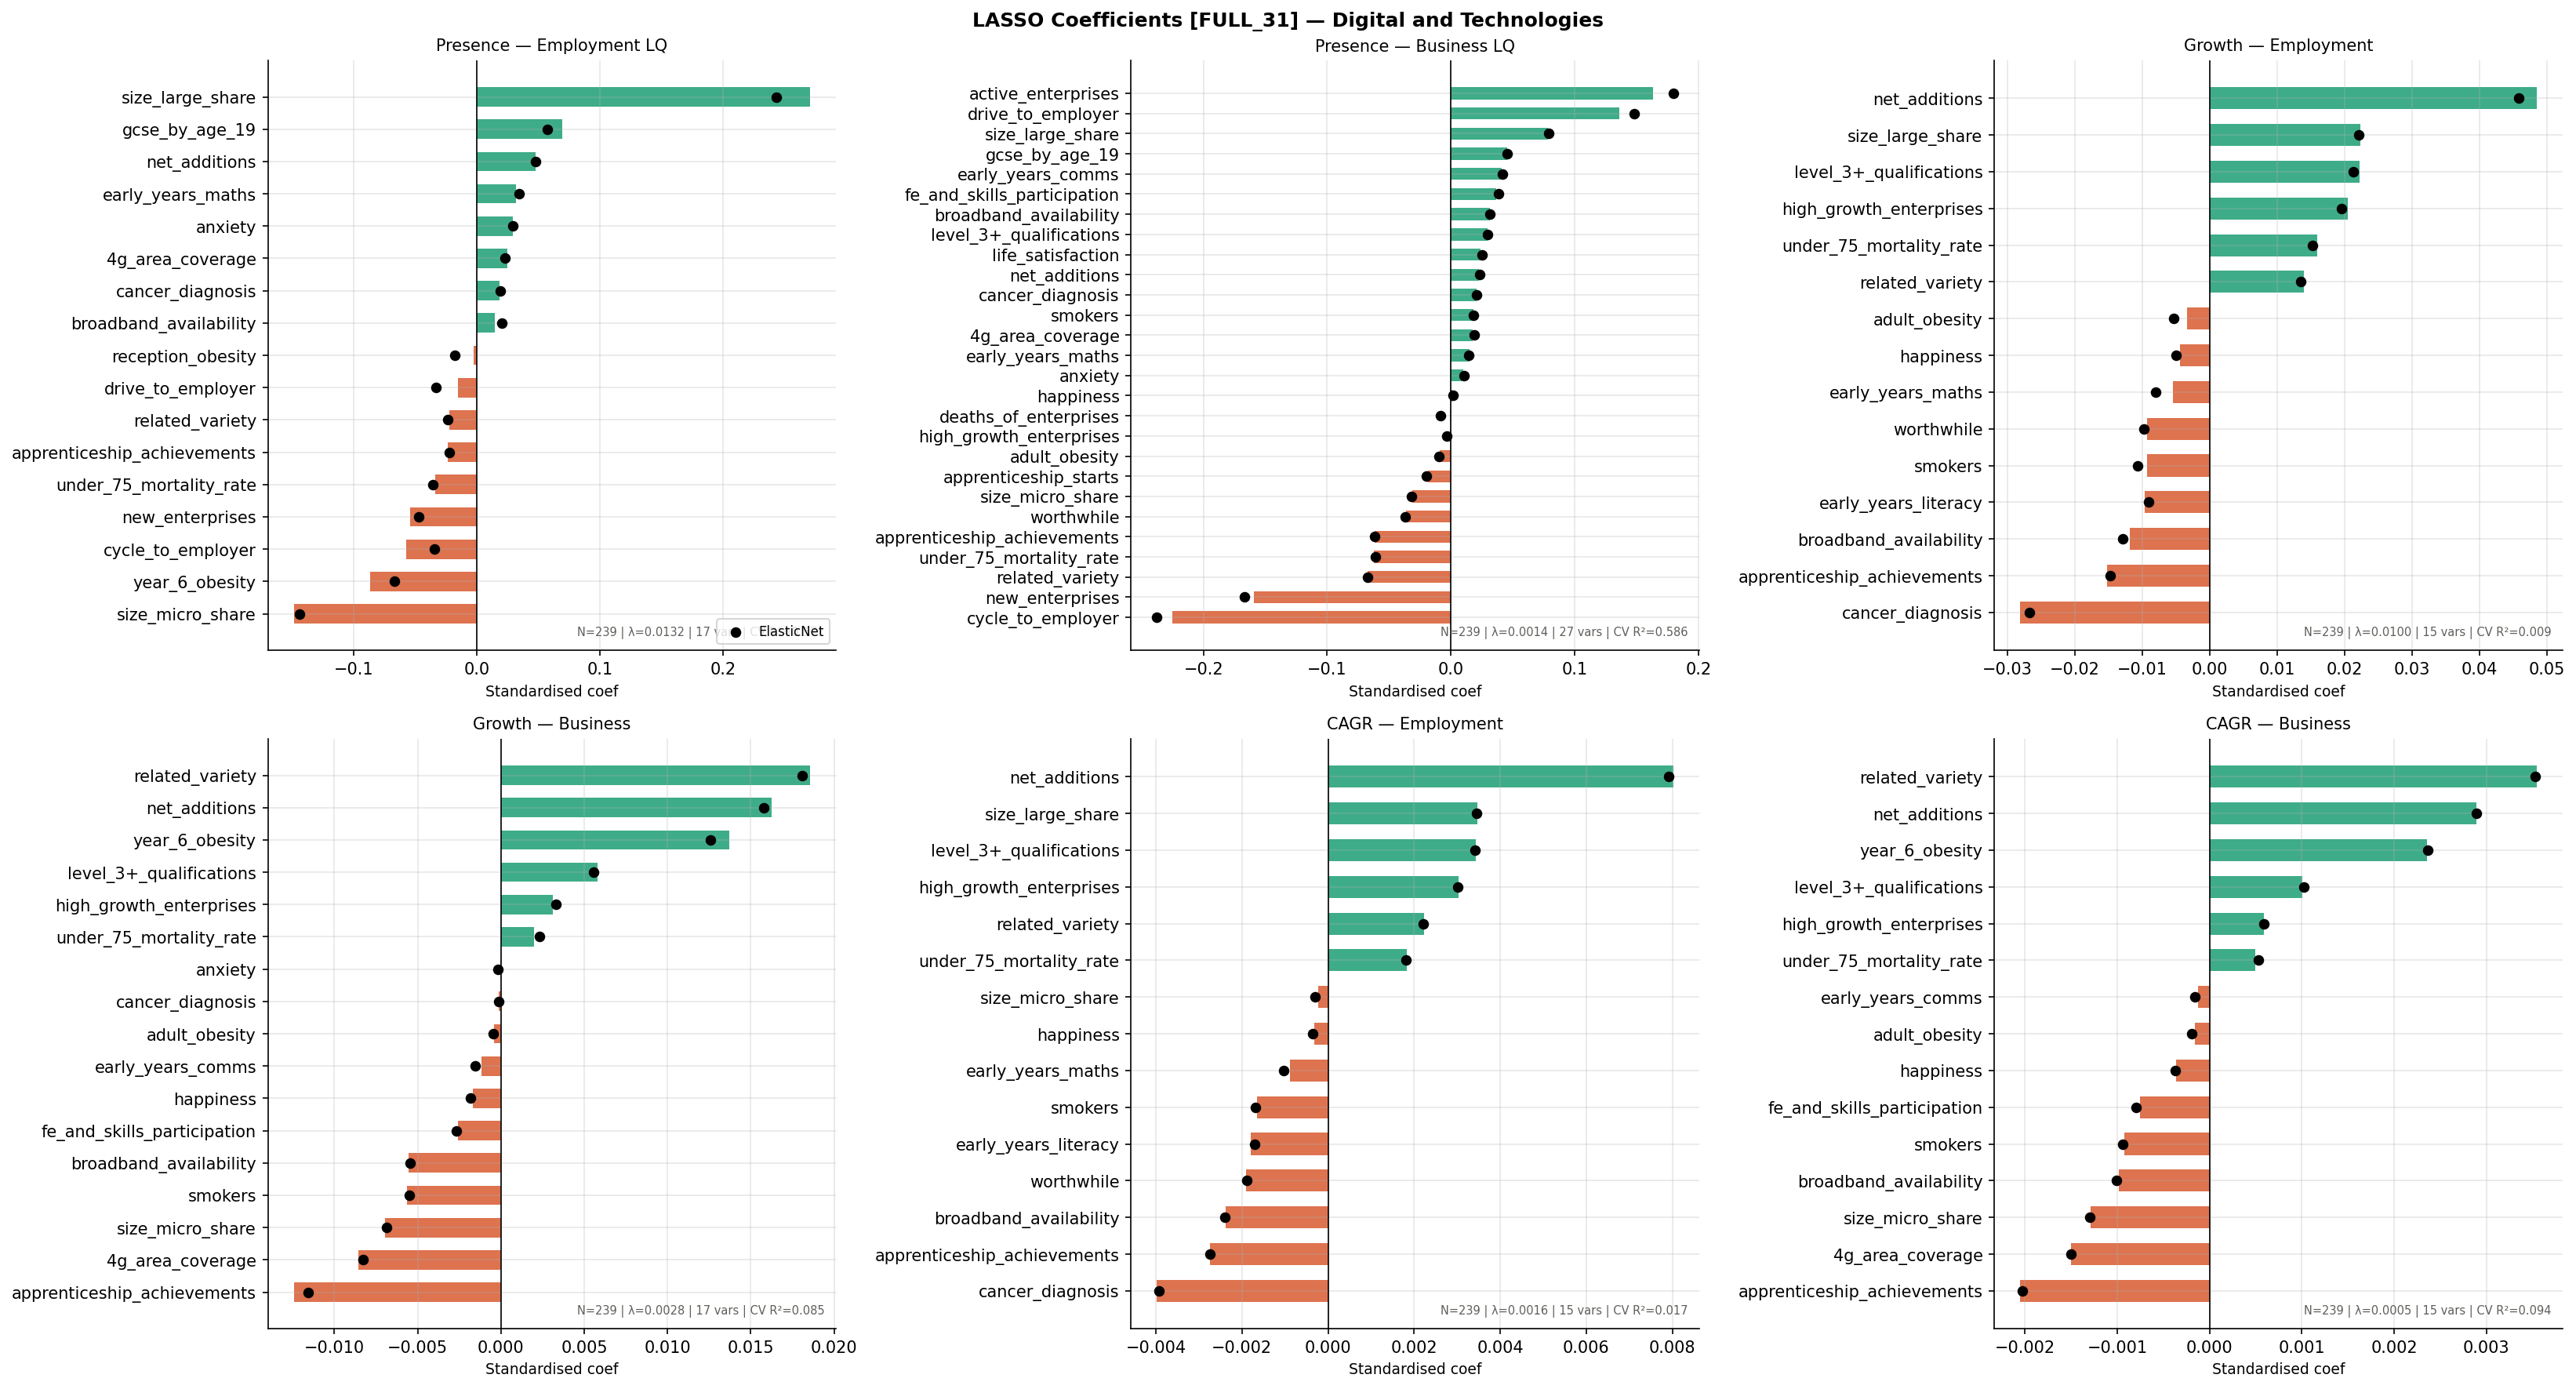

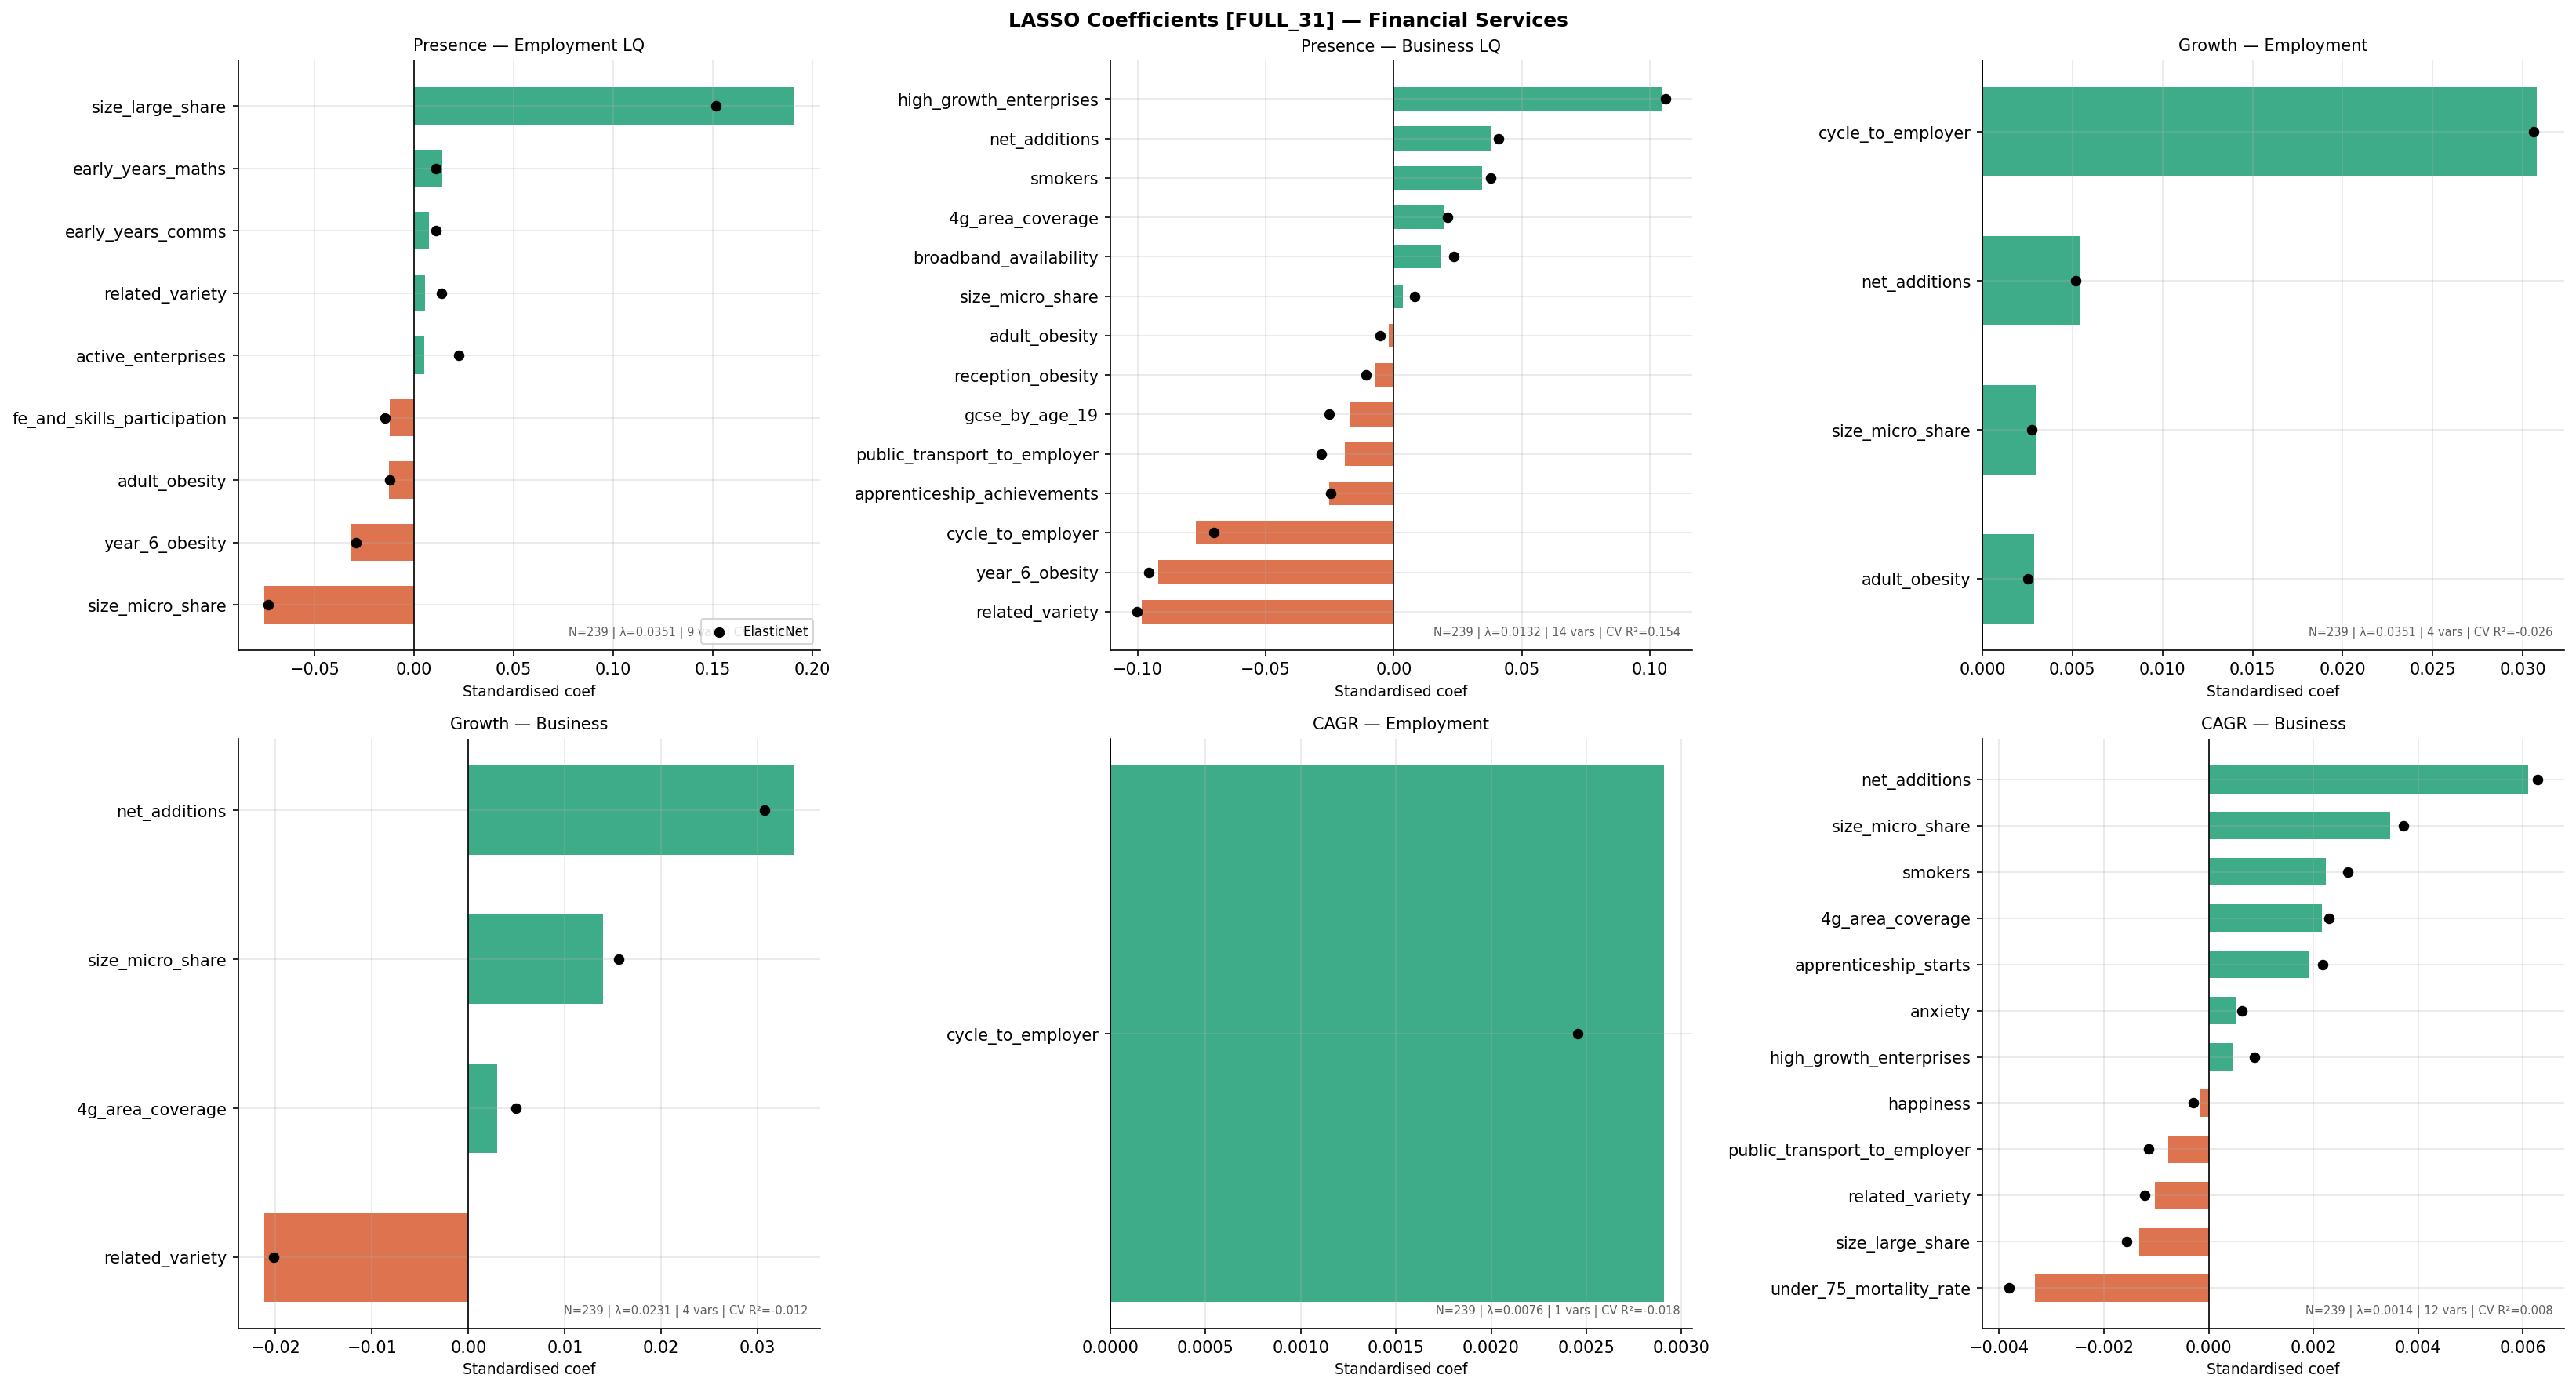

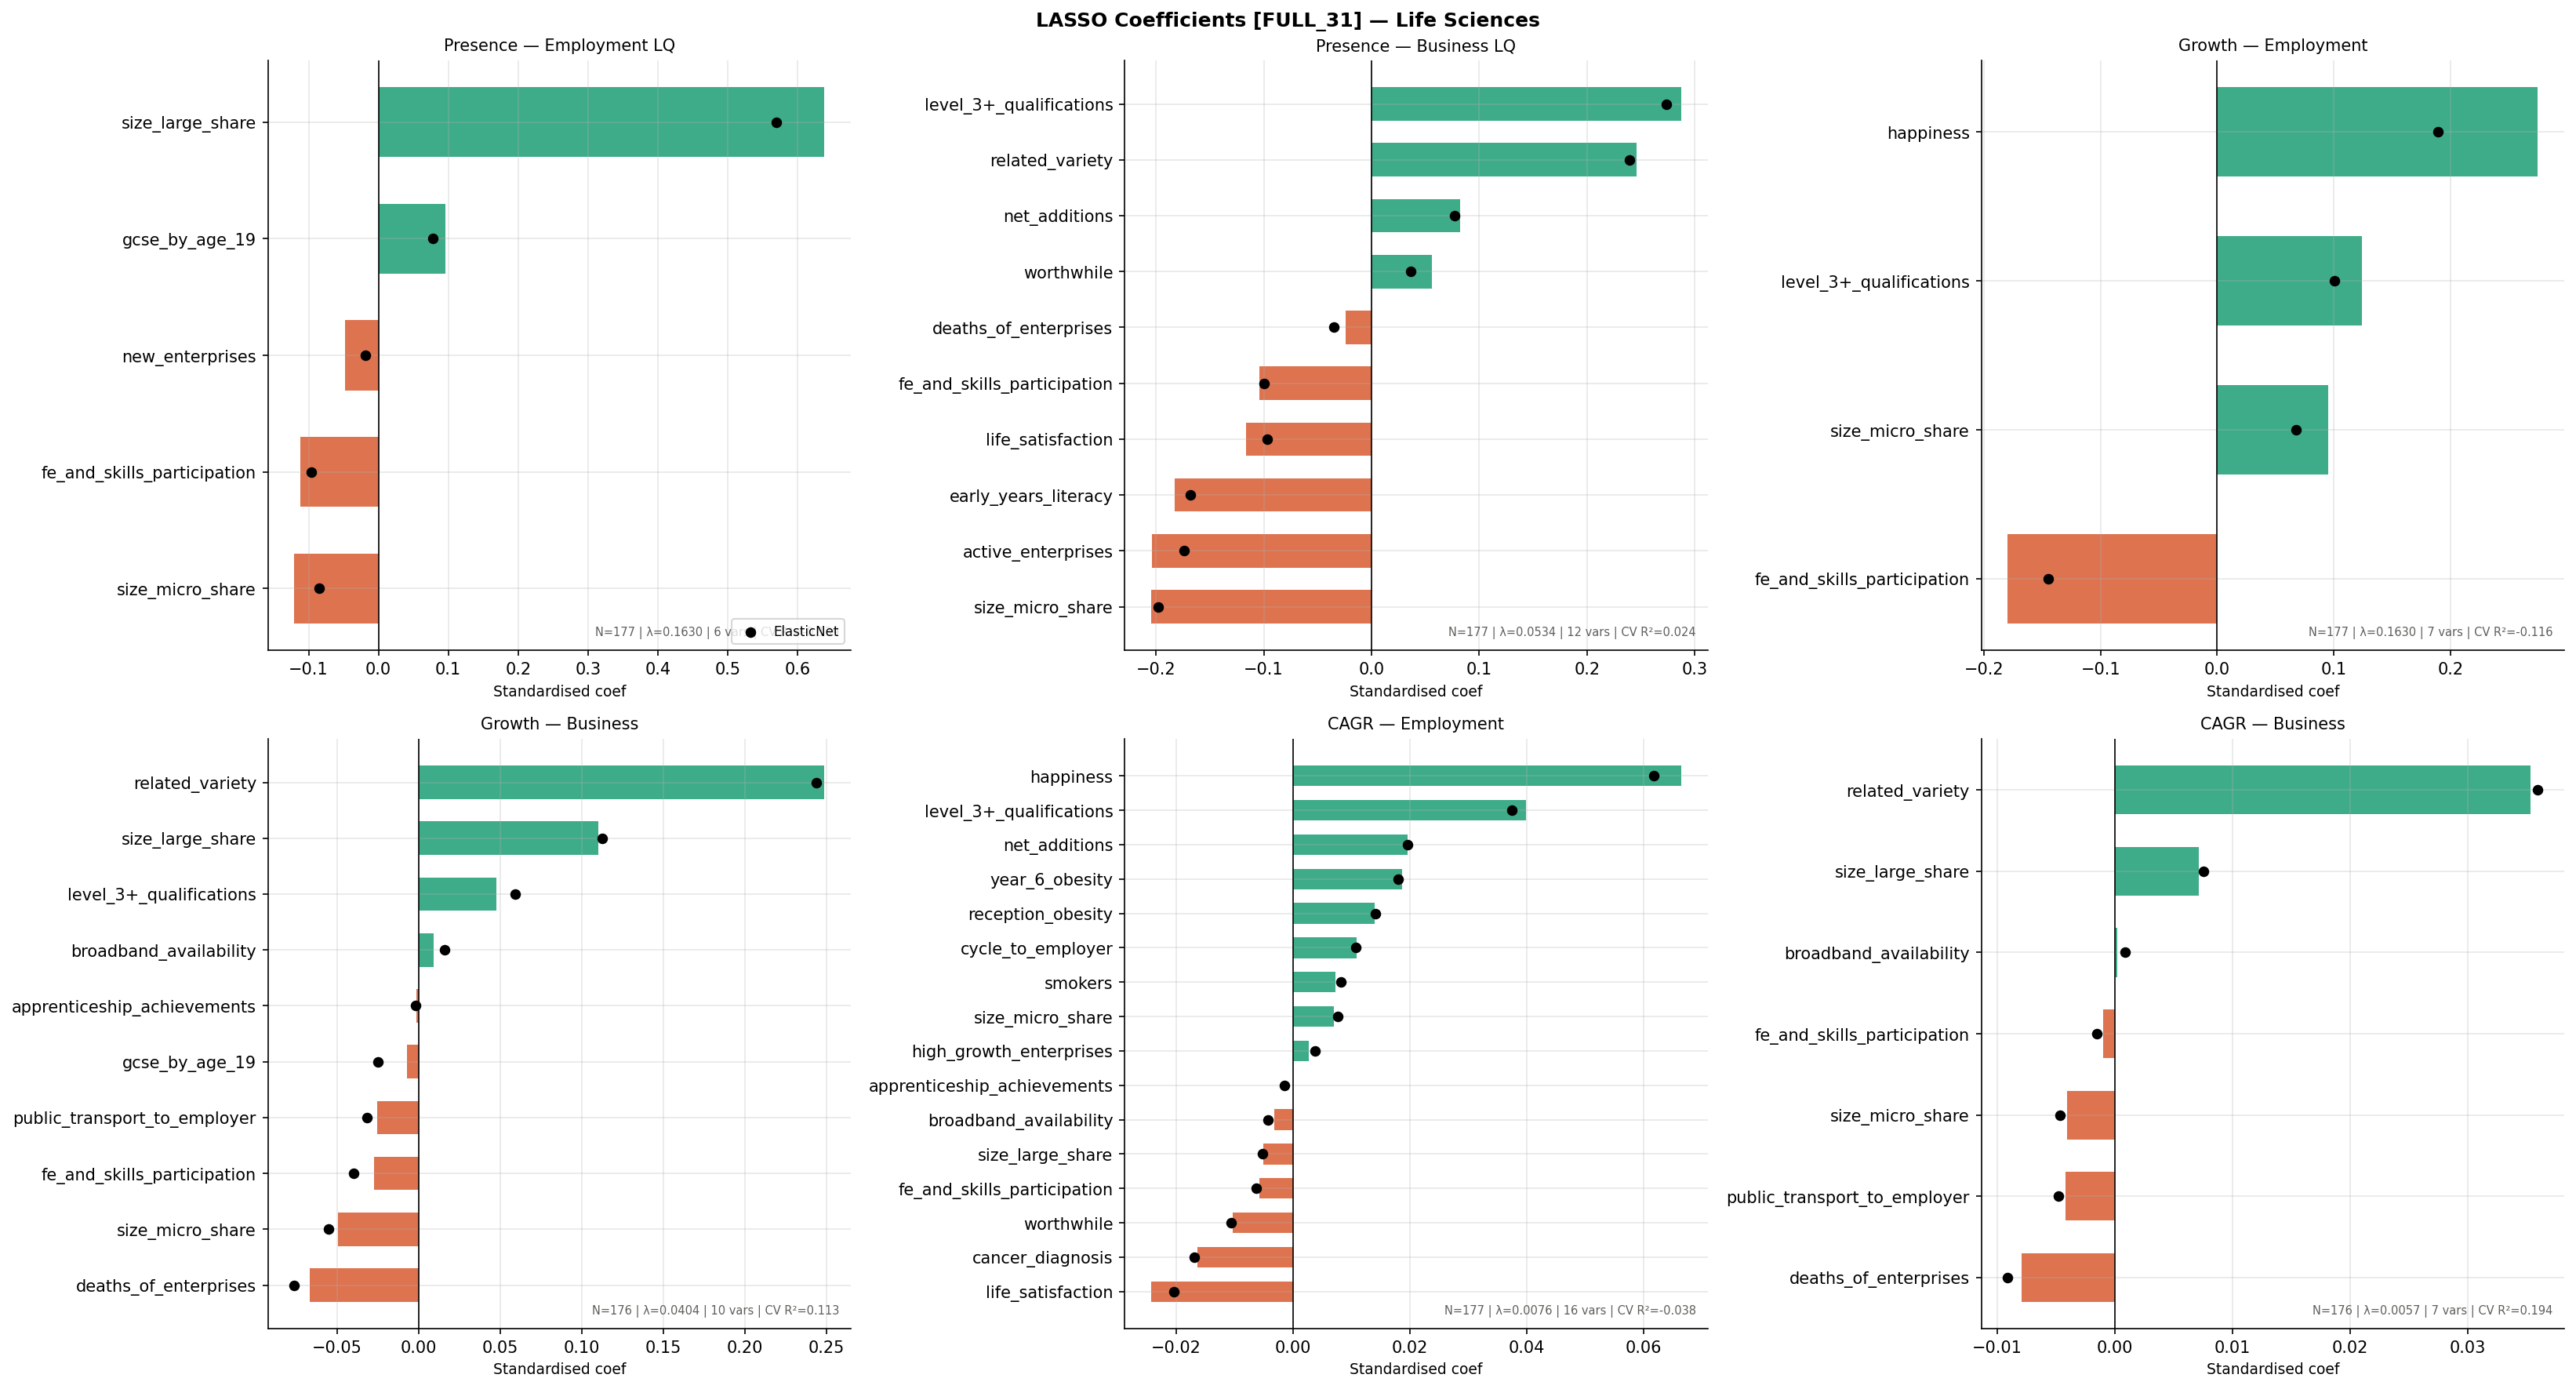

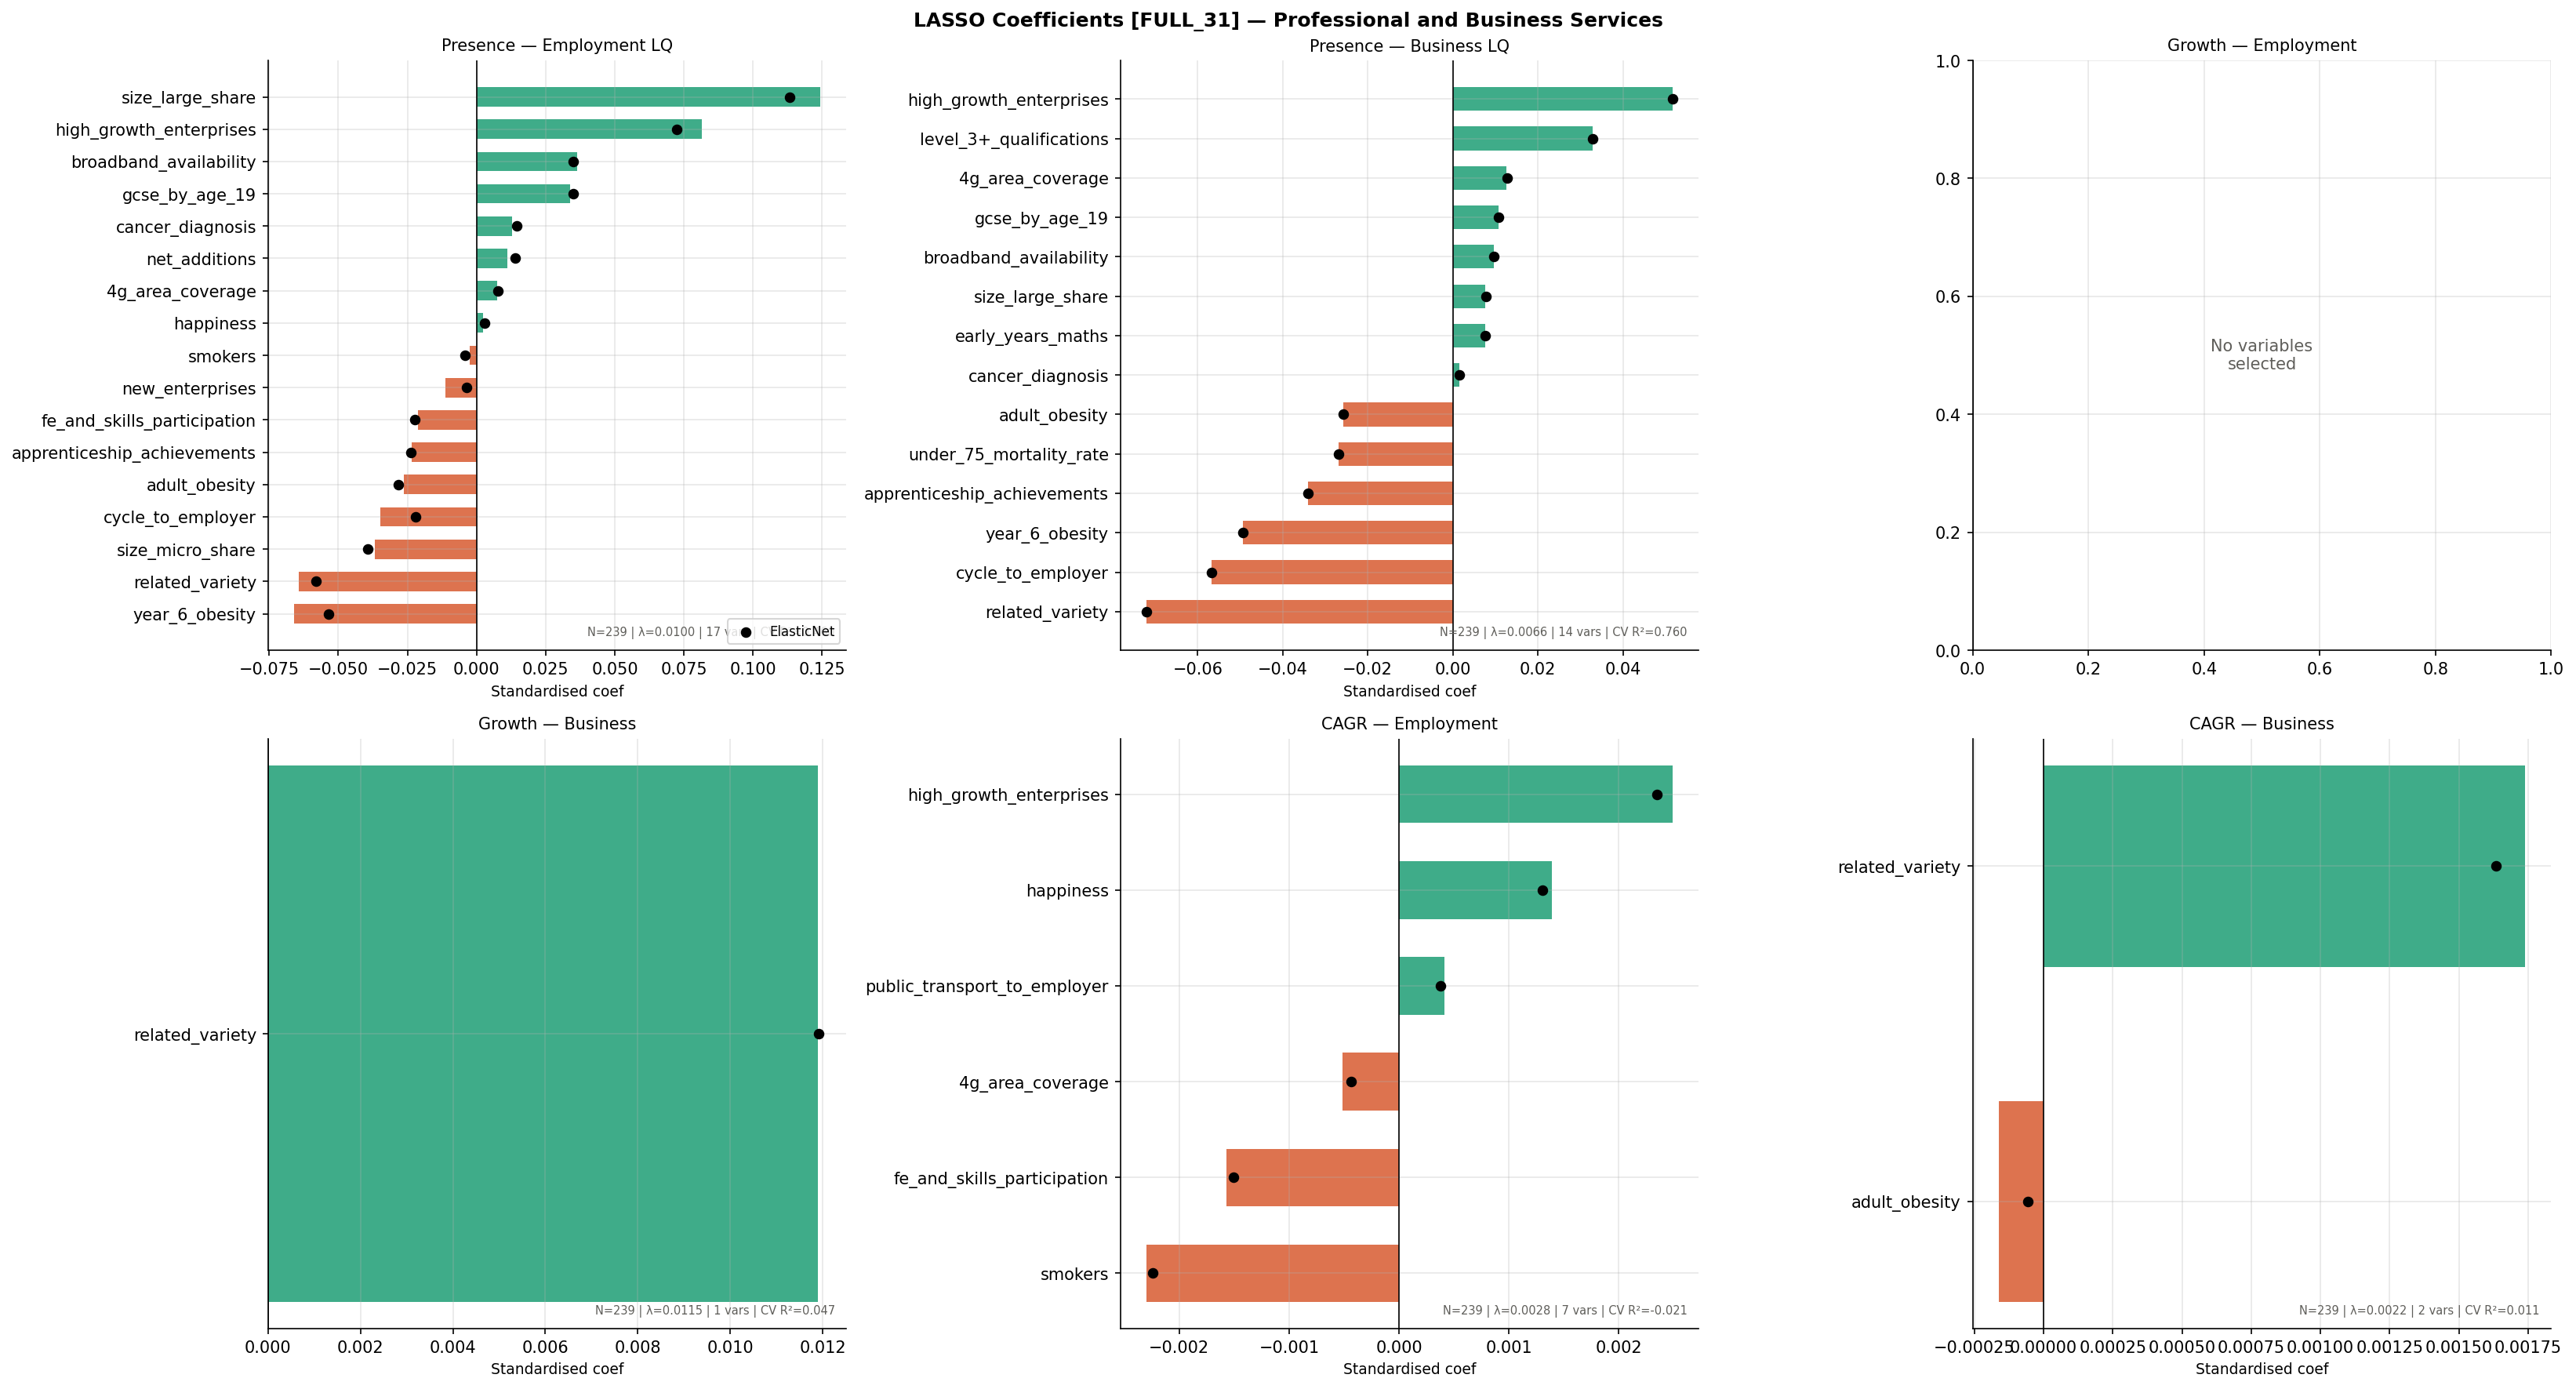

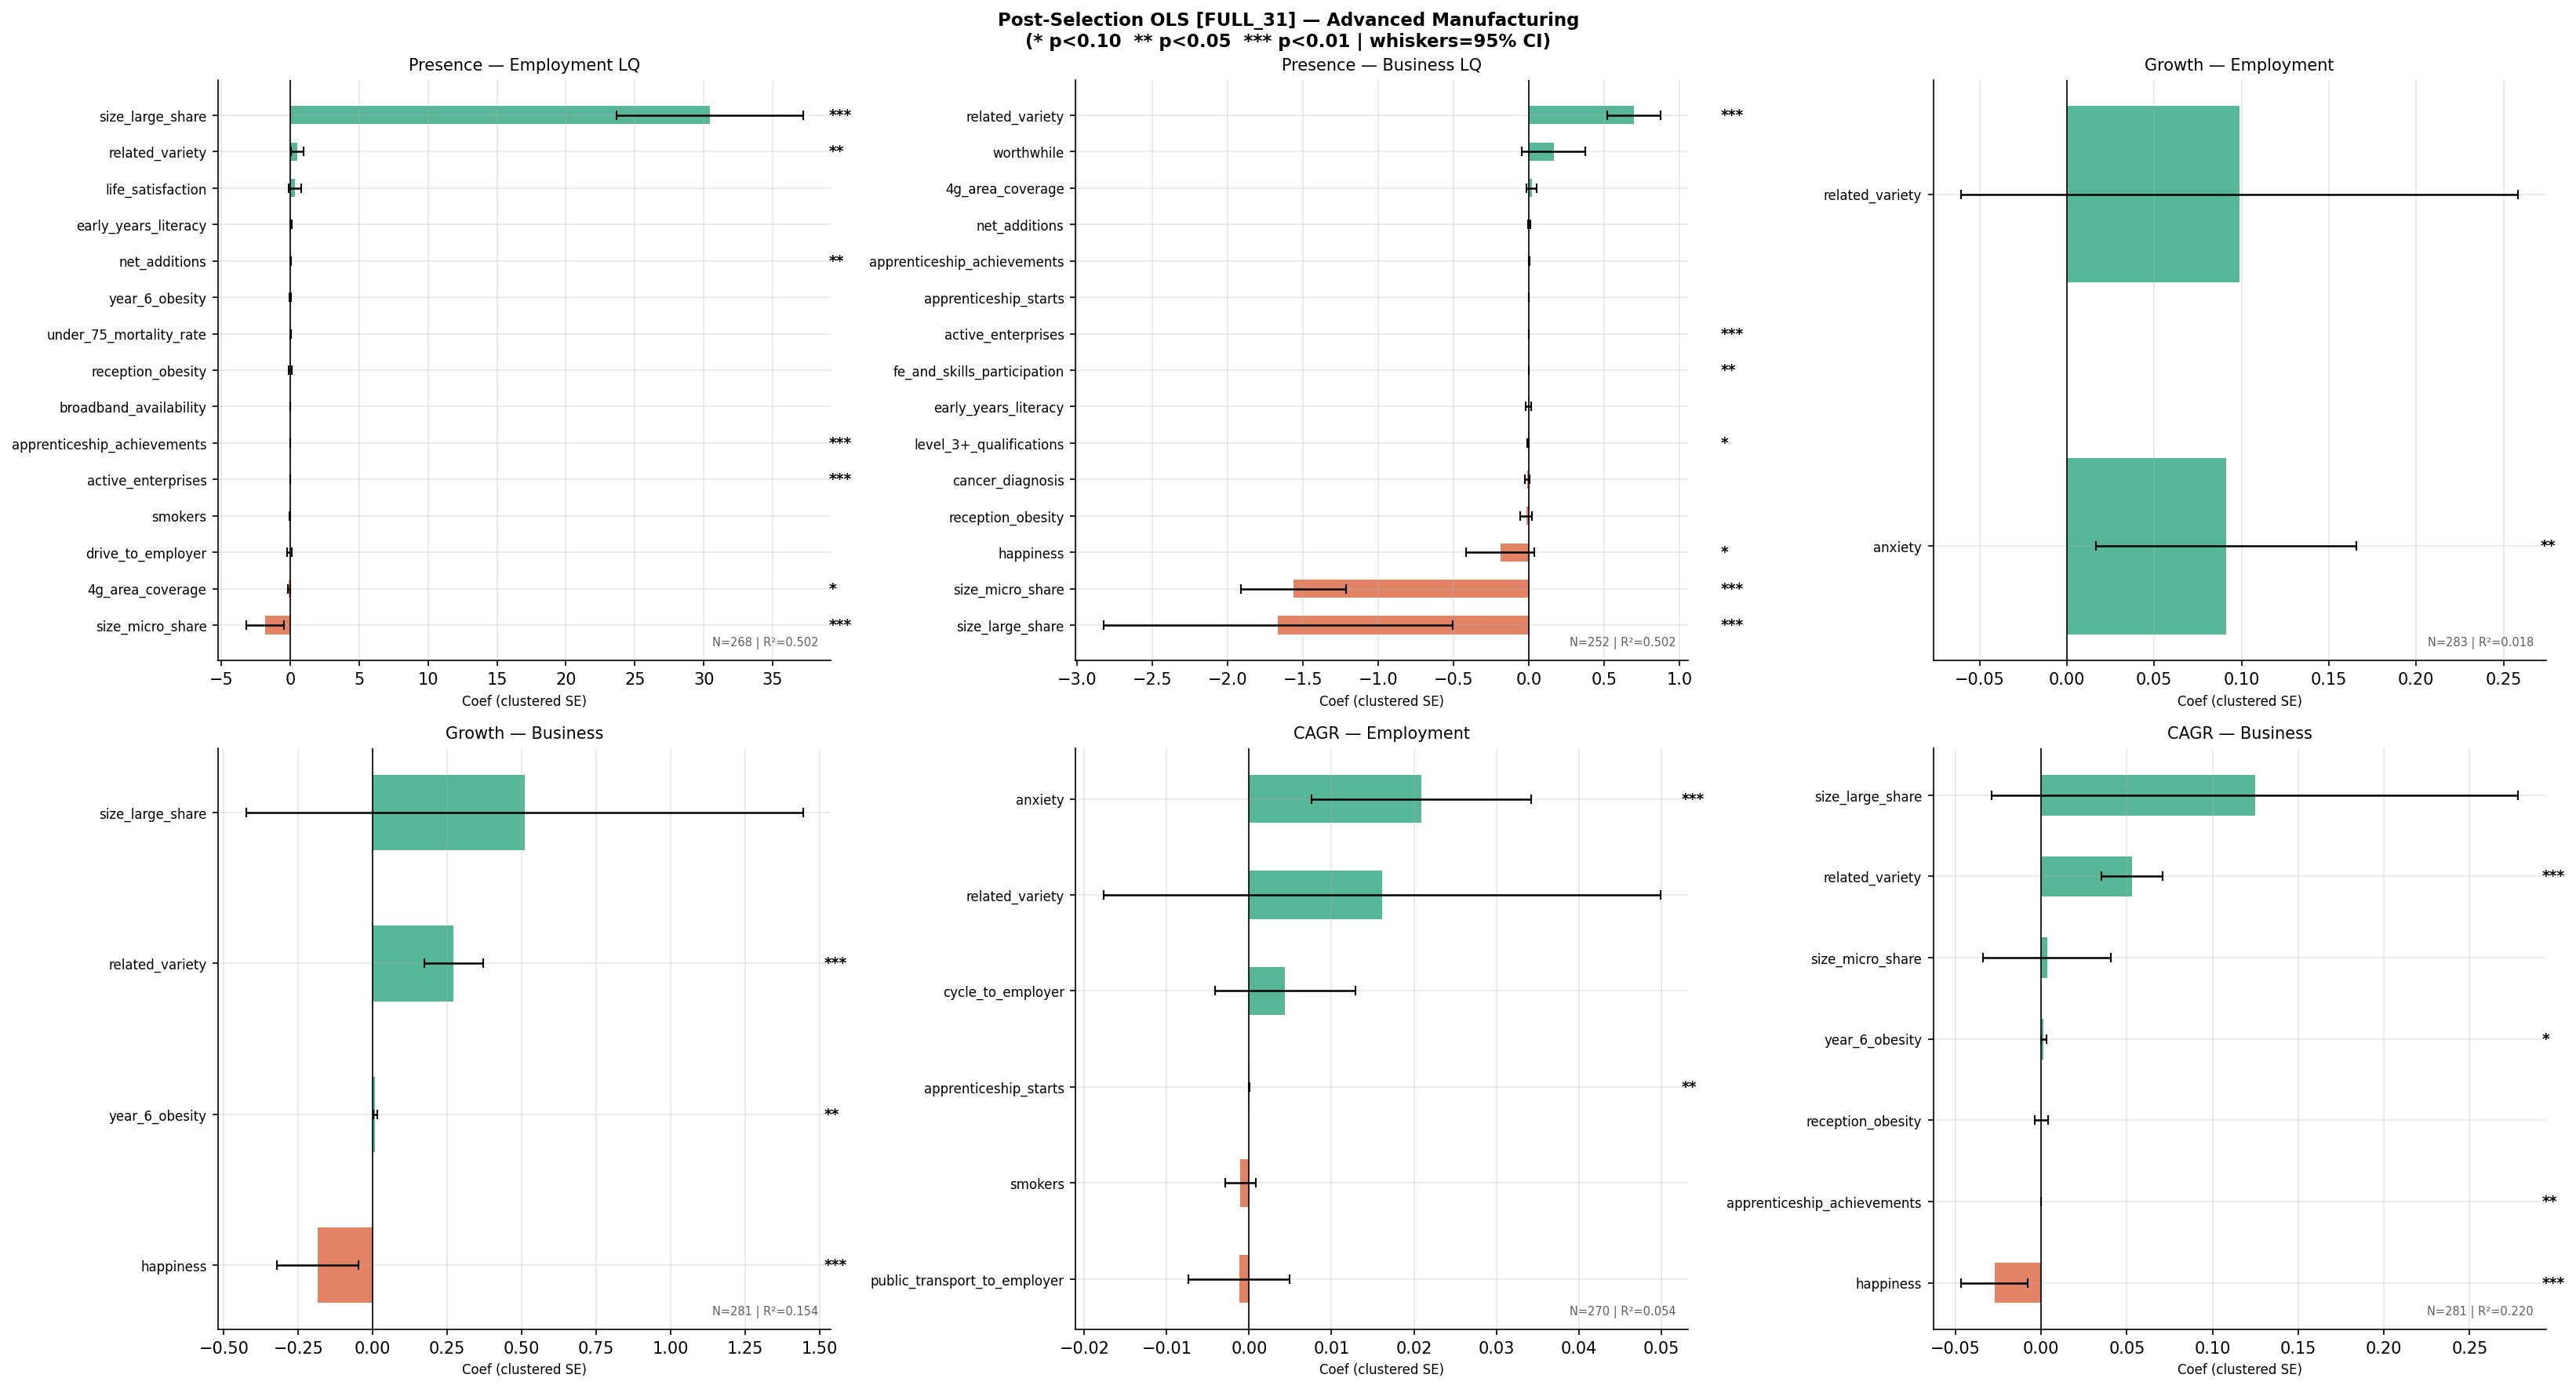

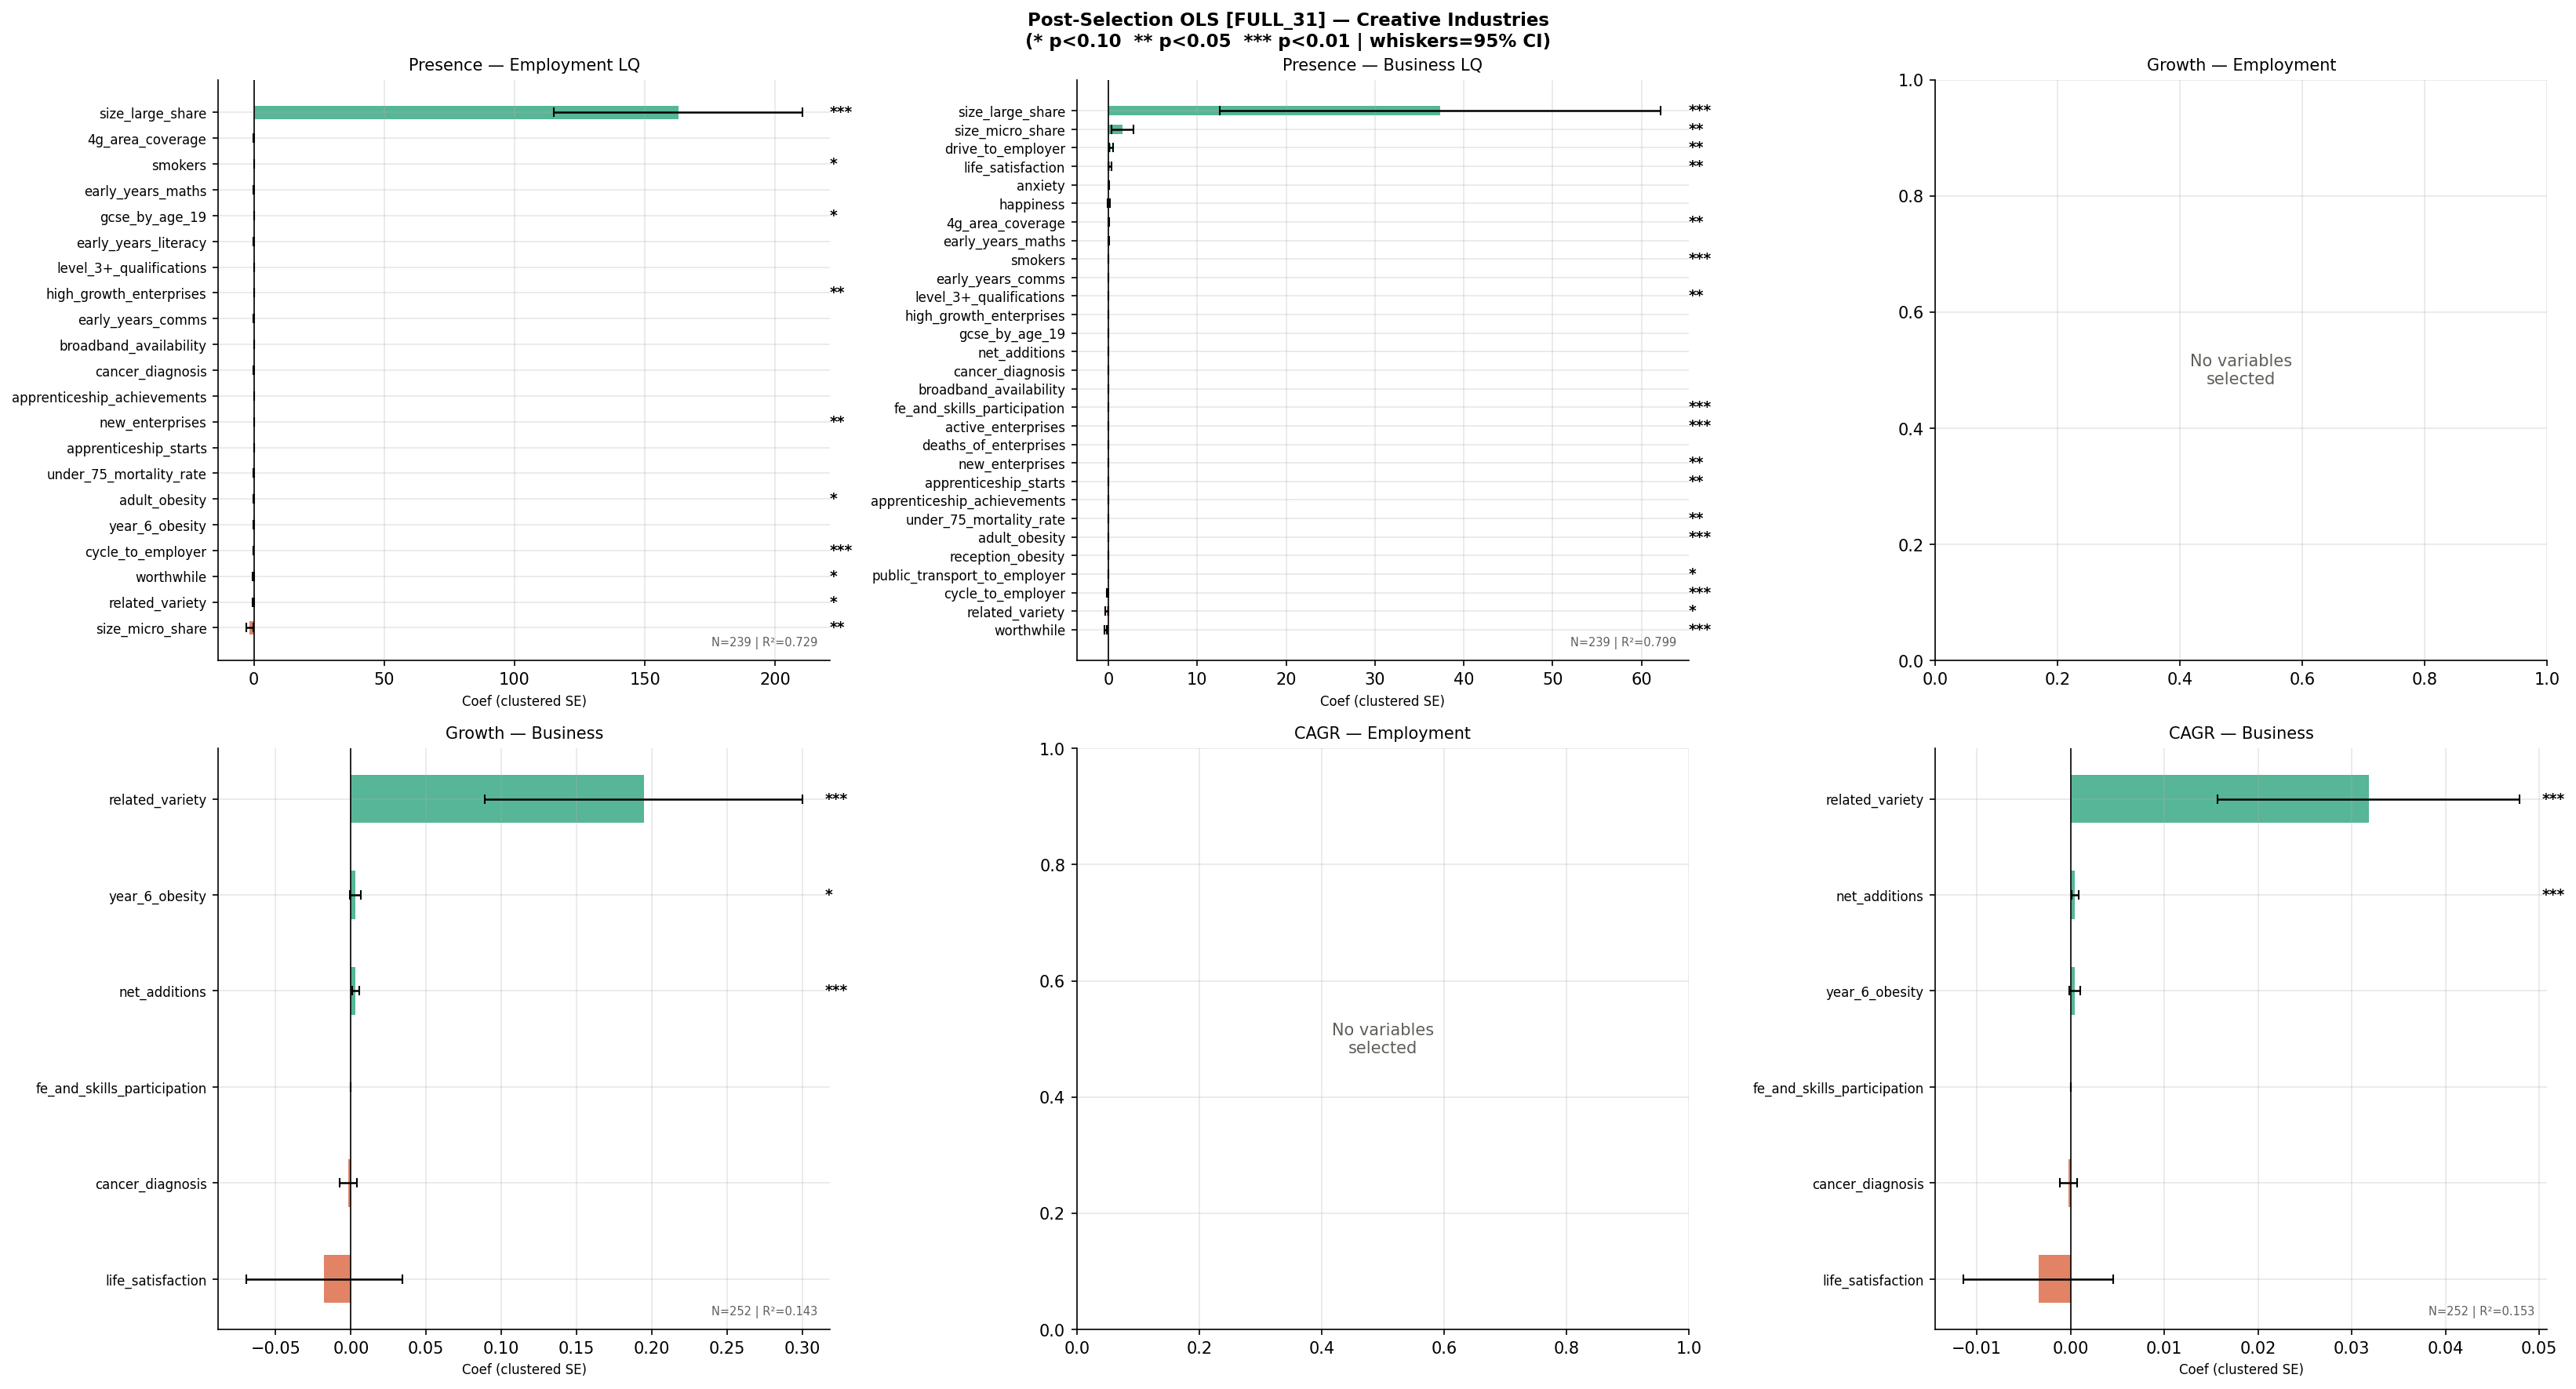

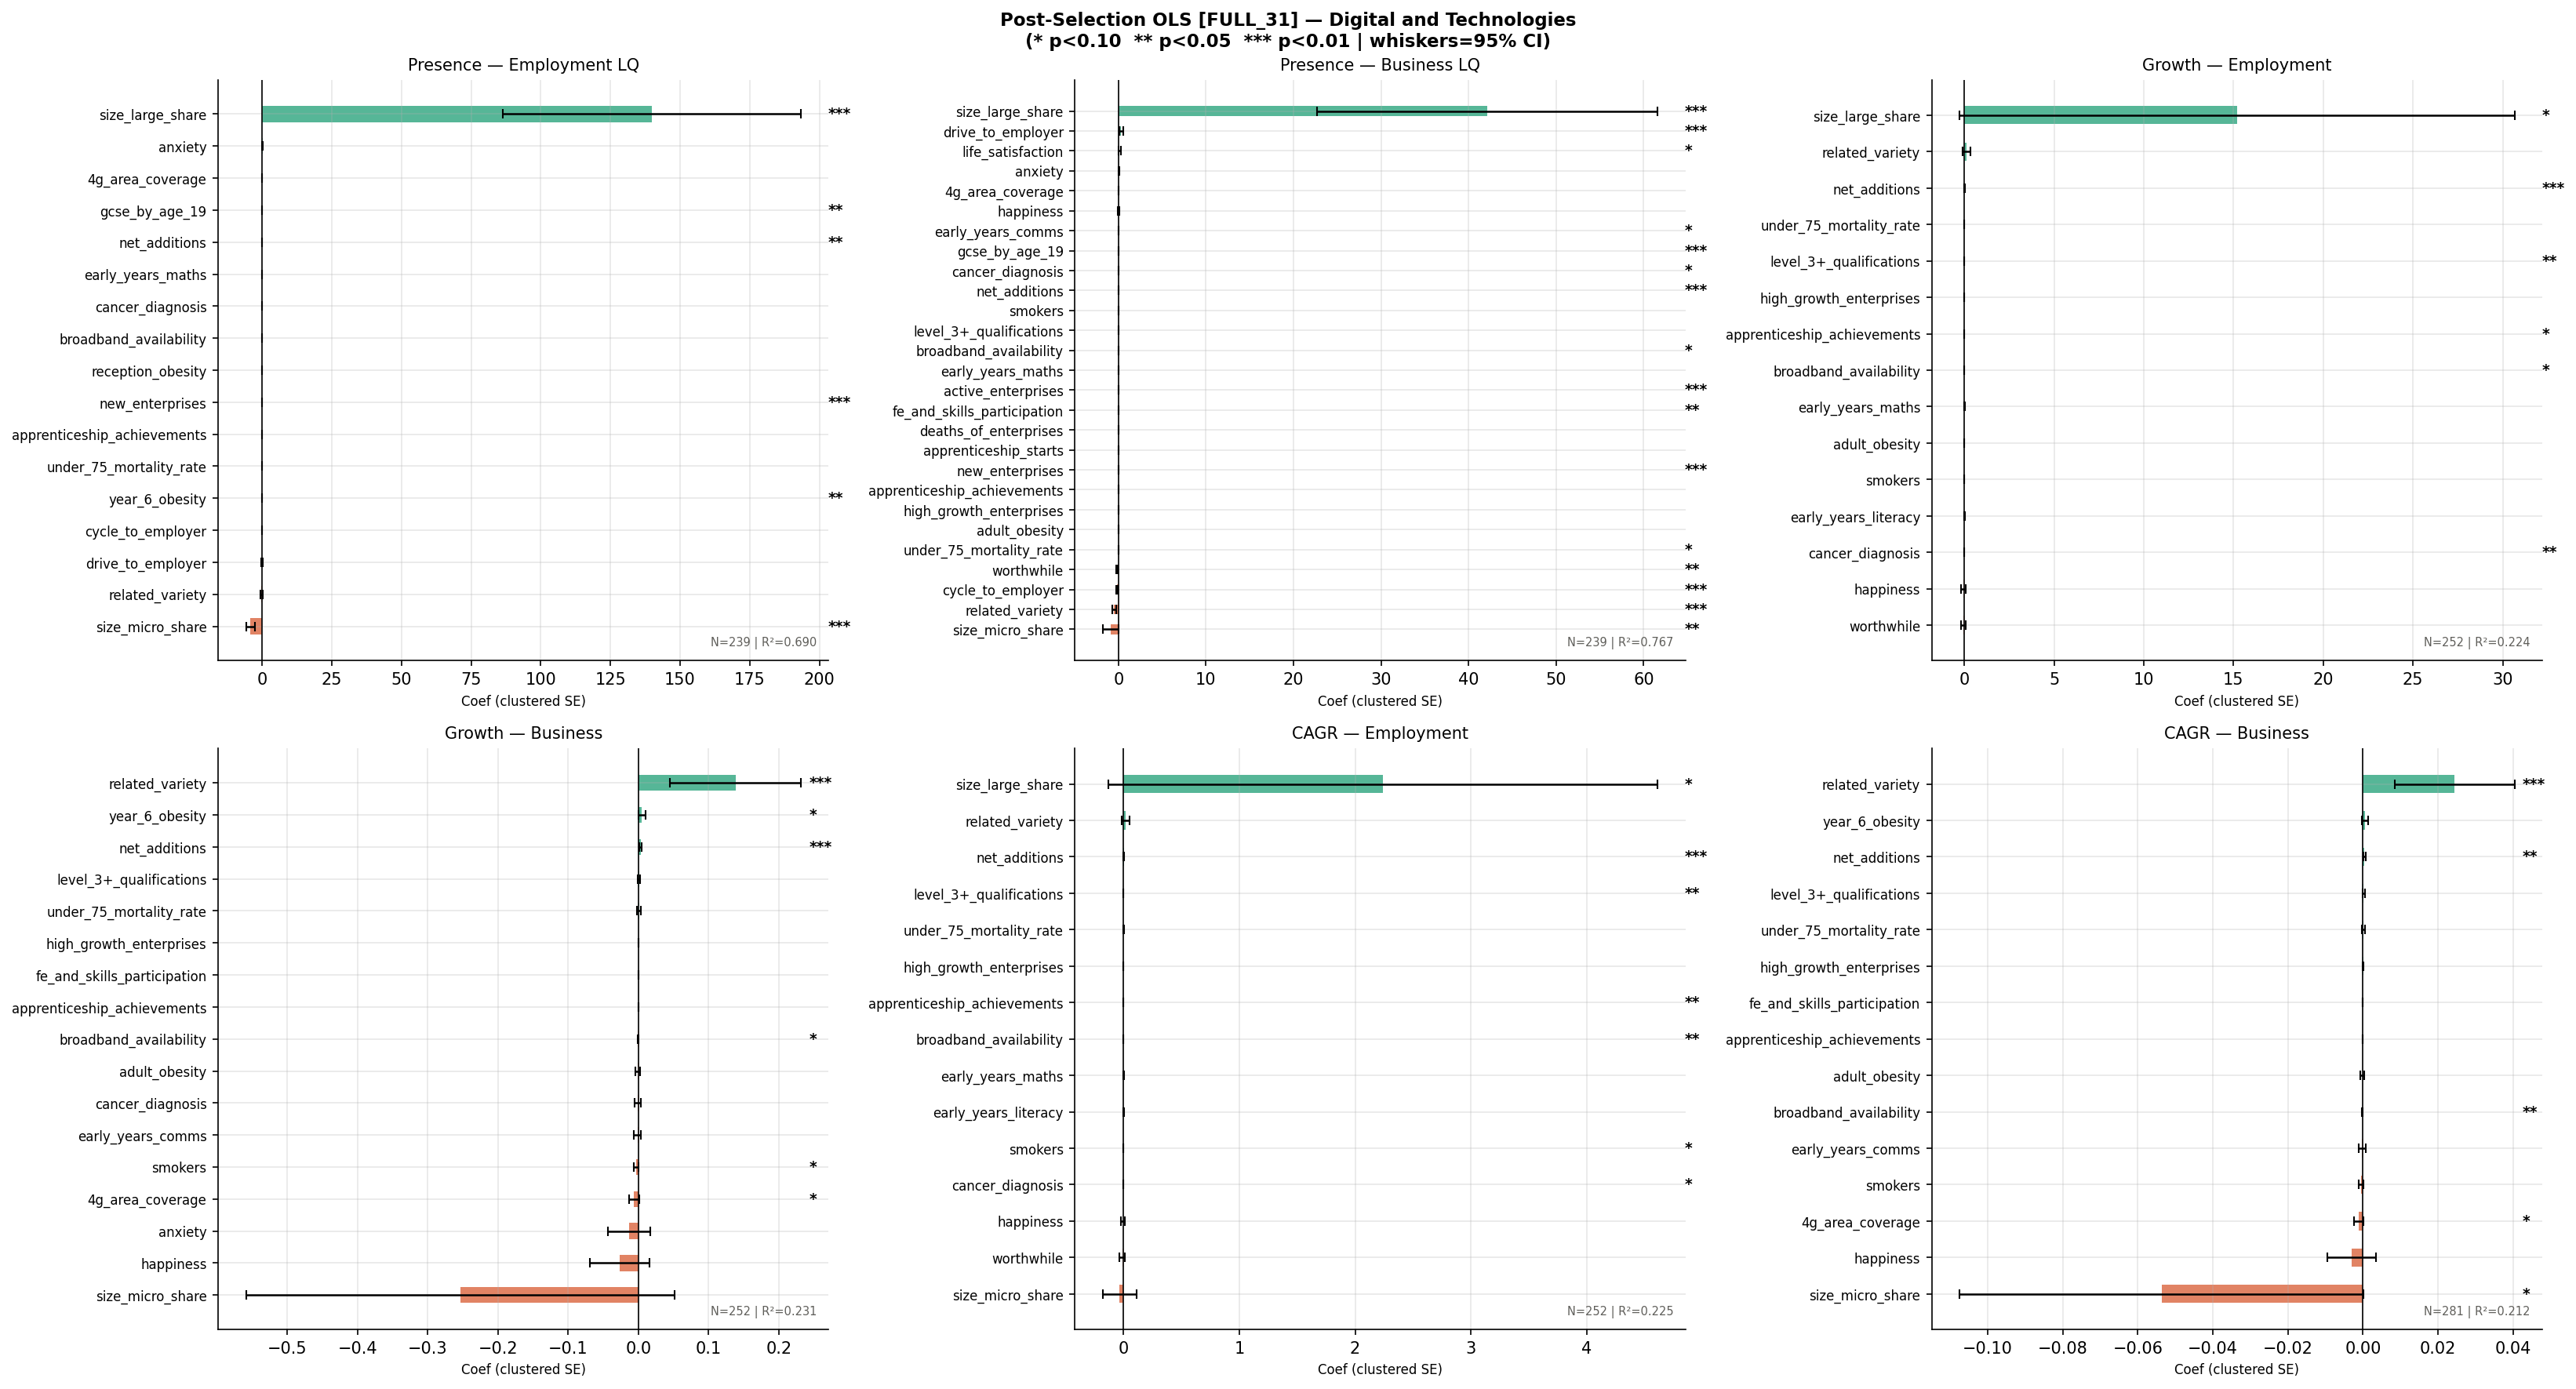

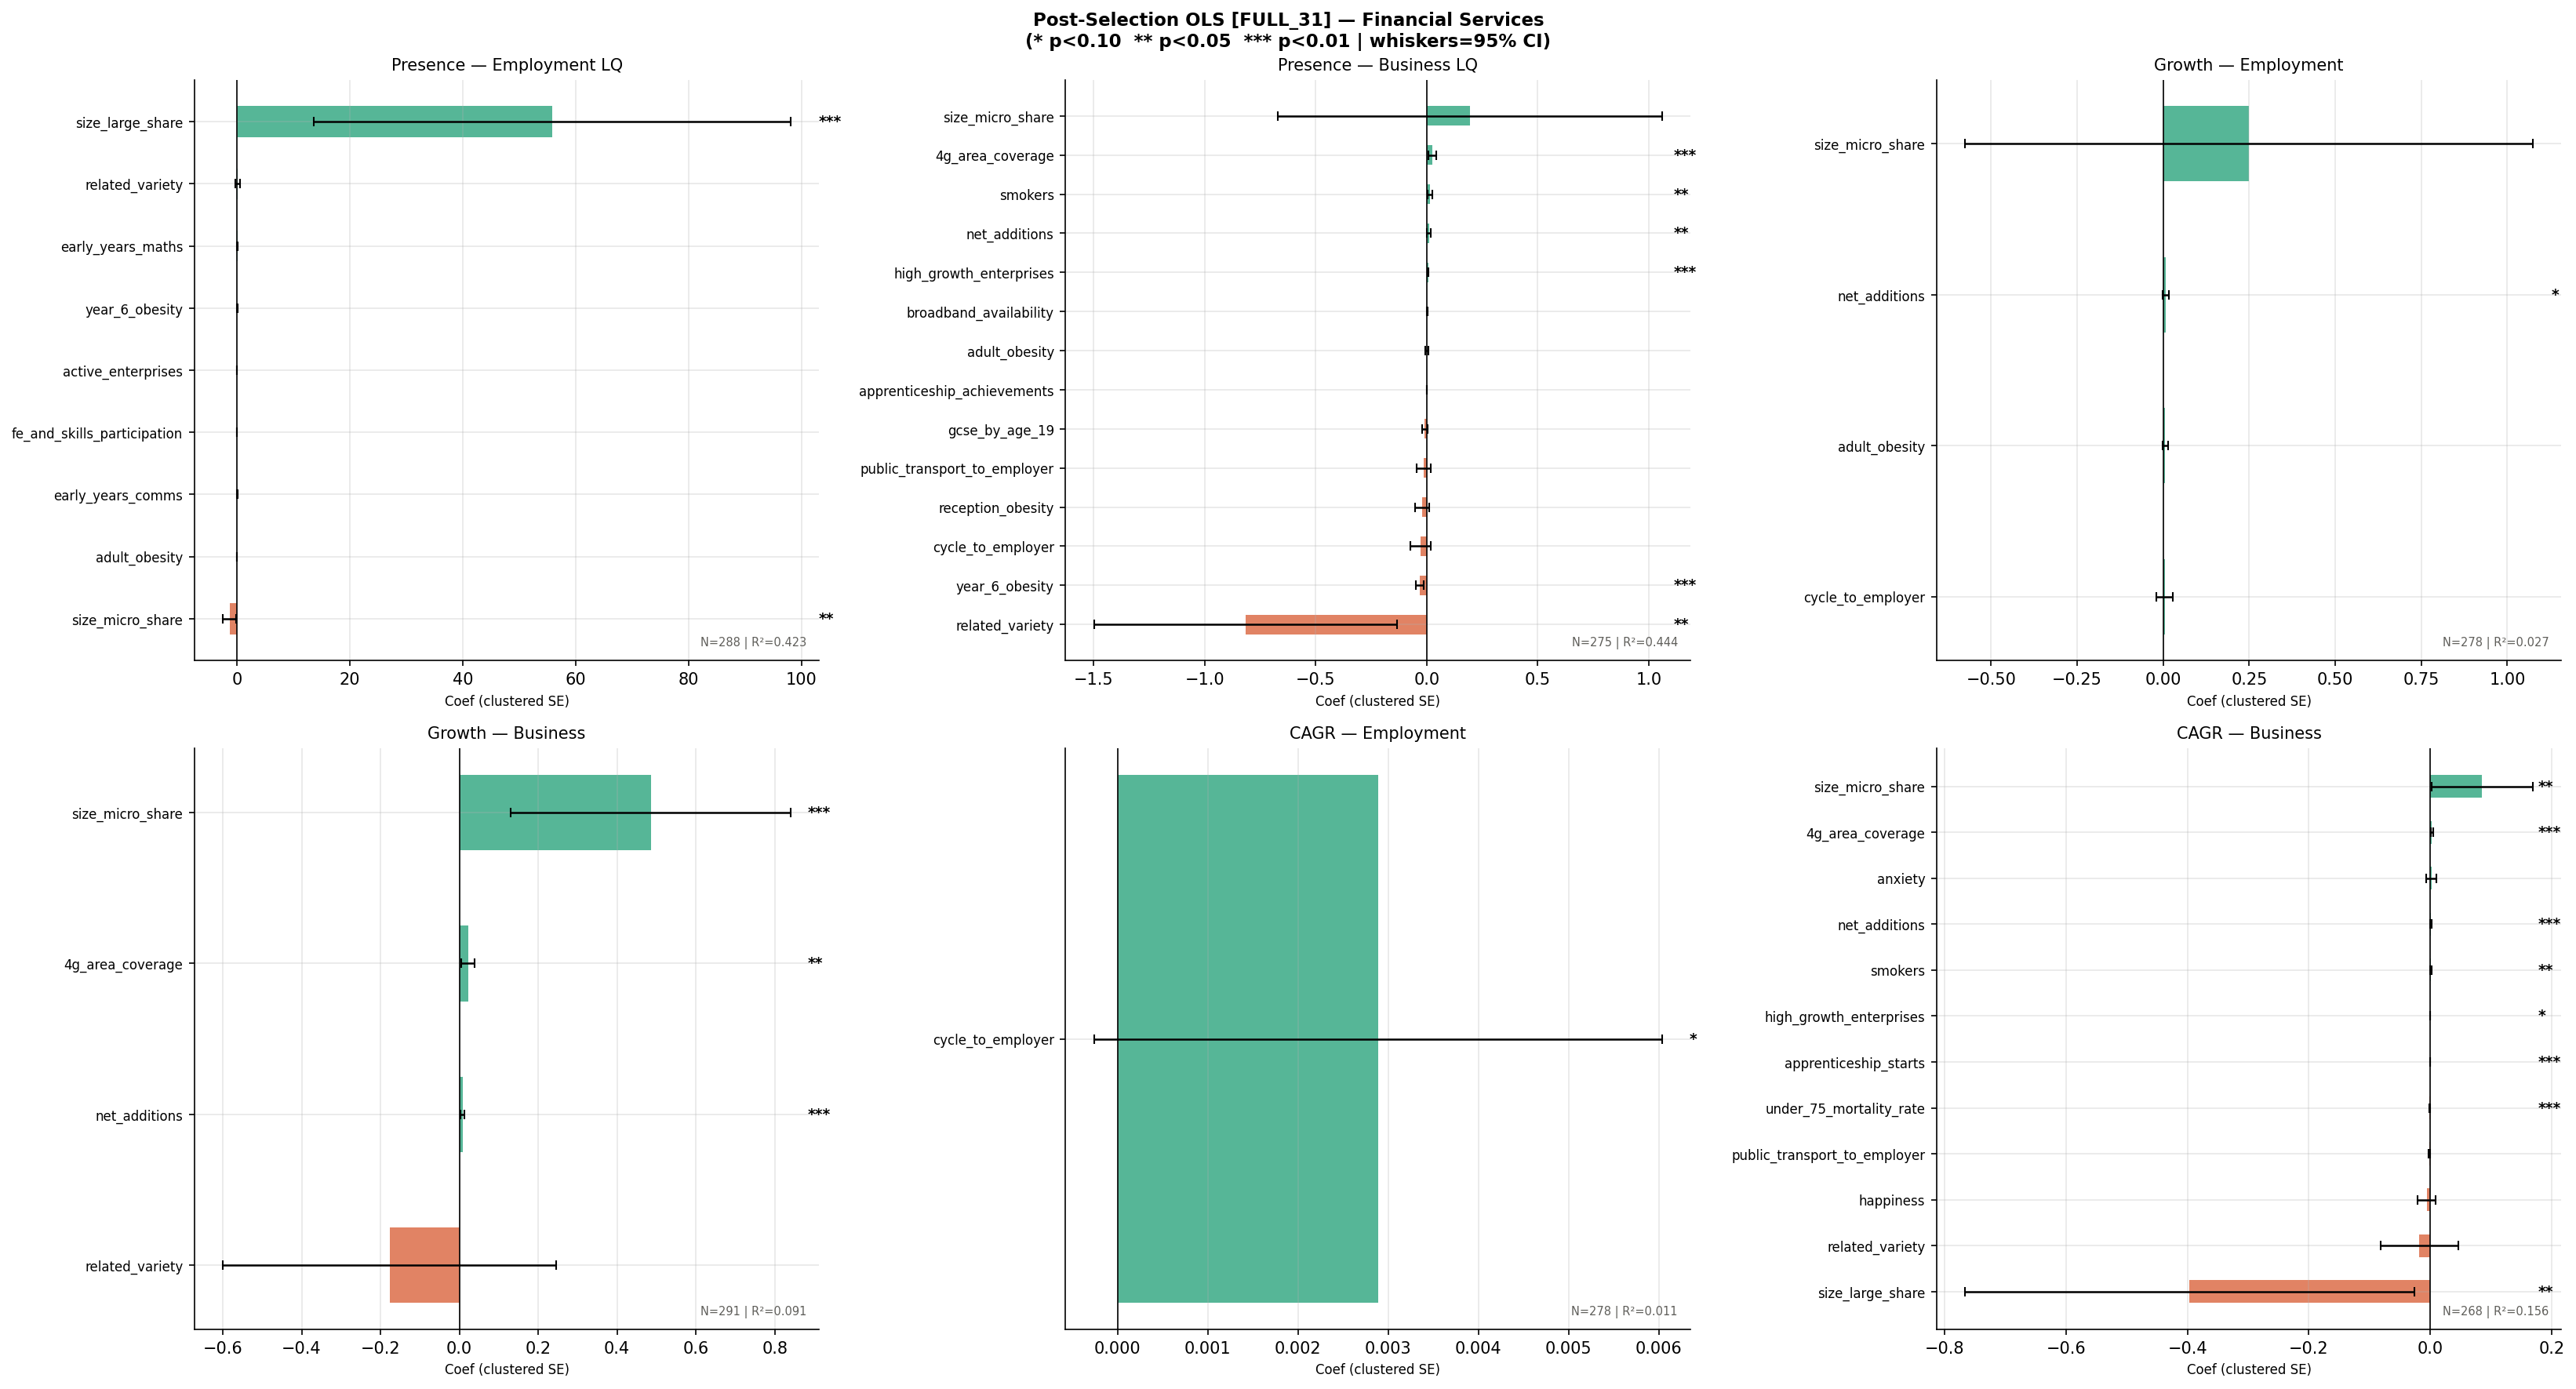

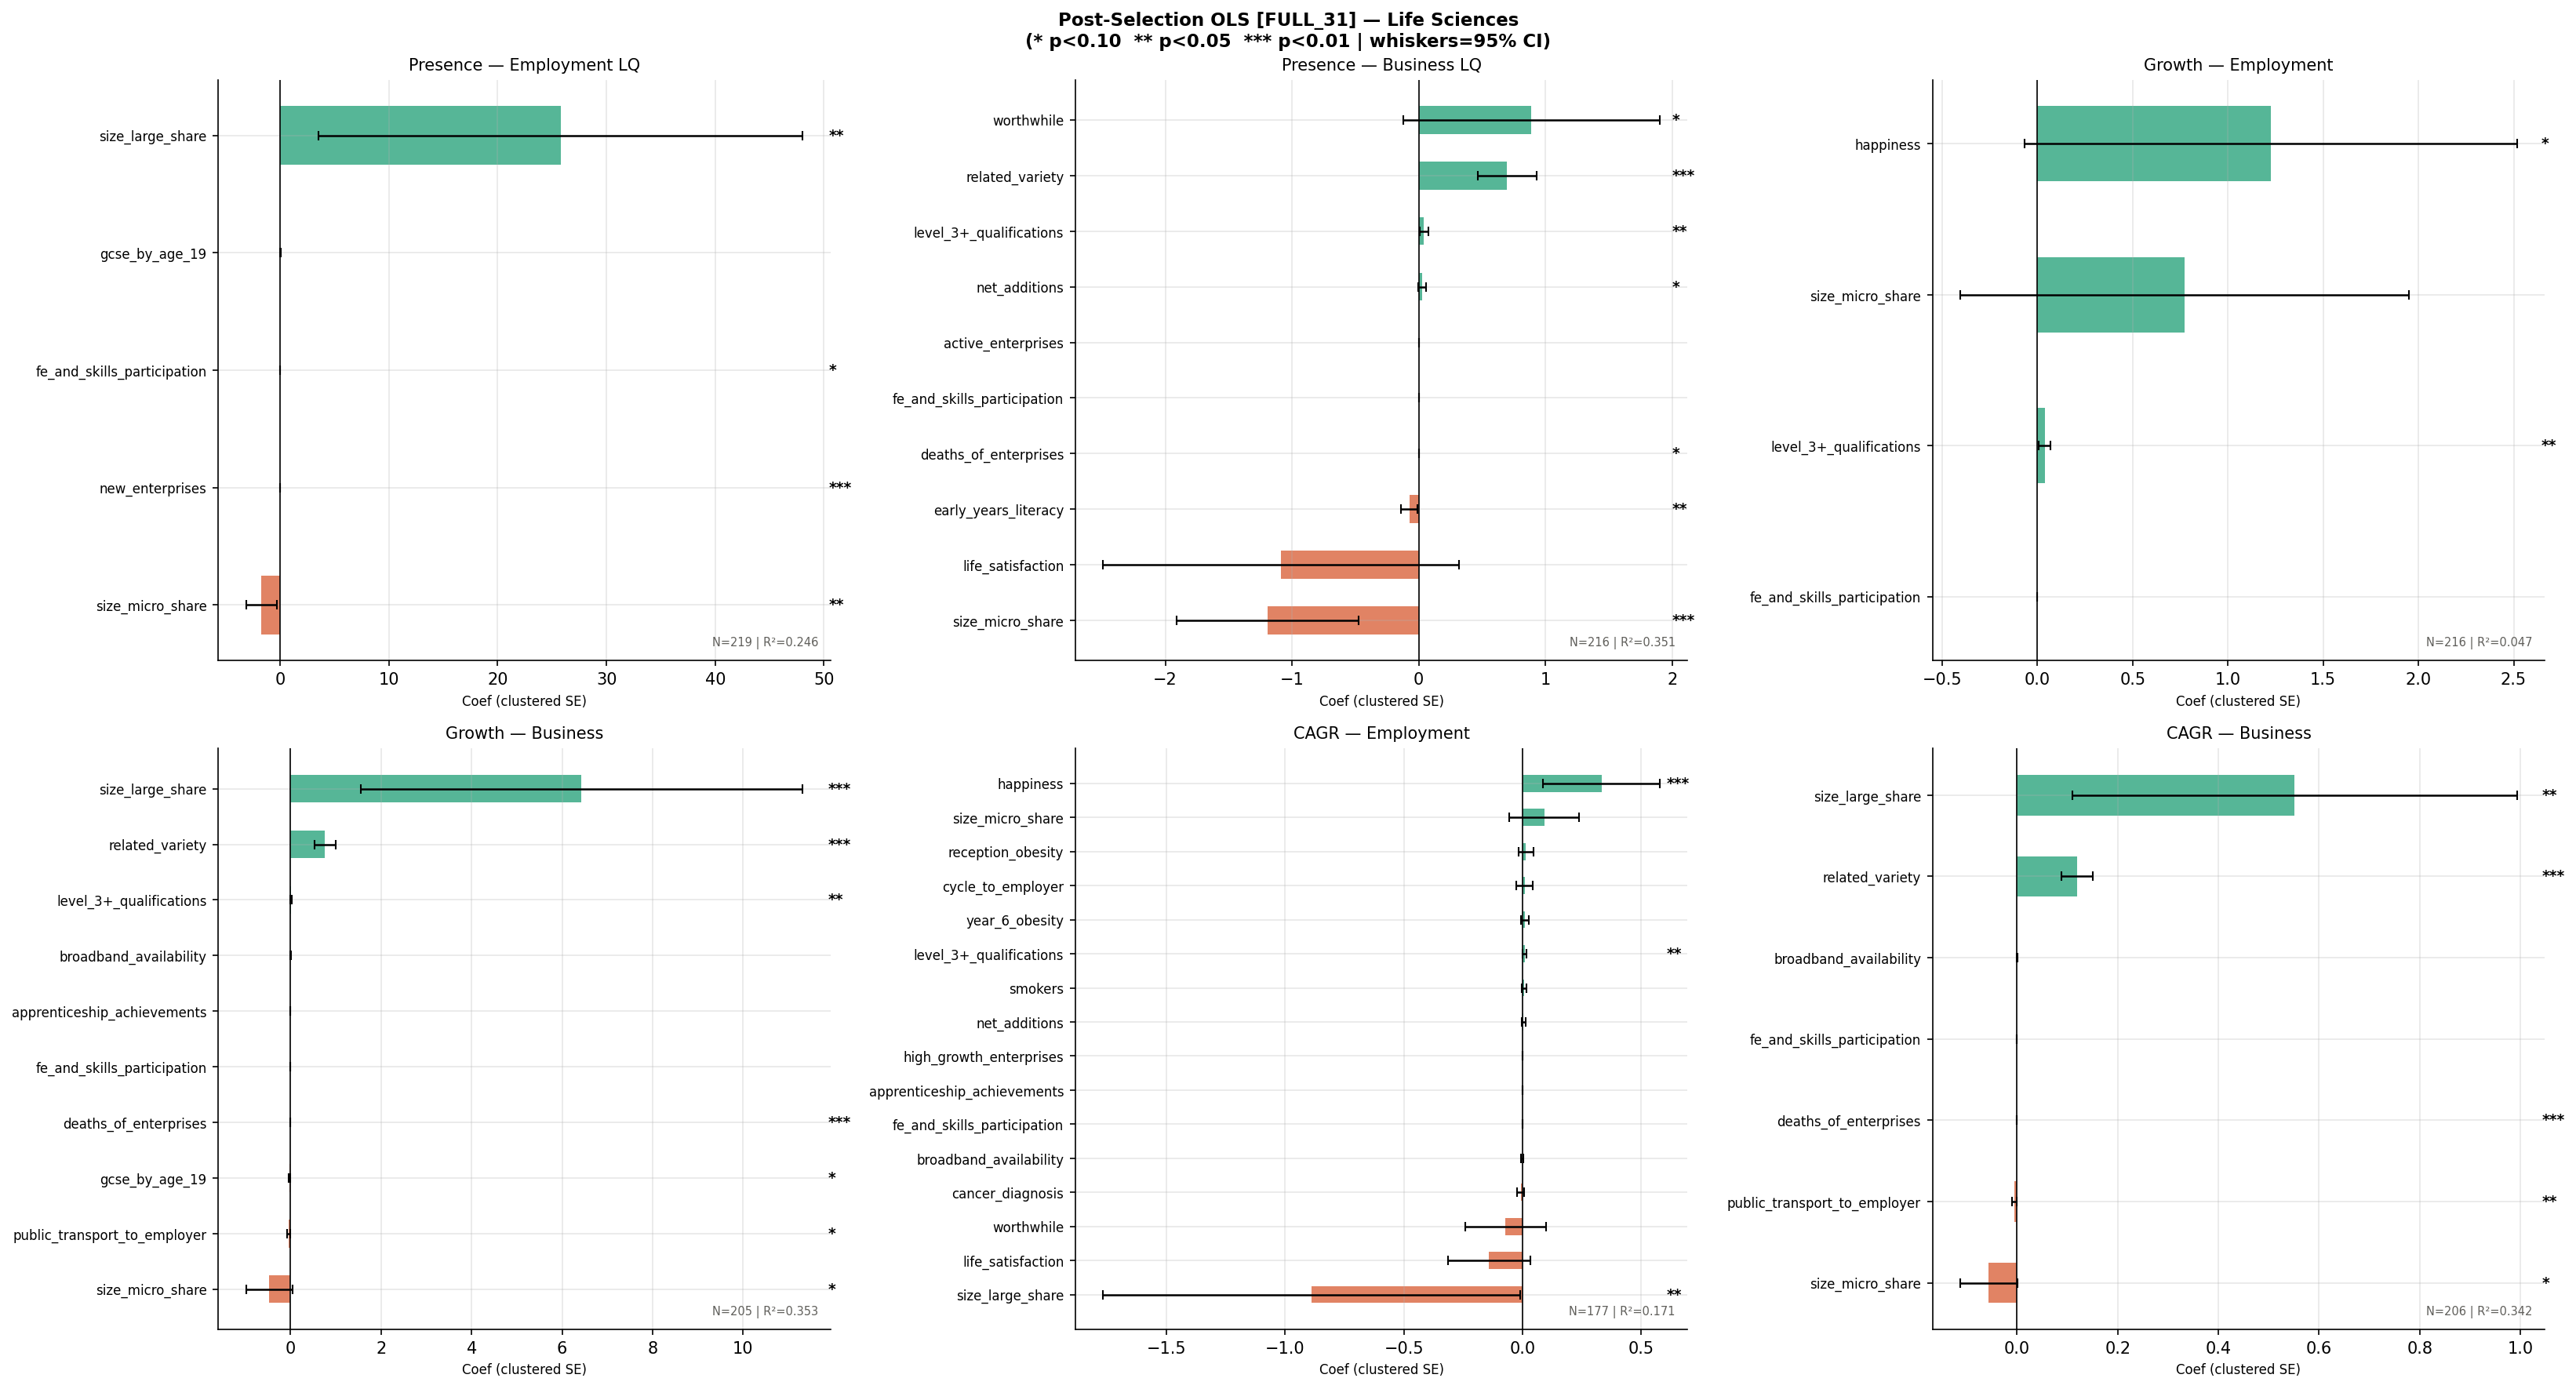

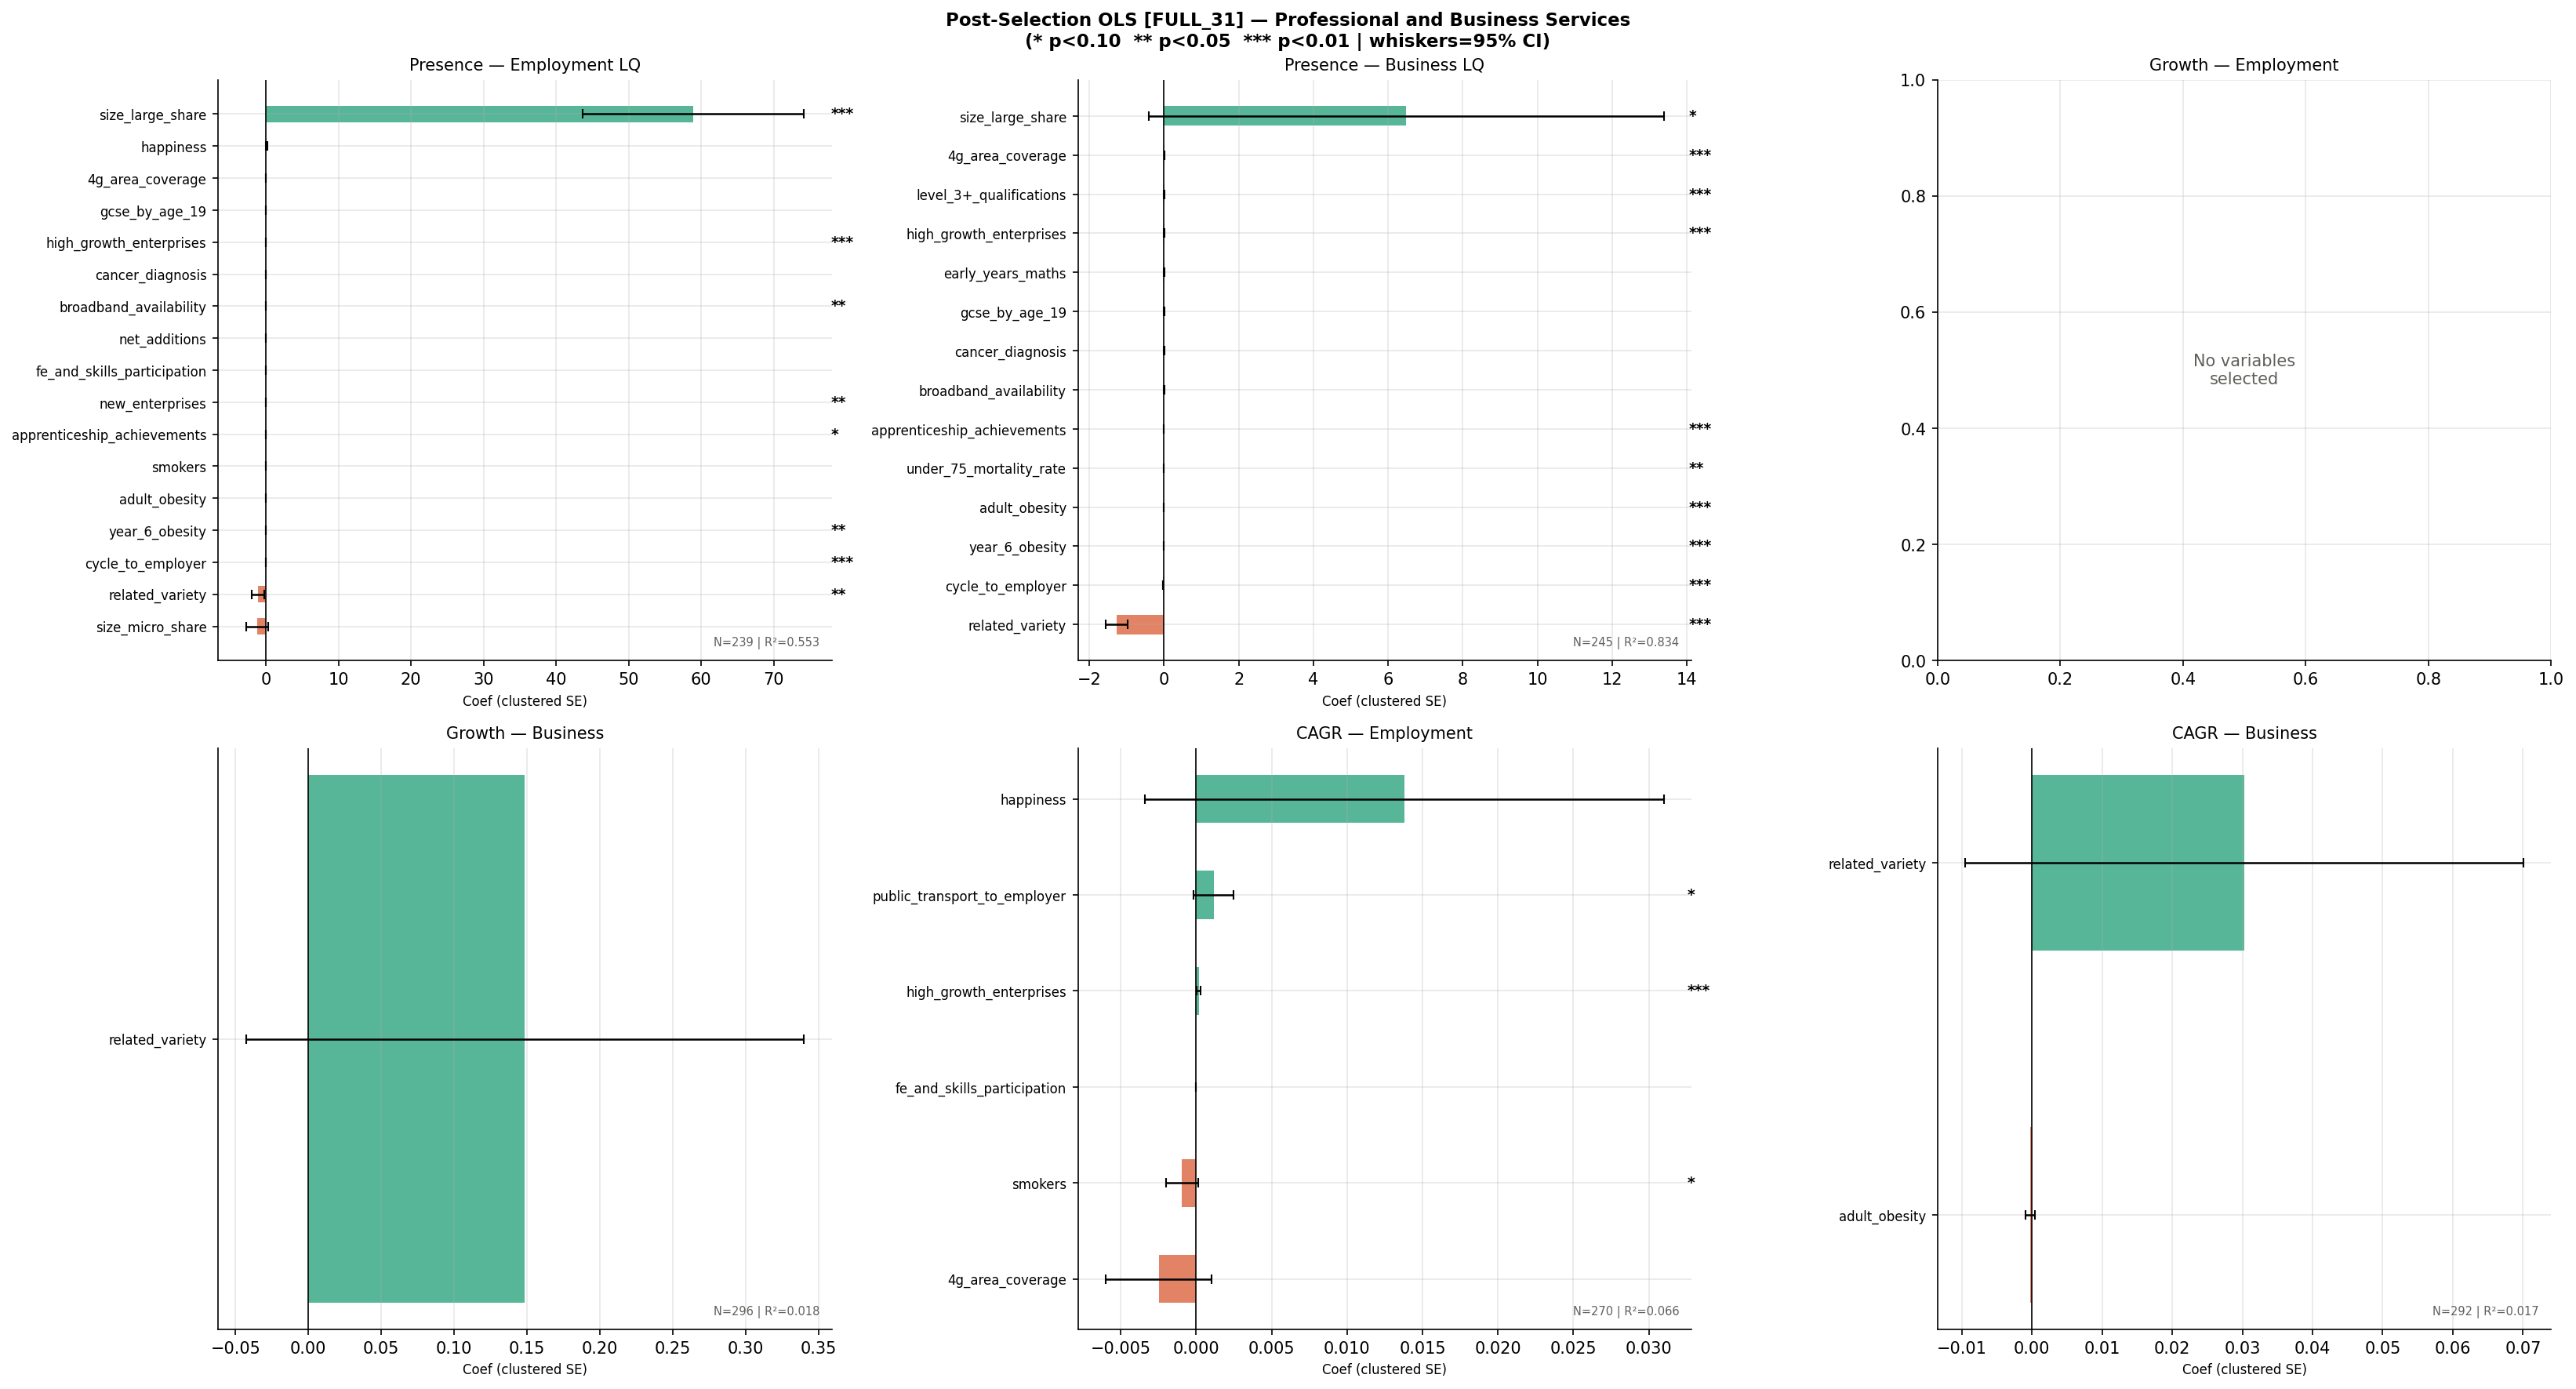

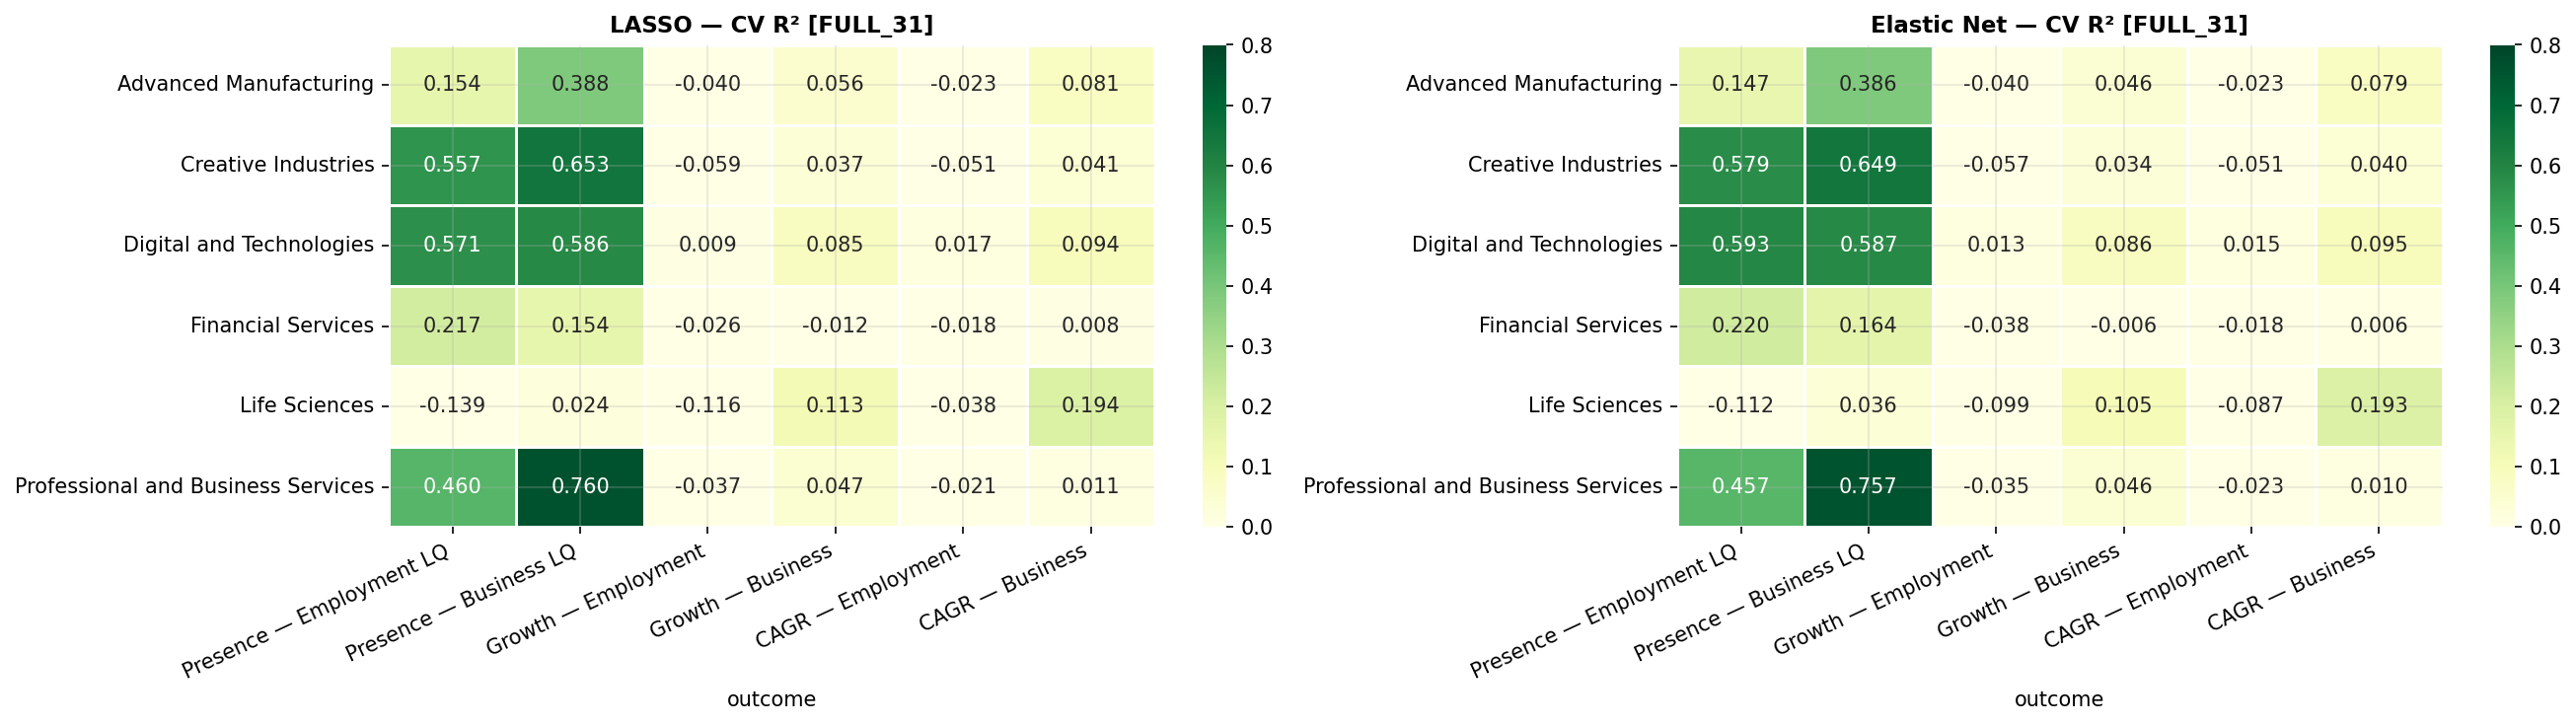

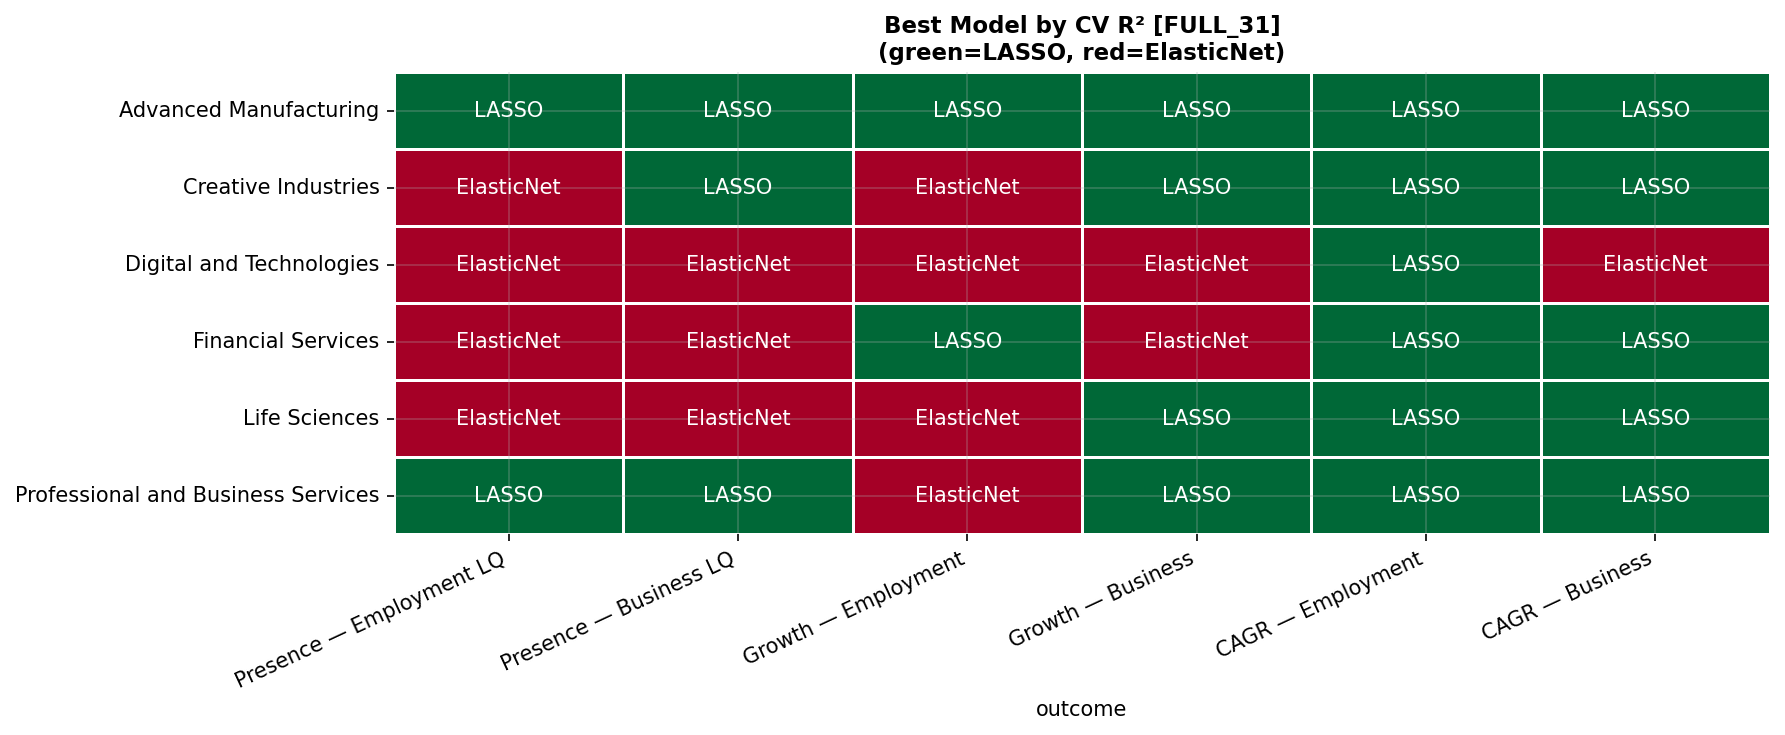


✅ [FULL_31] saved to: output\lasso_full

MASTER COMPARISON TABLE — SHORT vs FULL
(Use CV R² and CV RMSE to compare with Random Forest)
                            sector    outcome  best_cv_r2_short  best_cv_r2_full  r2_gain_full_vs_short recommended_spec
            Advanced Manufacturing     lq_emp             0.011            0.154                  0.143          FULL_31
            Advanced Manufacturing     lq_bus             0.351            0.388                  0.037          FULL_31
            Advanced Manufacturing growth_emp            -0.044           -0.040                  0.004         SHORT_13
            Advanced Manufacturing growth_bus            -0.130            0.056                  0.186          FULL_31
            Advanced Manufacturing   cagr_emp            -0.028           -0.023                  0.005         SHORT_13
            Advanced Manufacturing   cagr_bus            -0.053            0.081                  0.134          FULL_31
               Cr

In [1]:
# ============================================================
# FULL LASSO + ELASTIC NET ANALYSIS
# ── Short (13 vars — EEG theory) vs Full (31 vars — robustness)
# ── 6 sectors × 6 outcomes × 2 models = 72 models per spec
# ── Evaluation metrics for comparison with Random Forest
# ============================================================

import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from pathlib import Path
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
warnings.filterwarnings("ignore")

# ============================================================
# 0. LOAD DATA
# ============================================================

df = pd.read_parquet(
    "G:/Mi unidad/Master_LSE/Git-hub/Economic_Observatory/"
    "data/processed_data/analysis_panel.parquet",
    engine="fastparquet"
)
df.columns = df.columns.str.strip().str.lower()
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

# ============================================================
# 1. CONFIGURATION
# ============================================================

# ── Short predictor list — EEG theory-driven (MAIN MODEL) ────
# Excluded: gva_per_hour, weekly_pay, gdhi_per_head, employment_rate
#           → reverse causality: IS8 presence drives these outcomes
# Excluded: public_transport, drive, cycle_to_employer
#           → missing for 17 English LADs
# Excluded: unemployment_rate
#           → r=-0.07 with outcomes (uninformative); costs 21 LADs
# Excluded: health/wellbeing variables
#           → no EEG theoretical mechanism
# Excluded: early_years_comms/literacy/maths
#           → 15-20 year lag to workforce; no current capability link
# Excluded: ks2_attainment, ofsted, persistent_absences
#           → county/UA level only — below LAD resolution
# Excluded: size_large_share, size_micro_share
#           → endogenous to sector presence (simultaneity bias)
PREDICTORS_SHORT = [
    # Human capital
    "level_3+_qualifications",
    "gcse_by_age_19",
    "apprenticeship_starts",
    "apprenticeship_achievements",
    "fe_and_skills_participation",
    # Entrepreneurial discovery
    "new_enterprises",
    "deaths_of_enterprises",
    "active_enterprises",
    "high_growth_enterprises",
    # Connectivity
    "broadband_availability",
    "4g_area_coverage",
    # Place conditions
    "net_additions",
    # Relatedness (EEG core)
    "related_variety",
]

# ── Full predictor list — robustness check ────────────────────
PREDICTORS_FULL = [
    "new_enterprises",
    "deaths_of_enterprises",
    "active_enterprises",
    "high_growth_enterprises",
    "broadband_availability",
    "4g_area_coverage",
    "gcse_by_age_19",
    "early_years_comms",
    "early_years_literacy",
    "early_years_maths",
    "apprenticeship_starts",
    "apprenticeship_achievements",
    "level_3+_qualifications",
    "fe_and_skills_participation",
    "smokers",
    "reception_obesity",
    "year_6_obesity",
    "adult_obesity",
    "cancer_diagnosis",
    "under_75_mortality_rate",
    "life_satisfaction",
    "worthwhile",
    "happiness",
    "anxiety",
    "net_additions",
    "related_variety",
    "size_large_share",
    "size_micro_share",
    "public_transport_to_employer",
    "drive_to_employer",
    "cycle_to_employer",
]

# ── Outcomes ──────────────────────────────────────────────────
OUTCOMES = {
    "lq_emp":     "Presence — Employment LQ",
    "lq_bus":     "Presence — Business LQ",
    "growth_emp": "Growth — Employment",
    "growth_bus": "Growth — Business",
    "cagr_emp":   "CAGR — Employment",
    "cagr_bus":   "CAGR — Business",
}

# ── Sectors ───────────────────────────────────────────────────
SECTORS = [
    "Advanced Manufacturing",
    "Creative Industries",
    "Digital and Technologies",
    "Financial Services",
    "Life Sciences",
    "Professional and Business Services",
]

# ── Colours ───────────────────────────────────────────────────
TEAL   = "#1D9E75"
CORAL  = "#D85A30"
GRAY   = "#5F5E5A"

# ── Plot style ────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "sans-serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
})

def stars(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

# ============================================================
# 2. PREPARE CROSS-SECTION
# ============================================================

END_YEAR = df["year"].max()
df_cs    = df[
    df["geography_code"].str.startswith("E") &
    (df["year"] == END_YEAR)
].copy()
print(f"\nEngland cross-section: {df_cs.shape[0]:,} rows | "
      f"{df_cs['geography_code'].nunique()} LADs | Year: {END_YEAR}")

# ============================================================
# 3. CORE MODELLING FUNCTIONS
# ============================================================

def run_lasso_enet(sector_df, y_col, predictors,
                   sector_name, outcome_label):
    """
    Fits LASSO and Elastic Net for one sector × outcome.
    Returns coefficients, selection flags, and CV metrics.
    """
    cols     = ["geography_code"] + predictors + [y_col]
    model_df = sector_df[cols].dropna()
    n        = len(model_df)

    if n < 30:
        return None

    X = StandardScaler().fit_transform(
            model_df[predictors].values.astype(float))
    y = model_df[y_col].values.astype(float)

    n_splits = max(min(5, n // 10), 3)
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    # ── LASSO ─────────────────────────────────────────────────
    lasso = LassoCV(alphas=np.logspace(-4, 2, 100),
                    cv=cv, max_iter=10_000, random_state=42)
    lasso.fit(X, y)

    # ── Elastic Net ───────────────────────────────────────────
    enet = ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
        alphas=np.logspace(-4, 2, 50),
        cv=cv, max_iter=10_000, random_state=42)
    enet.fit(X, y)

    # ── Variable selection ────────────────────────────────────
    results = pd.DataFrame({
        "variable":   predictors,
        "lasso_coef": lasso.coef_,
        "enet_coef":  enet.coef_,
    })
    results["selected_lasso"] = results["lasso_coef"] != 0
    results["selected_enet"]  = results["enet_coef"]  != 0
    results["selected_both"]  = (results["selected_lasso"]
                                 & results["selected_enet"])

    # ── CV metrics (out-of-sample) ────────────────────────────
    # These are the metrics to compare with Random Forest
    def cv_metrics(estimator):
        r2   = cross_val_score(estimator, X, y, cv=cv,
                               scoring="r2")
        rmse = cross_val_score(estimator, X, y, cv=cv,
                               scoring="neg_root_mean_squared_error")
        mae  = cross_val_score(estimator, X, y, cv=cv,
                               scoring="neg_mean_absolute_error")
        return (round(r2.mean(), 3),   round(r2.std(), 3),
                round(-rmse.mean(), 3), round(-mae.mean(), 3))

    l_r2, l_r2s, l_rmse, l_mae = cv_metrics(lasso)
    e_r2, e_r2s, e_rmse, e_mae = cv_metrics(enet)

    return {
        "sector":        sector_name,
        "outcome":       y_col,
        "outcome_label": outcome_label,
        "n":             n,
        "results":       results,
        "geography_code": model_df["geography_code"].values,
        "X": X, "y": y,
        # LASSO metrics
        "lasso_lambda":    round(lasso.alpha_, 6),
        "lasso_cv_r2":     l_r2,
        "lasso_cv_r2_std": l_r2s,
        "lasso_cv_rmse":   l_rmse,
        "lasso_cv_mae":    l_mae,
        "lasso_r2_train":  round(r2_score(y, lasso.predict(X)), 3),
        "lasso_n_vars":    int((lasso.coef_ != 0).sum()),
        # Elastic Net metrics
        "enet_lambda":    round(enet.alpha_, 6),
        "enet_l1_ratio":  round(enet.l1_ratio_, 2),
        "enet_cv_r2":     e_r2,
        "enet_cv_r2_std": e_r2s,
        "enet_cv_rmse":   e_rmse,
        "enet_cv_mae":    e_mae,
        "enet_r2_train":  round(r2_score(y, enet.predict(X)), 3),
        "enet_n_vars":    int((enet.coef_ != 0).sum()),
        # Best model per row
        "best_model": "LASSO" if l_r2 >= e_r2 else "ElasticNet",
        "best_cv_r2": max(l_r2, e_r2),
    }


def run_post_ols(sector_df, y_col, selected_vars,
                 sector_name, outcome_label):
    """OLS on LASSO-selected variables with LAD-clustered SE."""
    if not selected_vars:
        return None

    cols     = ["geography_code"] + selected_vars + [y_col]
    model_df = sector_df[cols].dropna()
    n        = len(model_df)
    if n < 30:
        return None

    X_ols  = sm.add_constant(
        model_df[selected_vars].values.astype(float))
    y_ols  = model_df[y_col].values.astype(float)
    groups = model_df["geography_code"].values

    model  = sm.OLS(y_ols, X_ols).fit(
        cov_type="cluster",
        cov_kwds={"groups": groups})

    res = pd.DataFrame({
        "variable": ["Intercept"] + selected_vars,
        "coef":     model.params,
        "se":       model.bse,
        "t":        model.tvalues,
        "p_value":  model.pvalues,
        "ci_low":   model.conf_int()[:, 0],
        "ci_high":  model.conf_int()[:, 1],
    })
    res["stars"] = res["p_value"].apply(stars)
    res = res[res["variable"] != "Intercept"].copy()

    return {
        "sector": sector_name, "outcome": y_col,
        "outcome_label": outcome_label,
        "n": n,
        "r2":     round(model.rsquared,     3),
        "r2_adj": round(model.rsquared_adj, 3),
        "n_sig":  int((res["p_value"] < 0.05).sum()),
        "results": res,
    }

# ============================================================
# 4. RUN ANALYSIS FOR ONE PREDICTOR SPEC
# ============================================================

def run_spec(predictors, spec_label, out_dir):
    """
    Runs complete analysis for one predictor specification.
    Returns all_models dict and summary DataFrames.
    """
    out_dir.mkdir(parents=True, exist_ok=True)
    print(f"\n{'='*65}")
    print(f"SPEC: {spec_label} ({len(predictors)} predictors)")
    print(f"{'='*65}")

    all_models = {}
    all_ols    = {}
    rows_lasso = []
    rows_ols   = []

    for sector in SECTORS:
        s_df = df_cs[df_cs["is8_sector"] == sector].copy()
        print(f"\n── {sector} ──")

        for y_col, outcome_label in OUTCOMES.items():
            # ── LASSO + Elastic Net ───────────────────────────
            r = run_lasso_enet(s_df, y_col, predictors,
                               sector, outcome_label)
            if r is None:
                continue

            all_models[(sector, y_col)] = r
            rows_lasso.append({
                "spec":         spec_label,
                "sector":       sector,
                "outcome":      y_col,
                "outcome_label": outcome_label,
                "n":            r["n"],
                "lasso_lambda": r["lasso_lambda"],
                "lasso_n_vars": r["lasso_n_vars"],
                "lasso_cv_r2":  r["lasso_cv_r2"],
                "lasso_cv_r2_std": r["lasso_cv_r2_std"],
                "lasso_cv_rmse": r["lasso_cv_rmse"],
                "lasso_cv_mae":  r["lasso_cv_mae"],
                "lasso_r2_train": r["lasso_r2_train"],
                "enet_lambda":  r["enet_lambda"],
                "enet_l1_ratio": r["enet_l1_ratio"],
                "enet_n_vars":  r["enet_n_vars"],
                "enet_cv_r2":   r["enet_cv_r2"],
                "enet_cv_r2_std": r["enet_cv_r2_std"],
                "enet_cv_rmse": r["enet_cv_rmse"],
                "enet_cv_mae":  r["enet_cv_mae"],
                "enet_r2_train": r["enet_r2_train"],
                "best_model":   r["best_model"],
                "best_cv_r2":   r["best_cv_r2"],
            })
            print(f"  ✓ {sector[:20]} | {y_col:10} | "
                  f"N={r['n']} | "
                  f"LASSO R²={r['lasso_cv_r2']:.3f} | "
                  f"ENet R²={r['enet_cv_r2']:.3f} | "
                  f"Best={r['best_model']}")

            # ── Post-selection OLS ────────────────────────────
            sel_vars = r["results"][
                r["results"]["selected_both"]
            ]["variable"].tolist()

            ols = run_post_ols(s_df, y_col, sel_vars,
                               sector, outcome_label)
            if ols:
                all_ols[(sector, y_col)] = ols
                rows_ols.append({
                    "spec":    spec_label,
                    "sector":  sector,
                    "outcome": y_col,
                    "n":       ols["n"],
                    "r2":      ols["r2"],
                    "r2_adj":  ols["r2_adj"],
                    "n_sig":   ols["n_sig"],
                    "n_vars":  len(sel_vars),
                })

    lasso_df = pd.DataFrame(rows_lasso)
    ols_df   = pd.DataFrame(rows_ols)

    lasso_df.to_csv(out_dir / "lasso_metrics.csv",    index=False)
    ols_df.to_csv(out_dir   / "ols_summary.csv",      index=False)

    # OLS full coefficients
    ols_rows = []
    for (sec, y_col), o in all_ols.items():
        r = o["results"].copy()
        r["sector"] = sec; r["outcome"] = y_col
        r["n"] = o["n"];   r["r2"] = o["r2"]
        ols_rows.append(r)
    if ols_rows:
        pd.concat(ols_rows).to_csv(
            out_dir / "ols_coefficients.csv", index=False)

    # ── PLOTS ─────────────────────────────────────────────────
    n_out  = len(OUTCOMES)
    n_cols = 3
    n_rows = math.ceil(n_out / n_cols)

    # Plot 1 — Selection heatmap
    sel_records = []
    for (sec, y_col), r in all_models.items():
        for _, row in r["results"].iterrows():
            sel_records.append({
                "variable": row["variable"],
                "sector":   sec,
                "outcome":  y_col,
                "selected": int(row["selected_both"]),
            })
    sel_df = pd.DataFrame(sel_records)

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(22, n_rows * 7))
    axes = axes.flatten()
    for ax_idx, (y_col, out_label) in enumerate(OUTCOMES.items()):
        ax     = axes[ax_idx]
        subset = sel_df[sel_df["outcome"] == y_col]
        pivot  = subset.pivot(index="variable",
                              columns="sector",
                              values="selected")
        pivot  = pivot.reindex(
            columns=SECTORS, index=predictors
        ).fillna(0).astype(int)
        sns.heatmap(pivot, ax=ax, annot=True, fmt="d",
                    cmap="YlGn", linewidths=0.5,
                    linecolor="white", cbar=False,
                    vmin=0, vmax=1)
        ax.set_title(out_label, fontsize=11,
                     fontweight="bold", pad=8)
        ax.set_xlabel(""); ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=30)
        ax.tick_params(axis="y", rotation=0)
    for i in range(n_out, len(axes)):
        axes[i].set_visible(False)
    plt.suptitle(
        f"Variable Selection [{spec_label}]\n"
        "(1 = selected by LASSO + ElasticNet)",
        fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(out_dir / "01_selection_heatmap.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    # Plot 2 — LASSO coef plots per sector
    for sector in SECTORS:
        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(22, n_rows * 6),
                                 sharey=False)
        axes = axes.flatten()
        fig.suptitle(f"LASSO Coefficients [{spec_label}] — {sector}",
                     fontsize=12, fontweight="bold")
        for ax_idx, (y_col, out_label) in enumerate(OUTCOMES.items()):
            ax = axes[ax_idx]
            if (sector, y_col) not in all_models:
                ax.text(0.5, 0.5, "Insufficient data",
                        ha="center", va="center",
                        transform=ax.transAxes)
                ax.set_title(out_label, fontsize=10)
                continue
            res = all_models[(sector, y_col)]["results"]
            sel = res[res["selected_both"]].sort_values("lasso_coef")
            if sel.empty:
                ax.text(0.5, 0.5, "No variables\nselected",
                        ha="center", va="center",
                        transform=ax.transAxes,
                        color=GRAY, fontsize=10)
                ax.set_title(out_label, fontsize=10)
                ax.axvline(0, color="black", linewidth=0.8)
                continue
            colors = [CORAL if c < 0 else TEAL
                      for c in sel["lasso_coef"]]
            ax.barh(sel["variable"], sel["lasso_coef"],
                    color=colors, alpha=0.85, height=0.6)
            ax.scatter(sel["enet_coef"], sel["variable"],
                       color="black", zorder=5, s=30,
                       label="ElasticNet")
            ax.axvline(0, color="black", linewidth=0.8)
            ax.set_title(out_label, fontsize=10)
            ax.set_xlabel("Standardised coef", fontsize=9)
            r = all_models[(sector, y_col)]
            ax.text(0.98, 0.02,
                    f"N={r['n']} | λ={r['lasso_lambda']:.4f} | "
                    f"{r['lasso_n_vars']} vars | "
                    f"CV R²={r['lasso_cv_r2']:.3f}",
                    transform=ax.transAxes, fontsize=7,
                    ha="right", va="bottom", color=GRAY)
            if ax_idx == 0:
                ax.legend(fontsize=8, loc="lower right")
        for i in range(n_out, len(axes)):
            axes[i].set_visible(False)
        plt.tight_layout()
        slug = sector.lower().replace(" ", "_")
        plt.savefig(out_dir / f"02_lasso_{slug}.png",
                    dpi=150, bbox_inches="tight")
        plt.show()

    # Plot 3 — OLS coef plots per sector
    for sector in SECTORS:
        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(22, n_rows * 6),
                                 sharey=False)
        axes = axes.flatten()
        fig.suptitle(
            f"Post-Selection OLS [{spec_label}] — {sector}\n"
            "(* p<0.10  ** p<0.05  *** p<0.01 | whiskers=95% CI)",
            fontsize=11, fontweight="bold")
        for ax_idx, (y_col, out_label) in enumerate(OUTCOMES.items()):
            ax = axes[ax_idx]
            if (sector, y_col) not in all_ols:
                ax.text(0.5, 0.5, "No variables\nselected",
                        ha="center", va="center",
                        transform=ax.transAxes,
                        color=GRAY, fontsize=10)
                ax.set_title(out_label, fontsize=10)
                continue
            ols   = all_ols[(sector, y_col)]
            res   = ols["results"].sort_values("coef")
            y_pos = np.arange(len(res))
            colors = [CORAL if c < 0 else TEAL
                      for c in res["coef"]]
            ax.barh(y_pos, res["coef"].values,
                    color=colors, alpha=0.75, height=0.5)
            ax.errorbar(
                x=res["coef"].values, y=y_pos,
                xerr=[res["coef"].values - res["ci_low"].values,
                      res["ci_high"].values - res["coef"].values],
                fmt="none", color="black",
                linewidth=1.2, capsize=3)
            x_max = res["ci_high"].abs().max()
            for i, (_, row) in enumerate(res.iterrows()):
                if row["stars"]:
                    ax.text(x_max * 1.05, i, row["stars"],
                            va="center", fontsize=9,
                            fontweight="bold")
            ax.axvline(0, color="black", linewidth=0.8)
            ax.set_yticks(y_pos)
            ax.set_yticklabels(res["variable"].values, fontsize=8)
            ax.set_title(out_label, fontsize=10)
            ax.set_xlabel("Coef (clustered SE)", fontsize=8)
            ax.text(0.98, 0.02,
                    f"N={ols['n']} | R²={ols['r2']:.3f}",
                    transform=ax.transAxes, fontsize=7,
                    ha="right", va="bottom", color=GRAY)
        for i in range(n_out, len(axes)):
            axes[i].set_visible(False)
        plt.tight_layout()
        slug = sector.lower().replace(" ", "_")
        plt.savefig(out_dir / f"03_ols_{slug}.png",
                    dpi=150, bbox_inches="tight")
        plt.show()

    # Plot 4 — CV R² heatmap (LASSO vs ENet side by side)
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    for ax, model_col, title in zip(
        axes,
        ["lasso_cv_r2", "enet_cv_r2"],
        ["LASSO — CV R²", "Elastic Net — CV R²"]
    ):
        piv = lasso_df.pivot(
            index="sector", columns="outcome",
            values=model_col
        ).reindex(columns=list(OUTCOMES.keys()),
                  index=SECTORS).fillna(0)
        sns.heatmap(piv, ax=ax, annot=True, fmt=".3f",
                    cmap="YlGn", linewidths=0.5,
                    linecolor="white", vmin=0, vmax=0.8)
        ax.set_title(f"{title} [{spec_label}]",
                     fontsize=11, fontweight="bold")
        ax.set_xticklabels(
            [OUTCOMES.get(c, c) for c in piv.columns],
            rotation=25, ha="right")
        ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(out_dir / "04_cv_r2_heatmap.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    # Plot 5 — Best model per cell
    piv_best = lasso_df.pivot(
        index="sector", columns="outcome", values="best_model"
    ).reindex(columns=list(OUTCOMES.keys()), index=SECTORS)
    piv_num  = (piv_best == "LASSO").astype(float)

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.heatmap(piv_num, ax=ax, annot=piv_best,
                fmt="", cmap="RdYlGn",
                linewidths=0.5, linecolor="white",
                vmin=0, vmax=1, cbar=False)
    ax.set_title(
        f"Best Model by CV R² [{spec_label}]\n"
        "(green=LASSO, red=ElasticNet)",
        fontsize=11, fontweight="bold")
    ax.set_xticklabels(
        [OUTCOMES.get(c, c) for c in piv_best.columns],
        rotation=25, ha="right")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(out_dir / "05_best_model.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\n✅ [{spec_label}] saved to: {out_dir}")
    return all_models, all_ols, lasso_df, ols_df

# ============================================================
# 5. RUN BOTH SPECIFICATIONS
# ============================================================

models_short, ols_short, metrics_short, ols_sum_short = run_spec(
    predictors  = PREDICTORS_SHORT,
    spec_label  = "SHORT_13",
    out_dir     = Path("output/lasso_short")
)

models_full, ols_full, metrics_full, ols_sum_full = run_spec(
    predictors  = PREDICTORS_FULL,
    spec_label  = "FULL_31",
    out_dir     = Path("output/lasso_full")
)

# ============================================================
# 6. MASTER COMPARISON TABLE
# ============================================================
# This table is the one to share with your classmate
# for comparison with Random Forest

print(f"\n{'='*65}")
print("MASTER COMPARISON TABLE — SHORT vs FULL")
print("(Use CV R² and CV RMSE to compare with Random Forest)")
print(f"{'='*65}")

comp = metrics_short[[
    "sector", "outcome",
    "lasso_cv_r2", "lasso_cv_rmse", "lasso_n_vars",
    "enet_cv_r2",  "enet_cv_rmse",  "enet_n_vars",
    "best_model",
]].merge(
    metrics_full[[
        "sector", "outcome",
        "lasso_cv_r2", "lasso_cv_rmse",
        "enet_cv_r2",  "enet_cv_rmse",
        "best_model",
    ]],
    on=["sector", "outcome"],
    suffixes=("_short", "_full")
)

# Best overall per row
comp["best_cv_r2_short"] = comp[["lasso_cv_r2_short",
                                  "enet_cv_r2_short"]].max(axis=1)
comp["best_cv_r2_full"]  = comp[["lasso_cv_r2_full",
                                  "enet_cv_r2_full"]].max(axis=1)
comp["r2_gain_full_vs_short"] = (
    comp["best_cv_r2_full"] - comp["best_cv_r2_short"]
).round(3)
comp["recommended_spec"] = np.where(
    comp["r2_gain_full_vs_short"] > 0.02,
    "FULL_31", "SHORT_13"
)

print(comp[[
    "sector", "outcome",
    "best_cv_r2_short", "best_cv_r2_full",
    "r2_gain_full_vs_short", "recommended_spec"
]].to_string(index=False))

comp.to_csv("output/comparison_short_vs_full.csv", index=False)

# ── Summary by outcome ────────────────────────────────────────
print(f"\n── Average CV R² by outcome ──")
avg = comp.groupby("outcome")[
    ["best_cv_r2_short", "best_cv_r2_full"]
].mean().round(3)
print(avg.to_string())

# ── Template for Random Forest comparison ─────────────────────
rf_template = comp[[
    "sector", "outcome",
    "best_cv_r2_short", "best_cv_r2_full"
]].copy()
rf_template["rf_cv_r2"]   = np.nan  # fill with RF results
rf_template["rf_cv_rmse"] = np.nan  # fill with RF results
rf_template["best_overall"] = np.nan
rf_template.to_csv("output/rf_comparison_template.csv", index=False)

print(f"\n✅ All outputs saved:")
print(f"   output/lasso_short/         — 13-predictor analysis")
print(f"   output/lasso_full/          — 31-predictor analysis")
print(f"   output/comparison_short_vs_full.csv")
print(f"   output/rf_comparison_template.csv")
print(f"\n📋 Share rf_comparison_template.csv with your classmate")
print(f"   Ask them to fill in rf_cv_r2 and rf_cv_rmse columns")
print(f"   Then run the comparison plot below")

# ============================================================
# 7. READY FOR RF COMPARISON (run after filling template)
# ============================================================
# Once your classmate provides RF metrics, fill the template
# and run this block to produce the final comparison plot

def plot_rf_comparison(template_path):
    df_comp = pd.read_csv(template_path).dropna(
        subset=["rf_cv_r2"])

    fig, ax = plt.subplots(figsize=(14, 6))
    x       = np.arange(len(df_comp))
    width   = 0.25

    ax.bar(x - width, df_comp["best_cv_r2_short"],
           width, label="LASSO/ENet (13 vars)", color=TEAL, alpha=0.85)
    ax.bar(x,         df_comp["best_cv_r2_full"],
           width, label="LASSO/ENet (31 vars)", color=TEAL, alpha=0.5)
    ax.bar(x + width, df_comp["rf_cv_r2"],
           width, label="Random Forest",        color=CORAL, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(
        df_comp["sector"] + "\n" + df_comp["outcome"],
        rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("CV R² (out-of-sample)")
    ax.set_title("Model Comparison: LASSO vs Elastic Net vs Random Forest\n"
                 "(CV R² — higher is better)",
                 fontsize=12, fontweight="bold")
    ax.legend()
    ax.axhline(0, color="black", linewidth=0.5)
    plt.tight_layout()
    plt.savefig("output/model_comparison_lasso_vs_rf.png",
                dpi=150, bbox_inches="tight")
    plt.show()

# Uncomment when RF results are available:
# plot_rf_comparison("output/rf_comparison_template.csv")

In [3]:
import os
print(os.path.abspath("output/model_comparison_coloured.xlsx"))

g:\Mi unidad\Master_LSE\Git-hub\Economic_Observatory\output\model_comparison_coloured.xlsx


In [7]:
# ============================================================
# EXCEL WITH COLOURS, SELECTED VARS + VARIABLE IMPORTANCE
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)
filepath = OUTPUT_DIR / "model_comparison_coloured_2.xlsx"

# ── Colours ───────────────────────────────────────────────────
GREEN_DARK  = "1D9E75"
GREEN_LIGHT = "A8D5C2"
YELLOW      = "FFE599"
RED_LIGHT   = "F4CCCC"
BLACK_FILL  = "000000"
WHITE_FONT  = "FFFFFF"
BLUE_HEADER = "1F4E79"
ORANGE_RF   = "F6B26B"
TEAL_LIGHT  = "D0F0E8"
CORAL_LIGHT = "FAD5C8"

thin   = Side(style="thin", color="CCCCCC")
border = Border(left=thin, right=thin, top=thin, bottom=thin)

def get_fill(cv_r2, n_vars):
    if n_vars == 0:
        return PatternFill("solid", fgColor=BLACK_FILL)
    if cv_r2 >= 0.30:
        return PatternFill("solid", fgColor=GREEN_DARK)
    if cv_r2 >= 0.10:
        return PatternFill("solid", fgColor=GREEN_LIGHT)
    if cv_r2 >= 0.02:
        return PatternFill("solid", fgColor=YELLOW)
    return PatternFill("solid", fgColor=RED_LIGHT)

def get_font(cv_r2, n_vars):
    if n_vars == 0 or cv_r2 >= 0.30:
        return Font(bold=True, color=WHITE_FONT)
    return Font(color="000000")

def h_fill(): return PatternFill("solid", fgColor=BLUE_HEADER)
def h_font(): return Font(bold=True, color=WHITE_FONT)
def h_align(): return Alignment(horizontal="center", wrap_text=True)

# ── Helper: selected vars string ──────────────────────────────
def get_vars_str(sector, y_col, models_dict):
    key = (sector, y_col)
    if key not in models_dict:
        return "—"
    res = models_dict[key]["results"]
    sel = res[res["selected_both"]].copy()
    if sel.empty:
        return "NO VARS SELECTED"
    sel["abs"] = sel["lasso_coef"].abs()
    sel = sel.sort_values("abs", ascending=False)
    parts = []
    for _, row in sel.iterrows():
        sign = "+" if row["lasso_coef"] > 0 else ""
        parts.append(f"{row['variable']} ({sign}{row['lasso_coef']:.3f})")
    return " | ".join(parts)

# ── Helper: variable importance rows ──────────────────────────
def get_importance_rows(sector, y_col, out_label, spec, models_dict):
    key = (sector, y_col)
    if key not in models_dict:
        return []
    res = models_dict[key]["results"]
    sel = res[res["selected_both"]].copy()
    if sel.empty:
        return []
    sel["abs"] = sel["lasso_coef"].abs()
    sel = sel.sort_values("abs", ascending=False).reset_index(drop=True)
    rows = []
    for i, row in sel.iterrows():
        rows.append({
            "Spec":        spec,
            "Sector":      sector,
            "Outcome":     out_label,
            "Rank":        i + 1,
            "Variable":    row["variable"],
            "LASSO coef":  round(row["lasso_coef"], 4),
            "ENet coef":   round(row["enet_coef"],  4),
            "Abs coef":    round(row["abs"],         4),
            "Direction":   "Positive" if row["lasso_coef"] > 0 else "Negative",
        })
    return rows

# ── Prepare comparison data ───────────────────────────────────
comp_clean = comp.copy()
comp_clean["best_cv_r2_short"] = comp_clean["best_cv_r2_short"].clip(lower=0)
comp_clean["best_cv_r2_full"]  = comp_clean["best_cv_r2_full"].clip(lower=0)
comp_clean["r2_gain_full_vs_short"] = (
    comp_clean["best_cv_r2_full"] - comp_clean["best_cv_r2_short"]
).round(3)
comp_clean["recommended_spec"] = np.where(
    comp_clean["r2_gain_full_vs_short"] > 0.02, "FULL_31", "SHORT_13"
)

outcome_labels = {
    "lq_emp":     "Presence — Employment LQ",
    "lq_bus":     "Presence — Business LQ",
    "growth_emp": "Growth — Employment",
    "growth_bus": "Growth — Business",
    "cagr_emp":   "CAGR — Employment",
    "cagr_bus":   "CAGR — Business",
}
comp_clean["outcome_label"] = comp_clean["outcome"].map(outcome_labels)

n_short = metrics_short[["sector","outcome","lasso_n_vars"]].rename(
    columns={"lasso_n_vars": "n_vars_short"})
n_full  = metrics_full[["sector","outcome","lasso_n_vars"]].rename(
    columns={"lasso_n_vars": "n_vars_full"})
comp_clean = comp_clean.merge(n_short, on=["sector","outcome"], how="left")
comp_clean = comp_clean.merge(n_full,  on=["sector","outcome"], how="left")
comp_clean["rf_suitable"] = (
    (comp_clean["best_cv_r2_short"] >= 0.10) |
    (comp_clean["best_cv_r2_full"]  >= 0.10)
)

# ── Write Excel ───────────────────────────────────────────────
with pd.ExcelWriter(filepath, engine="openpyxl") as writer:

    # Sheet 1 — Summary All
    summary_rows = []
    for _, r in comp_clean.iterrows():
        summary_rows.append({
            "Sector":             r["sector"],
            "Outcome":            r["outcome_label"],
            "SHORT — Best CV R²": r["best_cv_r2_short"],
            "SHORT — N vars":     int(r.get("n_vars_short", 0)),
            "FULL  — Best CV R²": r["best_cv_r2_full"],
            "FULL  — N vars":     int(r.get("n_vars_full",  0)),
            "R² Gain":            r["r2_gain_full_vs_short"],
            "Recommended Spec":   r["recommended_spec"],
            "Suitable for RF":    "✅ YES" if r["rf_suitable"] else "❌ NO",
        })
    pd.DataFrame(summary_rows).to_excel(
        writer, sheet_name="Summary_All", index=False)

    # Sheet per sector
    for sector in SECTORS:
        df_sec = comp_clean[comp_clean["sector"] == sector].copy()
        rows = []
        for _, r in df_sec.iterrows():
            y_col = r["outcome"]
            rows.append({
                "Outcome":               r["outcome_label"],
                "SHORT — LASSO CV R²":   r["lasso_cv_r2_short"],
                "SHORT — ENet  CV R²":   r["enet_cv_r2_short"],
                "SHORT — Best  CV R²":   r["best_cv_r2_short"],
                "SHORT — N vars":        int(r.get("n_vars_short", 0)),
                "SHORT — Selected vars": get_vars_str(
                    sector, y_col, models_short),
                "FULL  — LASSO CV R²":   r["lasso_cv_r2_full"],
                "FULL  — ENet  CV R²":   r["enet_cv_r2_full"],
                "FULL  — Best  CV R²":   r["best_cv_r2_full"],
                "FULL  — N vars":        int(r.get("n_vars_full",  0)),
                "FULL  — Selected vars": get_vars_str(
                    sector, y_col, models_full),
                "R² Gain (Full−Short)":  r["r2_gain_full_vs_short"],
                "Recommended Spec":      r["recommended_spec"],
                "Suitable for RF":       "✅ YES" if r["rf_suitable"] else "❌ NO",
            })
        pd.DataFrame(rows).to_excel(
            writer, sheet_name=sector[:31], index=False)

    # Sheet — Variable Importance
    imp_rows = []
    for sector in SECTORS:
        for y_col, out_label in OUTCOMES.items():
            imp_rows.extend(get_importance_rows(
                sector, y_col, out_label, "SHORT_13", models_short))
            imp_rows.extend(get_importance_rows(
                sector, y_col, out_label, "FULL_31",  models_full))
    if imp_rows:
        pd.DataFrame(imp_rows).to_excel(
            writer, sheet_name="Variable_Importance", index=False)

    # Sheet — RF Candidates
    best = comp_clean[comp_clean["rf_suitable"]].sort_values(
        ["sector", "best_cv_r2_full"], ascending=[True, False])
    rf_rows = []
    for _, r in best.iterrows():
        rf_rows.append({
            "Sector":              r["sector"],
            "Outcome":             r["outcome_label"],
            "Best CV R² (Short)":  r["best_cv_r2_short"],
            "Best CV R² (Full)":   r["best_cv_r2_full"],
            "Recommended Spec":    r["recommended_spec"],
            "RF CV R²":            "",
            "RF CV RMSE":          "",
            "Best Overall Model":  "",
        })
    pd.DataFrame(rf_rows).to_excel(
        writer, sheet_name="RF_Candidates", index=False)

# ── Apply formatting ──────────────────────────────────────────
wb = load_workbook(filepath)

# Format sector sheets
for sector in SECTORS:
    sheet = sector[:31]
    if sheet not in wb.sheetnames:
        continue
    ws = wb[sheet]

    # Header
    for col in range(1, ws.max_column + 1):
        cell = ws.cell(row=1, column=col)
        cell.fill      = h_fill()
        cell.font      = h_font()
        cell.alignment = h_align()
        cell.border    = border

    # Column widths
    ws.column_dimensions["A"].width = 26
    for col in range(2, ws.max_column + 1):
        col_name = ws.cell(row=1, column=col).value or ""
        if "Selected vars" in str(col_name):
            ws.column_dimensions[get_column_letter(col)].width = 65
        else:
            ws.column_dimensions[get_column_letter(col)].width = 18

    # Data rows
    df_sec = comp_clean[
        comp_clean["sector"] == sector
    ].reset_index(drop=True)

    for row_idx, r in df_sec.iterrows():
        excel_row = row_idx + 2
        n_s  = int(r.get("n_vars_short", 0))
        n_f  = int(r.get("n_vars_full",  0))
        r2_s = r["best_cv_r2_short"]
        r2_f = r["best_cv_r2_full"]

        for col in range(1, ws.max_column + 1):
            cell     = ws.cell(row=excel_row, column=col)
            col_name = ws.cell(row=1, column=col).value or ""
            cell.border    = border
            cell.alignment = Alignment(
                horizontal="center", wrap_text=True, vertical="top")

            if "SHORT" in str(col_name):
                cell.fill = get_fill(r2_s, n_s)
                cell.font = get_font(r2_s, n_s)
                if "Selected vars" in str(col_name):
                    cell.alignment = Alignment(
                        wrap_text=True, horizontal="left", vertical="top")
            elif "FULL" in str(col_name):
                cell.fill = get_fill(r2_f, n_f)
                cell.font = get_font(r2_f, n_f)
                if "Selected vars" in str(col_name):
                    cell.alignment = Alignment(
                        wrap_text=True, horizontal="left", vertical="top")
            elif "Suitable for RF" in str(col_name):
                if r["rf_suitable"]:
                    cell.fill = PatternFill("solid", fgColor=ORANGE_RF)
                    cell.font = Font(bold=True)
            elif "Recommended" in str(col_name):
                cell.fill = PatternFill("solid", fgColor="D9EAD3")
                cell.font = Font(bold=True)

        ws.row_dimensions[excel_row].height = 60

# Format Summary_All
ws_sum = wb["Summary_All"]
for col in range(1, ws_sum.max_column + 1):
    cell = ws_sum.cell(row=1, column=col)
    cell.fill = h_fill(); cell.font = h_font()
    cell.alignment = h_align(); cell.border = border
    ws_sum.column_dimensions[get_column_letter(col)].width = 22

for row_idx, r in comp_clean.reset_index(drop=True).iterrows():
    excel_row = row_idx + 2
    n_s = int(r.get("n_vars_short", 0))
    n_f = int(r.get("n_vars_full",  0))
    for col in range(1, ws_sum.max_column + 1):
        cell     = ws_sum.cell(row=excel_row, column=col)
        col_name = ws_sum.cell(row=1, column=col).value or ""
        cell.border    = border
        cell.alignment = Alignment(horizontal="center")
        if "SHORT" in str(col_name):
            cell.fill = get_fill(r["best_cv_r2_short"], n_s)
            cell.font = get_font(r["best_cv_r2_short"], n_s)
        elif "FULL" in str(col_name):
            cell.fill = get_fill(r["best_cv_r2_full"],  n_f)
            cell.font = get_font(r["best_cv_r2_full"],  n_f)
        elif "Suitable" in str(col_name) and r["rf_suitable"]:
            cell.fill = PatternFill("solid", fgColor=ORANGE_RF)
            cell.font = Font(bold=True)

# Format Variable_Importance
if "Variable_Importance" in wb.sheetnames:
    ws_imp = wb["Variable_Importance"]
    for col in range(1, ws_imp.max_column + 1):
        cell = ws_imp.cell(row=1, column=col)
        cell.fill = h_fill(); cell.font = h_font()
        cell.alignment = h_align(); cell.border = border
        ws_imp.column_dimensions[get_column_letter(col)].width = 22

    for row in range(2, ws_imp.max_row + 1):
        coef_cell = ws_imp.cell(row=row, column=6)  # LASSO coef
        dir_cell  = ws_imp.cell(row=row, column=9)  # Direction
        for col in range(1, ws_imp.max_column + 1):
            cell = ws_imp.cell(row=row, column=col)
            cell.border    = border
            cell.alignment = Alignment(horizontal="center")
        try:
            coef_val = float(coef_cell.value or 0)
            if coef_val > 0:
                coef_cell.fill = PatternFill("solid", fgColor=TEAL_LIGHT)
                dir_cell.font  = Font(color="1D9E75", bold=True)
            else:
                coef_cell.fill = PatternFill("solid", fgColor=CORAL_LIGHT)
                dir_cell.font  = Font(color="D85A30", bold=True)
        except:
            pass

# Format RF_Candidates
if "RF_Candidates" in wb.sheetnames:
    ws_rf = wb["RF_Candidates"]
    for col in range(1, ws_rf.max_column + 1):
        cell = ws_rf.cell(row=1, column=col)
        cell.fill = h_fill(); cell.font = h_font()
        cell.alignment = h_align(); cell.border = border
        ws_rf.column_dimensions[get_column_letter(col)].width = 24
    for row in range(2, ws_rf.max_row + 1):
        for col in range(1, ws_rf.max_column + 1):
            cell = ws_rf.cell(row=row, column=col)
            cell.border    = border
            cell.alignment = Alignment(horizontal="center")
        # Highlight RF columns to fill
        for col in [6, 7, 8]:
            ws_rf.cell(row=row, column=col).fill = PatternFill(
                "solid", fgColor=ORANGE_RF)

wb.save(filepath)

print(f"✅ Saved: {filepath}")
print("\nSheets:")
print("  Summary_All          — all sectors and outcomes")
print("  <Sector> x6          — detail with selected vars + coefs")
print("  Variable_Importance  — ranked variables by |coef|")
print("  RF_Candidates        — template to fill RF results")
print("\nColour legend:")
print("  ⬛ BLACK       — 0 variables selected by LASSO")
print("  🟢 DARK GREEN  — CV R² ≥ 0.30  (strong)")
print("  🟩 LIGHT GREEN — CV R² 0.10–0.30 (moderate)")
print("  🟨 YELLOW      — CV R² 0.02–0.10 (weak)")
print("  🟥 RED         — CV R² < 0.02   (no signal)")
print("  🟠 ORANGE      — suitable for RF comparison")
print("  🟦 TEAL cell   — positive LASSO coefficient")
print("  🟧 CORAL cell  — negative LASSO coefficient")

✅ Saved: output\model_comparison_coloured_2.xlsx

Sheets:
  Summary_All          — all sectors and outcomes
  <Sector> x6          — detail with selected vars + coefs
  Variable_Importance  — ranked variables by |coef|
  RF_Candidates        — template to fill RF results

Colour legend:
  ⬛ BLACK       — 0 variables selected by LASSO
  🟢 DARK GREEN  — CV R² ≥ 0.30  (strong)
  🟩 LIGHT GREEN — CV R² 0.10–0.30 (moderate)
  🟨 YELLOW      — CV R² 0.02–0.10 (weak)
  🟥 RED         — CV R² < 0.02   (no signal)
  🟠 ORANGE      — suitable for RF comparison
  🟦 TEAL cell   — positive LASSO coefficient
  🟧 CORAL cell  — negative LASSO coefficient
